## 환경 설정 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib
import warnings
import ast
warnings.simplefilter('ignore')
%config InlineBackend.figure_format = 'retina'

# from sklearn.preprocessing import OneHotEncoder
from dateutil.relativedelta import relativedelta


- `10대 SNS 익명 투표 앱 데이터에 기반하여 소셜 네트워크 분석, 클러스터링을 활용한 서비스 초기 온보딩 실패 원인에 대해 분석하고 온보딩 전략을 분석한 코드입니다.`

## 1. 원천 데이터 전처리

In [2]:
user_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_user.csv')
blockrecord_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_blockrecord.csv')
receipts_raw = pd.read_csv('/Users/SongKG/Downloads/event_receipts.csv')
questionreport_raw = pd.read_csv('/Users/SongKG/Downloads/polls_questionreport.csv')
timelinereport_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_timelinereport.csv')
failpaymenthistory_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_failpaymenthistory.csv')
usercandidate_raw = pd.read_csv('/Users/SongKG/Downloads/polls_usercandidate.csv')
attendance_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_attendance.csv')
pointhistory_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_pointhistory.csv')
paymenthistory_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_paymenthistory.csv')
userquestionrecord_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_userquestionrecord.csv')
questionset_raw = pd.read_csv('/Users/SongKG/Downloads/polls_questionset.csv')

user_raw = user_raw.copy()
blockrecord_raw = blockrecord_raw.copy()
receipts_raw = receipts_raw.copy()
questionreport_raw = questionreport_raw.copy()
timelinereport_raw = timelinereport_raw.copy()
failpaymenthistory_raw = failpaymenthistory_raw.copy()
usercandidate_raw = usercandidate_raw.copy()
attendance_raw = attendance_raw.copy()
pointhistory_raw = pointhistory_raw.copy()
paymenthistory_raw = paymenthistory_raw.copy()
userquestionrecord_raw = userquestionrecord_raw.copy()
questionset_raw = questionset_raw.copy()

In [20]:
events_raw = pd.read_csv('/Users/SongKG/Downloads/events.csv')
events_raw = events_raw.copy()

In [3]:
friendrequest_raw = pd.read_csv('/Users/SongKG/Downloads/accounts_friendrequest.csv')
friendrequest_raw = friendrequest_raw.copy()

### 유저 1차 전처리
- 컬럼명 수정 및 슈퍼 유저, 스태프 제거

In [94]:
user_p1 = user_raw.rename(columns = {'id' : 'user_id'})
user_p1= user_p1.rename(columns = {'created_at' : 'created_at_user'})
user_p1['created_at_user'] = pd.to_datetime(user_p1['created_at_user'])
user_p1 = user_p1[user_p1['is_staff'] == 0] 
user_p1 = user_p1[user_p1['point']<60000]
user_p1 = user_p1[user_p1['is_superuser'] == 0]
user_p1 = user_p1.drop(columns=['group_id'])
user_p1.dropna(axis=0)
user_p1.reset_index(drop=True)

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at_user,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes
0,831962,0,0,F,2248,"[833025, 832642, 982531, 879496, 838541, 83752...",1,2023-03-29 05:18:56.162368,[],[],N,253,40878,5499,110
1,832151,0,0,M,1519,"[838785, 982531, 882567, 879496, 838541, 83649...",0,2023-03-29 12:56:34.989468,[],[],N,0,37,0,47
2,832340,0,0,F,57,"[841345, 982531, 838785, 963714, 882567, 83252...",1,2023-03-29 12:56:35.020790,[],[],N,0,19,0,21
3,832520,0,0,M,1039,"[874050, 849763, 874212, 844297, 838541, 84004...",0,2023-03-29 12:56:35.049311,[],[],N,0,29,0,15
4,832614,0,0,M,1048,"[838541, 833041, 832151, 837806, 1437874, 1142...",1,2023-03-29 12:56:35.064406,[],[],N,0,28,0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677051,1583729,0,0,M,300,[],1,2024-05-08 21:54:33.621408,[],[],N,0,0,0,0
677052,1583730,0,0,M,420,"[1109507, 1110921, 1111072, 1110054, 1108393, ...",0,2024-05-09 07:08:11.001817,[],[],N,0,1,0,0
677053,1583731,0,0,M,300,"[1583732, 1583673]",1,2024-05-09 07:22:19.186439,[],[],N,0,1,0,0
677054,1583732,0,0,F,300,"[1583673, 1583730, 1583731]",1,2024-05-09 07:22:38.387553,[],[],N,0,0,0,0


In [ ]:
user_p1.to_csv('user_1차.csv', index=False)

---

### 출석 전처리
- 유저별 활동일자 추출

In [51]:
df_dict = {'user': user_raw, 
           'pointhistory': pointhistory_raw,
           'paymenthistory': paymenthistory_raw,
           'userquestionrecord': userquestionrecord_raw,
           'timelinereport': timelinereport_raw,
           'receipts': receipts_raw}

In [52]:
def extract_and_save_user_dates(df_dict):
    for name, df in df_dict.items():
        df = df.copy()

        # accounts_user 특별 처리: id → user_id
        if name == 'accounts_user':
            df['created_at'] = pd.to_datetime(df['created_at'])
            df['ym'] = df['created_at'].dt.to_period('M')
            df['ymd'] = df['created_at'].dt.date
            out_df = df[['id', 'ymd']].drop_duplicates().sort_values('id')
            out_df = out_df.rename(columns={'id': 'user_id', 'ymd': f'created_at_{name}'})
        else:
            # 일반 테이블 처리
            df['created_at'] = pd.to_datetime(df['created_at'])
            df['ymd'] = df['created_at'].dt.date
            out_df = df[['user_id', 'ymd']].drop_duplicates().sort_values('user_id')
            out_df = out_df.rename(columns={'ymd': f'created_at_{name}'})

        out_df.to_csv(f'{name}_attendance.csv', index=False, encoding='utf-8-sig')

In [39]:
friendrequest_raw = friendrequest_raw.copy()

friendrequest_raw['created_at'] = pd.to_datetime(friendrequest_raw['created_at'])

# 1. created_at에서 날짜만 추출
friendrequest_raw['created_at'] = friendrequest_raw['created_at'].dt.date

# 2. 유저별 활동 날짜 리스트 생성 → 행으로 분리
friendrequest_attendance = (
    friendrequest_raw
    .groupby('send_user_id')['created_at']
    .unique()                      # 중복 제거
    .explode()                     # 리스트 → 행
    .reset_index()                 # 인덱스 복구
    .sort_values(['send_user_id', 'created_at'])  # (선택) 정렬
)


friendrequest_attendance = friendrequest_attendance.rename(columns={'created_at': 'created_at_friendrequest'})
friendrequest_attendance = friendrequest_attendance.rename(columns={'send_user_id': 'user_id'})

friendrequest_attendance.to_csv('friendrequest_attendance.csv', index=False)

In [41]:
questionset_raw = questionset_raw.copy()

# 1. opening_time이 datetime이라면 날짜만 추출
questionset_raw['created_at'] = pd.to_datetime(questionset_raw['opening_time']).dt.date

# 2. user_id 기준으로 활동 날짜 추출 후 행 분리
questionset_attendance = (
    questionset_raw
    .groupby('user_id')['created_at']
    .unique()                    # 중복 날짜 제거
    .explode()                   # 리스트 → 행
    .reset_index()               # 인덱스 복구
    .sort_values(['user_id', 'created_at'])  # 정렬 (선택)
)

questionset_attendance = questionset_attendance.rename(columns={'created_at': 'created_at_questionset'})
questionset_attendance.to_csv('questionset_attendance.csv', index=False)

In [43]:
df_dict = {'failpaymenthistory': failpaymenthistory_raw, 'blockrecord': blockrecord_raw}
def extract_date(df_dict):
    for name, df in df_dict.items():
        df = df.copy()
        df = df[['user_id', 'created_at']].copy()
        df['created_at'] = pd.to_datetime(df['created_at']).dt.date
        df.rename(columns={'created_at': f'created_at_{name}'}, inplace=True)
        df.to_csv(f'{name}_attendance.csv', index=False, encoding='utf-8-sig')
extract_date(df_dict)

In [47]:
# 질문 신고 기록 테이블에서 created_at과 user_id(신고 당한 유저) 가져오기
questionreport_raw = questionreport_raw.copy()
questionreport_raw = questionreport_raw[['created_at', 'question_id', 'user_id']]
questionreport_raw.rename(columns={'created_at': 'created_at_questionreport'}, inplace=True)
questionreport_raw['created_at_questionreport'] = pd.to_datetime(questionreport_raw['created_at_questionreport'])
questionreport_raw['created_at_questionreport'] = questionreport_raw['created_at_questionreport'].dt.date

In [48]:
# 투표 테이블에서 user_id(신고 당한 유저)가 선택한 chosen_user_id(선택 당한 유저) 가져오기
userquestionrecord_raw = userquestionrecord_raw.copy()
userquestionrecord_raw= userquestionrecord_raw[['user_id', 'chosen_user_id', 'question_id', 'created_at']]
userquestionrecord_raw.rename(columns={'created_at': 'created_at_userquestionrecord'}, inplace=True)
userquestionrecord_raw['created_at_userquestionrecord'] = pd.to_datetime(userquestionrecord_raw['created_at_userquestionrecord'])
userquestionrecord_raw['created_at_userquestionrecord'] =userquestionrecord_raw['created_at_userquestionrecord'].dt.date

In [49]:
# chosen_user_id(선택 받은 유저)가 신고한 시각(created_at_questionreport) 가져오기
merge_question = pd.merge(userquestionrecord_raw, questionreport_raw, how='inner', on='user_id')
merge_question = merge_question[['chosen_user_id', 'created_at_questionreport']]
merge_question.rename(columns={'chosen_user_id': 'user_id'}, inplace=True)

In [50]:
merge_question.to_csv('questionreport_attendance.csv', index=False)

#### 유저별 활동일자 합치기
- user_id, created_at만 있는 데이터프레임

In [55]:
user_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/user.csv')
blockrecord_date = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/blockrecord_attendance.csv')
receipts_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/event_receipts.csv')
failypaymenthistory_date = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/failpaymenthistory_attendance.csv')
paymenthistory_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/paymenthistory.csv')
pointhistory_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/pointhistory.csv')
questionreport_date = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/questionreport_attendance.csv')
questionset_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/questionset.csv')
timelinereport_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/timelinereport.csv')
userquestionrecord_date = pd.read_csv('/Users/SongKG/Downloads/유저_활동날짜_데이터/userquestionrecord.csv')
friendrequest_date = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/friendrequest_attendance.csv')

user_date = user_date.copy()
blockrecord_date = blockrecord_date.copy()
receipts_date = receipts_date.copy()
failpaymenthistory_date = failypaymenthistory_date.copy()
paymenthistory_date = paymenthistory_date.copy()
pointhistory_date = pointhistory_date.copy()
questionreport_date = questionreport_date.copy()
questionset_date = questionset_date.copy()
timelinereport_date = timelinereport_date.copy()
userquestionrecord_date = userquestionrecord_date.copy()
friendrequest_date = friendrequest_date.copy()

#### 유저별 활동일자 리스트화

In [65]:
# user_id 기준으로 모든 활동일자 하나의 열 안의 값으로 리스트화 하기
# 질문신고 기록 가져와야함
blockrecord_summary = blockrecord_date.groupby('user_id')['created_at_blockrecord'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
event_receipts_summary = receipts_date.groupby('user_id')['created_at_event_receipts'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
failpaymenthistory_summary = failypaymenthistory_date.groupby('user_id')['created_at_failpaymenthistory'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
paymenthistory_summary = paymenthistory_date.groupby('user_id')['created_at_paymenthistory'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
pointhistory_summary = pointhistory_date.groupby('user_id')['created_at_pointhistory'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
questionset_summary = questionset_date.groupby('user_id')['created_at_questionset'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
timelinereport_summary = timelinereport_date.groupby('user_id')['created_at_timelinereport'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
userquestionrecord_summary = userquestionrecord_date.groupby('user_id')['created_at_userquestionrecord'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
questionreport_summary = questionreport_date.groupby('user_id')['created_at_questionreport'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()
friend_summary = friendrequest_date.groupby('user_id')['created_at_friendrequest'].apply(lambda x: ', '.join(sorted(set(pd.to_datetime(x).dt.strftime('%Y-%m-%d'))))).reset_index()

In [66]:
# 모든 데이터 merge 하기
userdate = user_date \
    .merge(friend_summary, on='user_id', how='left') \
    .merge(event_receipts_summary, on='user_id', how='left') \
    .merge(failpaymenthistory_summary, on='user_id', how='left') \
    .merge(paymenthistory_summary, on='user_id', how='left') \
    .merge(pointhistory_summary, on='user_id', how='left') \
    .merge(questionreport_summary, on='user_id', how='left') \
    .merge(questionset_summary, on='user_id', how='left') \
    .merge(timelinereport_summary, on='user_id',how='left' ) \
    .merge(userquestionrecord_summary, on='user_id', how='left') \
    .merge(blockrecord_summary, on='user_id', how='left')

In [67]:
userdate.to_csv('user_date.csv', index=False)

In [ ]:
# 활동일자 추출 테이블
user_date = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/user_date.csv', low_memory=False)
# 유저 테이블
user_p1 = pd.read_csv('/Users/SongKG/Downloads/user_1차.csv')

user_date = user_date.copy()
user_p1 = user_p1.copy()

In [71]:

if user_p1[user_p1['is_staff'] == 1].empty:
    print('스태프 걸러졌습니다.')
else:
    print('스태프 존재합니다.')

스태프 걸러졌습니다.


In [73]:
if user_p1[user_p1['is_superuser'] == 1].empty:
    print('슈퍼 유저 걸러졌습니다.')
else:
    print('슈퍼 유저 존재합니다.')

슈퍼 유저 걸러졌습니다.


In [75]:
user_list = user_p1['user_id'].tolist()
user_date = user_date[user_date['user_id'].isin(user_list)]

In [76]:
if user_p1.shape[0] == user_date.shape[0]:
    print(f'유저 테이블 데이터와 활동 일자 테이블 수가 {user_date.shape[0]:,.0f}개로 동일합니다.')
else:
    print('두 테이블 데이터 수가 맞지 않습니다.')

유저 테이블 데이터와 활동 일자 테이블 수가 677,056개로 동일합니다.


In [82]:
attendance_raw.shape

(349637, 3)

In [83]:
attendance_raw = attendance_raw[['attendance_date_list', 'user_id']]
attendance_preprocessed = pd.merge(user_date, attendance_raw, on='user_id', how='left')
attendance_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 677056 entries, 0 to 677055
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   user_id                        677056 non-null  int64 
 1   created_at_user                677056 non-null  object
 2   created_at_friendrequest       649047 non-null  object
 3   created_at_event_receipts      306 non-null     object
 4   created_at_failpaymenthistory  160 non-null     object
 5   created_at_paymenthistory      59187 non-null   object
 6   created_at_pointhistory        5037 non-null    object
 7   created_at_questionreport      5089 non-null    object
 8   created_at_questionset         4972 non-null    object
 9   created_at_timelinereport      115 non-null     object
 10  created_at_userquestionrecord  4849 non-null    object
 11  created_at_blockrecord         12549 non-null   object
 12  attendance_date_list           349613 non-nu

In [84]:
# 'created_at_'으로 시작하는 모든 컬럼 추출
created_at_cols = [col for col in attendance_preprocessed.columns if col.startswith('created_at_')]

# 각 행 기준으로 날짜들을 리스트로 병합
def merge_dates(row):
    dates = []
    for col in created_at_cols:
        val = row[col]
        if pd.notnull(val):
            if isinstance(val, list):  # 혹시 리스트 형식일 경우 (예: attendance_date_list와 동일하게 되어 있다면)
                dates.extend(val)
            else:
                dates.append(val)
    return list(set(dates))  # 중복 제거

# 새 컬럼 'created_at' 생성
attendance_preprocessed['created_at'] = attendance_preprocessed.apply(merge_dates, axis=1)

In [85]:
# 기존 출석 테이블에 있던 출석 id값(인덱스용)은 제거
attendance_revised = attendance_preprocessed[['user_id', 'created_at']]

In [86]:
attendance_revised.shape

(677056, 2)

In [ ]:
# 컬럼명 변경
attendance_revised.rename(columns={'created_at': 'created_at_attendance'}, inplace=True)

In [88]:
# 쉼표로 이어진 문자열을 리스트로 바꿔주기 
attendance_revised = attendance_revised.copy()
attendance_revised['created_at_attendance'] = attendance_revised['created_at_attendance'].apply(
    lambda x: [date.strip() for date in x.split(',')] if isinstance(x, str) else x
)

# 리스트 형태는 explode
attendance_explode = attendance_revised.explode('created_at_attendance')


In [89]:
# 문자열로 남아 있는 애들(리스트이긴 했지만, 내부 값이 또다시 쉼표로 연결된 문자열) 리스트로 변환해주기
attendance_explode['created_at_attendance'] = attendance_explode['created_at_attendance'].apply(
    lambda x: [date.strip() for date in x.split(',')] if isinstance(x, str) and ',' in x else x
)

# 다시 explode
attendance_explode_2 = attendance_explode.explode('created_at_attendance').reset_index(drop=True)


In [90]:
print(f'최종 출석 테이블 행 수(모든 유저의 출석 일자)는 {attendance_explode_2.shape[0]:,.0f}개 입니다.')

최종 출석 테이블 행 수(모든 유저의 출석 일자)는 2,611,356개 입니다.


In [ ]:
# 활동일자 테이블 최종 파일로 저장 
attendance_explode_2.to_csv('attendance_3차.csv', index=False)

---

### 원천 데이터 2차 전처리 - 유저만 
- 유저 테이블과 출석 테이블과의 유저 수 정합성 문제 해결

In [96]:
if user_p1.shape[0] == attendance_explode_2['user_id'].nunique():
    print(f'유저 테이블, 출석 테이블의 유저수는 {user_p1.shape[0]:,.0f}명으로 동일합니다.')
else:
    print('두 테이블의 유저수가 맞지 않습니다.')

유저 테이블, 출석 테이블의 유저수는 677,056명으로 동일합니다.


In [98]:
if set(user_p1['user_id'].unique()) == set(attendance_explode_2['user_id'].unique()):
    print('유저 테이블, 출석 테이블의 유저는 동일합니다.')
else:
    print('두 테이블의 유저가 다른게 존재합니다.')

유저 테이블, 출석 테이블의 유저는 동일합니다.


In [99]:
user_p1['created_at_user'] = pd.to_datetime(user_p1['created_at_user'])
attendance_explode_2['created_at_attendance'] = pd.to_datetime(attendance_explode_2['created_at_attendance'])

In [100]:
first_attendance_2 = (
    attendance_explode_2[['user_id', 'created_at_attendance']]
    .groupby('user_id', sort=False)['created_at_attendance']
    .min()
    .reset_index()
)

In [101]:
first_attendance_2['created_at_attendance_month'] = first_attendance_2['created_at_attendance'].dt.to_period('M')
month_order = first_attendance_2['created_at_attendance_month'].unique()
attendance_first_join = (
    first_attendance_2['created_at_attendance_month']
    .value_counts()
    .reindex(month_order)
    .reset_index(drop=False)
)

attendance_first_join.columns = ['created_at', 'count_attendance']

In [102]:
user_p1['created_at_user_month'] = user_p1['created_at_user'].dt.to_period('M')
user_first_join = (
    user_p1['created_at_user_month']
    .value_counts()
    .reindex(month_order)
    .reset_index(drop=False)
)
user_first_join.columns = ['created_at', 'count_user']

In [ ]:
first_join = pd.merge(user_first_join, attendance_first_join, on='created_at', how='inner')

In [104]:
# 유저 테이블과 출석 테이블 간 23년 4월 ~ 6월 차이 존재
first_join

,created_at,count_user,count_attendance
0,2023-03,31,31
1,2023-04,19057,19227
2,2023-05,635491,635324
3,2023-06,16734,16731
4,2023-07,1846,1846
5,2023-08,524,524
6,2023-09,601,601
7,2023-10,409,409
8,2023-11,731,731
9,2023-12,231,231


In [105]:
# 불일치하는 유저 100명 확인
April = abs(first_join['count_user'].loc[1] - first_join['count_attendance'].loc[1])
May = abs(first_join['count_user'].loc[2] - first_join['count_attendance'].loc[2])
June = abs(first_join['count_user'].loc[3] - first_join['count_attendance'].loc[3])
print(f'가입월 기준 - 4월: {April}, 5월: {May}, 6월: {June}, 총 {April + May + June}명 부정확')

가입월 기준 - 4월: 170, 5월: 167, 6월: 3, 총 340명 부정확


In [118]:
merged_consistency = user_p1[['user_id', 'created_at_user']].merge(
    first_attendance_2[['user_id', 'created_at_attendance']],
    on='user_id', how='inner'
)
print(f"가입일 기준 - {merged_consistency[merged_consistency ['created_at_attendance'].dt.date != merged_consistency ['created_at_user'].dt.date]['user_id'].nunique():,}명 부정확")

가입일 기준 - 1,294명 부정확


In [120]:
# 어떤 유저가 불일치 한지 user_id 가져오기
incorrect_user_list = user_p1.merge(first_attendance_2, on='user_id').query("created_at_attendance.dt.date != created_at_user.dt.date")['user_id'].unique()

In [121]:
# user_date의 날짜 중에 어떤 테이블과 불일치 했는지 확인
incorrect_user_date = user_date[user_date['user_id'].isin(incorrect_user_list)]

In [122]:
# 1. created_at_으로 시작하는 컬럼 추출
date_cols = [col for col in incorrect_user_date.columns if col.startswith('created_at_')]

# 2. 각 셀에 대해 가장 이른 날짜만 추출
for col in date_cols:
    incorrect_user_date[col] = incorrect_user_date[col].apply(
        lambda x: min(str(x).split(', ')) if pd.notnull(x) else x
    )

In [123]:
date_cols = [col for col in incorrect_user_date.columns if col.startswith('created_at_')]
incorrect_user_date[date_cols] = incorrect_user_date[date_cols].apply(pd.to_datetime, errors='coerce')

# 각 행마다 최소 날짜 계산
row_min_dates = incorrect_user_date[date_cols].min(axis=1)

# 가장 빠른 값만 남기고 나머지는 NaT 처리
for col in date_cols:
    incorrect_user_date[col] = incorrect_user_date.apply(
        lambda row: row[col] if row[col] == row_min_dates[row.name] else pd.NaT,
        axis=1
    )

In [124]:
# 질문 신고 기록 테이블에서 전부 값 가져오면 됨
incorrect_user_date.isna().sum()

user_id                             0
created_at_user                  1294
created_at_friendrequest         1294
created_at_event_receipts        1294
created_at_failpaymenthistory    1294
created_at_paymenthistory        1294
created_at_pointhistory          1294
created_at_questionreport           0
created_at_questionset           1294
created_at_timelinereport        1294
created_at_userquestionrecord    1294
created_at_blockrecord           1294
dtype: int64

In [130]:
#  created_at(신고한 시각)과 user_id(신고 당한 유저) 가져오기
questionreport_raw['created_at_questionreport'] = pd.to_datetime(questionreport_raw['created_at_questionreport'])

# 투표 테이블에서 user_id(신고 당한 유저)가 선택한 chosen_user_id(선택 당한 유저) 가져오기
userquestionrecord_raw['created_at_userquestionrecord'] = pd.to_datetime(userquestionrecord_raw['created_at_userquestionrecord'])

In [131]:
# chosen_user_id(선택 받은 유저)가 신고한 시각(created_at_questionreport) 가져오기
merge_report = pd.merge(userquestionrecord_raw, questionreport_raw, how='inner', on='user_id')
merge_report = merge_report[['chosen_user_id', 'created_at_questionreport']]
merge_report.rename(columns={'chosen_user_id': 'user_id'}, inplace=True)

In [132]:
# 유저별 최초 신고 시각만 가져오기
first_report = merge_report[merge_report['user_id'].isin(incorrect_user_list)].groupby('user_id')['created_at_questionreport'].min().reset_index(drop=False)
first_report

,user_id,created_at_questionreport
0,850866,2023-04-28
1,850870,2023-04-28
2,850948,2023-04-28
3,850986,2023-04-28
4,851115,2023-04-28
...,...,...
1289,1552261,2023-05-22
1290,1556526,2023-05-02
1291,1561422,2023-05-10
1292,1565849,2023-05-21


In [ ]:
# 해당 유저 created_at_user 시각 변경 
# 1. user_id를 인덱스로 한 매핑 딕셔너리 생성
report_time_map = first_report.set_index('user_id')['created_at_questionreport']

# 2. 조건에 맞는 유저에 대해 created_at_user 업데이트
user_p1.loc[user_p1['user_id'].isin(incorrect_user_list), 'created_at_user'] = \
    user_p1.loc[user_p1['user_id'].isin(incorrect_user_list), 'user_id'].map(report_time_map)

In [135]:
# 출석 테이블과 유저 테이블 최종 확인
user_first_join = (
    user_p1['created_at_user']
    .value_counts()
    .reindex(month_order)
    .reset_index(drop=False)
)

user_first_join.columns = ['created_at', 'count_user']

In [136]:
first_join_cross_check = pd.merge(user_first_join, attendance_first_join, on='created_at', how='inner')

In [138]:
merged_consistency_2 = user_p1[['user_id', 'created_at_user']].merge(
    first_attendance_2[['user_id', 'created_at_attendance']],
    on='user_id', how='inner'
)
print(f"가입일 기준 - {merged_consistency_2[merged_consistency_2['created_at_attendance'].dt.date != merged_consistency_2['created_at_user'].dt.date]['user_id'].nunique():,}명 부정확")

가입일 기준 - 0명 부정확


In [139]:
user_p1 = user_p1.drop(columns=['created_at_user_month'])

In [ ]:
user_p1.to_csv('user_2차.csv', index=False)

---

### 원천 데이터 3차 전처리 
- 활용 데이터 컬럼명 수정

In [ ]:
friendrequest_raw = friendrequest_raw.rename(columns = {'id' : 'friendrequest_id'})
friendrequest_raw = friendrequest_raw.rename(columns = {'created_at' : 'created_at_friendrequest'})
friendrequest_raw = friendrequest_raw.rename(columns = {'updated_at' : 'updated_at_friendrequest'})
friendrequest_raw = friendrequest_raw.rename(columns = {'status' : 'status_friendrequest'})

,id,status,created_at,updated_at,receive_user_id,send_user_id
17147170,19692975,P,2024-05-09 07:24:50,2024-05-09 07:24:50,1583730,1583731
17147171,19692976,A,2024-05-09 07:31:41,2024-05-09 07:33:06,1583731,1583673
17147172,19692977,P,2024-05-09 08:20:44,2024-05-09 08:20:44,1299129,1575671
17147173,19692978,R,2024-05-09 09:19:40,2024-05-09 09:19:43,1304403,1392729
17147174,19692979,P,2024-05-09 09:21:47,2024-05-09 09:21:47,1304403,1392729


In [ ]:
friendrequest_raw.to_csv('friendrequest_3차.csv', index=False)

In [19]:
blockrecord_raw = blockrecord_raw.rename(columns = {'id' : 'blockrecord_id'})
blockrecord_raw= blockrecord_raw.rename(columns = {'created_at' : 'created_at_blockrecord'})
blockrecord_raw = blockrecord_raw.rename(columns = {'reason' : 'reason_blockrecord'})
blockrecord_raw.to_csv('blockrecord_3차.csv', index=False)

In [20]:
failpaymenthistory_raw = failpaymenthistory_raw.rename(columns = {'id' : 'failpaymenthistory_id'})
failpaymenthistory_raw = failpaymenthistory_raw.rename(columns = {'created_at' : 'created_at_failpaymenthistory'})
failpaymenthistory_raw.to_csv('failpaymenthistory_3차.csv', index=False)

In [21]:
timelinereport_raw = timelinereport_raw.rename(columns = {'id' : 'timelinereport_id'})
timelinereport_raw = timelinereport_raw.rename(columns = {'reason' : 'reason_timelinereport'})
timelinereport_raw = timelinereport_raw.rename(columns = {'created_at' : 'created_at_timelinereport'})
timelinereport_raw.to_csv('timelinereport_3차.csv', index=False)

In [22]:
questionreport_raw = questionreport_raw.rename(columns = {'id' : 'questionreport_id'})
questionreport_raw = questionreport_raw.rename(columns = {'reason' : 'reason_questionreport'})
questionreport_raw= questionreport_raw.rename(columns = {'created_at' : 'created_at_questionreport'})
questionreport_raw.to_csv('questionreport_3차.csv', index=False)

In [23]:
usercandidate_raw = usercandidate_raw.rename(columns = {'id' : 'usercandidate_id'})
usercandidate_raw = usercandidate_raw.rename(columns= {'created_at' : 'created_at_usercandidate'})
usercandidate_raw.to_csv('usercandidate_3차.csv', index=False)

In [6]:
userquestionrecord_raw = userquestionrecord_raw.rename(columns = {'id' : 'userquestionrecord_id'})
userquestionrecord_raw = userquestionrecord_raw.rename(columns = {'status' : 'status_userquestionrecord'})
userquestionrecord_raw = userquestionrecord_raw.rename(columns = {'created_at' : 'created_at_userquestionrecord'})
userquestionrecord_raw = userquestionrecord_raw.rename(columns = {'answer_status' : 'answer_status_userquestionrecord'})
userquestionrecord_raw = userquestionrecord_raw.rename(columns = {'answer_updated_at' : 'answer_updated_at_userquestionrecord'})
userquestionrecord_raw.to_csv('userquestionrecord_3차.csv', index=False)

In [21]:
events_raw = events_raw.rename(columns = {'id' : 'events_id'})
events_raw = events_raw.rename(columns = {'title' : 'title_events'})
events_raw= events_raw.rename(columns = {'created_at' : 'created_at_events'})
events_raw.to_csv('events_3차.csv', index=False)

---

### 원천 데이터 4차 전처리
- 4월부터 7월 3개월 간의 활동만 관찰
- 3개월 이후 활동 거의 보이지 않음

#### friendrequest_4차

In [3]:
friendrequest_prepro3 = pd.read_csv('/Users/SongKG/Downloads/friendrequest_3차.csv')
friendrequest_prepro3= friendrequest_prepro3.copy()
friendrequest_prepro3.tail()

,friendrequest_id,status_friendrequest,created_at_friendrequest,updated_at_friendrequest,receive_user_id,send_user_id
17147170,19692975,P,2024-05-09 07:24:50,2024-05-09 07:24:50,1583730,1583731
17147171,19692976,A,2024-05-09 07:31:41,2024-05-09 07:33:06,1583731,1583673
17147172,19692977,P,2024-05-09 08:20:44,2024-05-09 08:20:44,1299129,1575671
17147173,19692978,R,2024-05-09 09:19:40,2024-05-09 09:19:43,1304403,1392729
17147174,19692979,P,2024-05-09 09:21:47,2024-05-09 09:21:47,1304403,1392729


In [33]:
attendance_prepro3 = pd.read_csv('/Users/SongKG/Downloads/attendance_3차.csv')
attendance_prepro3 = attendance_prepro3.copy()
attendance_prepro3.tail()

,user_id,created_at_attendance
2611351,1583729,2024-05-08
2611352,1583730,2024-05-09
2611353,1583731,2024-05-09
2611354,1583732,2024-05-09
2611355,1583733,2024-05-09


In [5]:
# 유저별 첫 활동일 
first_activity = attendance_prepro3.groupby('user_id')['created_at_attendance'].min().reset_index()
first_activity.tail()

,user_id,created_at_attendance
677051,1583729,2024-05-08
677052,1583730,2024-05-09
677053,1583731,2024-05-09
677054,1583732,2024-05-09
677055,1583733,2024-05-09


In [6]:
# 친구 요청 테이블에 유저별 첫 가입일 붙이기
friendrequest_signup = friendrequest_prepro3.merge(first_activity, left_on='send_user_id', right_on='user_id', how='left')

# 가입일이 2023-04-01 ~ 2023-07-31 사이인 유저만 남기기
friendrequest_47 = friendrequest_signup[
    (friendrequest_signup['created_at_attendance'] >= '2023-04-01') &
    (friendrequest_signup['created_at_attendance'] <= '2023-07-31')
].copy()

# 2. 기준일 계산
friendrequest_47.loc[:,'cutoff_date'] = pd.to_datetime(friendrequest_47['created_at_attendance']) + pd.DateOffset(months=3)
# 3. 가입일 기준 3개월 내 Y/N 판별
friendrequest_47.loc[:,'is_within_3months'] = friendrequest_47['created_at_friendrequest'] <= friendrequest_47['cutoff_date']

friendrequest_47.loc[:,'is_within_3months'] = friendrequest_47['is_within_3months'].map({True: 'Y', False: 'N'})

In [7]:
friendrequest_47['is_within_3months'].value_counts()

is_within_3months
Y    17065947
N       24231
Name: count, dtype: int64

In [8]:
friendrequest_47.drop(columns=['created_at_attendance','cutoff_date'], inplace=True)

In [ ]:
friendrequest_47.to_csv('friendrequest_4차.csv', index=False)

#### user_4차

In [31]:
user_prepro3 = pd.read_csv('/Users/SongKG/Downloads/user_2차.csv')
user_prepro3 = user_prepro3.copy()
user_prepro3.tail(2)

,user_id,is_superuser,is_staff,gender,point,friend_id_list,is_push_on,created_at_user,block_user_id_list,hide_user_id_list,ban_status,report_count,alarm_count,pending_chat,pending_votes
677054,1583732,0,0,F,300,"[1583673, 1583730, 1583731]",1,2024-05-09 07:22:38.387553,[],[],N,0,0,0,0
677055,1583733,0,0,F,300,[],0,2024-05-09 08:31:17.710824,[],[],N,0,0,0,0


In [35]:
first_join_4 = attendance_prepro3.sort_values(['user_id', 'created_at_attendance']) \
          .drop_duplicates('user_id', keep='first')[['user_id', 'created_at_attendance']].rename(columns={'created_at_attendance': 'created_at_join'})

In [36]:
targeted_first_join_4 = first_join_4[(first_join_4['created_at_join'] >= '2023-04-01') & (first_join_4['created_at_join'] <= '2023-07-31')]

In [37]:
# attendance에서 4월 - 7월 첫 가입자들 떼오기  
targeted_first_join_4.to_csv('targeted_first_join.csv', index=False)

In [39]:
# user에서 4월 - 7월 첫 가입자들 떼오기
targeted_user_4 = pd.merge(targeted_first_join_4, user_prepro3, on='user_id', how='inner')

In [41]:
targeted_user_4.to_csv('targeted_user.csv', index=False)

In [42]:
targeted_user_list_4 = targeted_user_4['user_id'].tolist()
user_prepro3['is_within_3months'] = np.where(
    user_prepro3['user_id'].isin(targeted_user_list_4),
    'Y',
    'N'
)

In [43]:
user_prepro3.to_csv('user_4차.csv', index=False)

#### blockrecord_4차
- 4-7월 고객만 필터링

In [141]:
blockrecord_prepro3 = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/blockrecord_3차.csv')
blockrecord_prepro3 = blockrecord_prepro3.copy()
blockrecord_prepro3.tail()

,blockrecord_id,reason_blockrecord,created_at_blockrecord,block_user_id,user_id
19477,25355,사칭 계정,2024-04-05 08:15:03,875351,879416
19478,25356,친구 사이가 어색해짐,2024-04-25 09:28:19,1444256,1292346
19479,25357,친구 사이가 어색해짐,2024-04-25 09:28:24,1379126,1292346
19480,25360,모르는 사람임,2024-05-05 11:06:31,1582869,1583612
19481,25361,친구 사이가 어색해짐,2024-05-06 13:03:37,1051912,1099125


In [142]:
user_aprtojul = attendance_prepro3.groupby('user_id').min().reset_index()
user_aprtojul['created_at_attendance'] = pd.to_datetime(user_aprtojul['created_at_attendance'])
user_aprtojul = user_aprtojul[(user_aprtojul['created_at_attendance'].dt.to_period('M')>='2023-04')&(user_aprtojul['created_at_attendance'].dt.to_period('M')<='2023-07')]
user_aprtojul

,user_id,created_at_attendance
31,833673,2023-04-01
32,833714,2023-04-01
33,833729,2023-04-01
34,833763,2023-04-01
35,833798,2023-04-01
...,...,...
673154,1579640,2023-07-31
673155,1579641,2023-07-31
673156,1579642,2023-07-31
673157,1579643,2023-07-31


In [144]:
blockrecord_aprtojul = blockrecord_prepro3.merge(user_aprtojul[['user_id', 'created_at_attendance']], how='inner', on='user_id')  # 차단 기록 중 4~7월 가입자가 차단한 기록만 남김
blockrecord_aprtojul

,blockrecord_id,reason_blockrecord,created_at_blockrecord,block_user_id,user_id,created_at_attendance
0,1,그냥...,2023-05-04 23:01:53,867483,878476,2023-05-04
1,2,친구 사이가 어색해짐,2023-05-05 01:17:08,867190,867564,2023-05-01
2,3,나랑 관련 없는 질문을 자꾸 보냄,2023-05-05 01:50:55,875110,875261,2023-05-03
3,6,그냥...,2023-05-05 05:21:52,883696,883511,2023-05-05
4,7,그냥...,2023-05-05 06:40:34,871349,870177,2023-05-02
...,...,...,...,...,...,...
19465,25354,사칭 계정,2024-04-05 08:15:00,876777,879416,2023-05-04
19466,25355,사칭 계정,2024-04-05 08:15:03,875351,879416,2023-05-04
19467,25356,친구 사이가 어색해짐,2024-04-25 09:28:19,1444256,1292346,2023-05-15
19468,25357,친구 사이가 어색해짐,2024-04-25 09:28:24,1379126,1292346,2023-05-15


In [148]:
# 날짜 컬럼 datetime 변환
blockrecord_aprtojul['created_at_blockrecord'] = pd.to_datetime(blockrecord_aprtojul['created_at_blockrecord'], errors='coerce')
blockrecord_aprtojul['created_at_attendance'] = pd.to_datetime(blockrecord_aprtojul['created_at_attendance'], errors='coerce')
# 3개월 이내 여부 판단 (단, 출석일이 차단일보다 미래이면 F 처리)
def check_within_3months(row):
    block_date = row['created_at_blockrecord']
    attendance_date = row['created_at_attendance']
    
    # 출석일이 차단일보다 미래면 비교 불가
    if attendance_date > block_date:
        return 'F'
    
    # 출석일이 차단일 기준 3개월 이내면 Y
    three_months_ago = block_date - relativedelta(months=3)  # 차단일의 3개월 전 날짜
    return 'Y' if attendance_date >= three_months_ago else 'N'  # 가입일이 차단일의 3개월 전 보다 늦으면 Y(가입 후 3개월 이내 차단을 의미), 빠르면 N(가입 후 3개월 이후 차단을 의미)

# 적용
blockrecord_aprtojul['is_within_3months'] = blockrecord_aprtojul.apply(check_within_3months, axis=1)

# 가입일 제거
blockrecord_aprtojul.drop(columns=['created_at_attendance'], inplace=True)

blockrecord_aprtojul

,blockrecord_id,reason_blockrecord,created_at_blockrecord,block_user_id,user_id,is_within_3months
0,1,그냥...,2023-05-04 23:01:53,867483,878476,Y
1,2,친구 사이가 어색해짐,2023-05-05 01:17:08,867190,867564,Y
2,3,나랑 관련 없는 질문을 자꾸 보냄,2023-05-05 01:50:55,875110,875261,Y
3,6,그냥...,2023-05-05 05:21:52,883696,883511,Y
4,7,그냥...,2023-05-05 06:40:34,871349,870177,Y
...,...,...,...,...,...,...
19465,25354,사칭 계정,2024-04-05 08:15:00,876777,879416,N
19466,25355,사칭 계정,2024-04-05 08:15:03,875351,879416,N
19467,25356,친구 사이가 어색해짐,2024-04-25 09:28:19,1444256,1292346,N
19468,25357,친구 사이가 어색해짐,2024-04-25 09:28:24,1379126,1292346,N


In [149]:
blockrecord_aprtojul[blockrecord_aprtojul['is_within_3months']=='F']  # F 없음

,blockrecord_id,reason_blockrecord,created_at_blockrecord,block_user_id,user_id,is_within_3months


In [150]:
print(set(blockrecord_aprtojul['user_id']) - set(user_aprtojul['user_id']))  # 전처리 데이터에서 차단한 기록 중 4~7월 가입자 이외의 유저 없음

set()


In [151]:
blockrecord_aprtojul[['blockrecord_id', 'is_within_3months']].groupby('is_within_3months').count()  # 대부분 가입 3개월 이내의 신고기록들(98.7%)

,blockrecord_id
is_within_3months,
N,257
Y,19213


In [153]:
blockrecord_aprtojul.to_csv('blockrecord_4차.csv', index=False, encoding='utf-8')

#### event_receipts 4차

In [9]:
targeted_first_join = pd.read_csv('/Users/SongKG/Downloads/targeted_first_join.csv')
event_receipts_prepro3 = pd.read_csv('/Users/SongKG/Downloads/event_receipts_3차.csv')

targeted_first_join = targeted_first_join.copy()
event_receipts_prepro3 = event_receipts_prepro3.copy()

In [11]:
event_receipts_merged = pd.merge(event_receipts_prepro3, targeted_first_join, how='left', on='user_id')
event_receipts_merged['created_at_join'] = pd.to_datetime(event_receipts_merged['created_at_join'])
event_receipts_merged['join_plus_3months'] = event_receipts_merged['created_at_join'] + pd.DateOffset(months=3)
event_receipts_merged['is_within_3months'] = np.where(
    (event_receipts_merged['created_at_event_receipts'] >= event_receipts_merged['created_at_join']) &
    (event_receipts_merged['created_at_event_receipts'] <= event_receipts_merged['join_plus_3months']),
    'Y',
    'N'
)

In [13]:
event_receipts_merged = event_receipts_merged[['event_receipts_id', 'created_at_event_receipts', 'event_id', 'user_id', 'plus_point', 'is_within_3months']]

In [ ]:
event_receipts_merged.to_csv("event_receipts_4차.csv", index=False)

#### userquestionrecord_4차

In [63]:
userquestionrecord_prepro3 = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/userquestionrecord_3차.csv')
userquestionrecord_prepro3 = userquestionrecord_prepro3.copy()
userquestionrecord_prepro3.tail(2)

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0
1217557,161666464,C,2024-05-08 01:36:18,874566,3117,855525,200139934,0,N,2024-05-08 01:36:18,0,0


In [64]:
# targeted_first_join(데이터 테이블)의 각 유저별 created_at_join 기준 3개월 안의 행동만 userquestionrecord에 'is_within_3months' 'Y' 아니면 'N'

# datetime 타입 변환 
userquestionrecord_prepro3['created_at_userquestionrecord'] = pd.to_datetime(userquestionrecord_prepro3['created_at_userquestionrecord'])
targeted_first_join['created_at_join'] = pd.to_datetime(targeted_first_join['created_at_join'])

# user_id 기준으로 가입일 붙이기
userquestionrecord_prepro3 = userquestionrecord_prepro3.merge(
    targeted_first_join[['user_id', 'created_at_join']],
    on='user_id',
    how='left'
)

# 3개월 후 계산
userquestionrecord_prepro3['join_plus_3months'] = userquestionrecord_prepro3['created_at_join'] + pd.DateOffset(months=3)

# 3개월 이내인지 여부 판단
userquestionrecord_prepro3['is_within_3months'] = np.where(
    (userquestionrecord_prepro3['created_at_userquestionrecord'] >= userquestionrecord_prepro3['created_at_join']) &
    (userquestionrecord_prepro3['created_at_userquestionrecord'] <= userquestionrecord_prepro3['join_plus_3months']),
    'Y',
    'N'
)
userquestionrecord_prepro3

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times,created_at_join,join_plus_3months,is_within_3months
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,2023-04-28,2023-07-28,Y
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,2023-04-28,2023-07-28,Y
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,2023-04-28,2023-07-28,Y
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,2023-04-28,2023-07-28,Y
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,2023-04-28,2023-07-28,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217553,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,2023-05-08,2023-08-08,N
1217554,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,2023-04-29,2023-07-29,N
1217555,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,2023-04-29,2023-07-29,N
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,2023-04-29,2023-07-29,N


In [65]:
userquestionrecord_prepro3.drop(columns=['join_plus_3months', 'created_at_join'], inplace=True)

In [69]:
len(userquestionrecord_prepro3)

1217558

In [66]:
userquestionrecord_prepro3.to_csv('userquestionrecord_4차csv', index=False)

#### questionreport_4차

In [154]:
questionreport_prepro3 = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/questionreport_3차.csv')
questionreport_prepro3 = questionreport_prepro3.copy()
questionreport_prepro3.tail(2)

,questionreport_id,reason_questionreport,created_at_questionreport,question_id,user_id
51422,55766,그냥 싫어,2024-04-30 04:48:25,4979,1583634
51423,55767,그냥 싫어,2024-05-05 14:56:25,3438,1397426


In [156]:
questionreport_prepro3['created_at_questionreport'] = pd.to_datetime(questionreport_prepro3['created_at_questionreport'])
attendance_prepro3['created_at_attendance'] = pd.to_datetime(attendance_prepro3['created_at_attendance'])
# 4~7월 출석한 유저의 첫 출석일 구하기
first_attendance = (
    attendance_prepro3[attendance_prepro3['created_at_attendance'].between('2023-04-01', '2023-07-31')]
    .groupby('user_id', as_index=False)['created_at_attendance']
    .min()
    .rename(columns={'created_at_attendance': 'first_attendance_date'})
)

# 신고기록에 첫 출석일 붙이기
qr = questionreport_prepro3.merge(first_attendance, on='user_id', how='left')

# 신고 날짜가 출석일 + 3개월 이내면 'Y', 아니면 'N'
qr['is_within_3months'] = (qr['created_at_questionreport'] <= qr['first_attendance_date'] + pd.DateOffset(months=3))
qr['is_within_3months'] = qr['is_within_3months'].map({True: 'Y', False: 'N'})

In [158]:
qr.to_csv('questionrecord_4차.csv', index=False)

#### events_4차

In [22]:
events_prepro3 = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/events_3차.csv')

In [26]:
events_prepro3.rename(columns={'events_id':'event_id'}, inplace=True)

In [27]:
events_prepro3.to_csv('events_4차.csv', index=False)

---

### 원천 데이터 5차 전처리

In [105]:
blockrecord_prepro4 = pd.read_csv('/Users/SongKG/Downloads/blockrecord_4차.csv')
friendrequest_prepro4 = pd.read_csv('/Users/SongKG/Downloads/friendrequest_4차.csv')
timelinereport_prepro3 = pd.read_csv('/Users/SongKG/Downloads/timelinereport_3차.csv')
targeted_user_prepro4 = pd.read_csv('/Users/SongKG/Downloads/targeted_user.csv')
event_receipts_prepro4 = pd.read_csv('/Users/SongKG/Downloads/event_receipts_4차.csv')
questionreport_prepro4 = pd.read_csv('/Users/SongKG/Downloads/questionreport_4차.csv')

FileNotFoundError: [Errno 2] No such file or directory: '/Users/SongKG/Downloads/event_receipts_4차.csv'

In [75]:
# timelinereport_4차
timelinereport_prepro4 = pd.merge(timelinereport_prepro3, targeted_first_join, on='user_id', how='left')
timelinereport_prepro4['created_at_join'] = pd.to_datetime(timelinereport_prepro4['created_at_join'])
timelinereport_prepro4['join_plus_3months'] = timelinereport_prepro4['created_at_join'] + pd.DateOffset(months=3)

In [76]:
timelinereport_prepro4['is_within_3months'] = np.where(
    (timelinereport_prepro4['created_at_timelinereport'] <= timelinereport_prepro4['join_plus_3months']), 
    'Y',
    'N'
)
timelinereport_prepro4.drop(columns=['created_at_join', 'join_plus_3months'], inplace=True)

In [77]:
timelinereport_prepro4.to_csv("timelinereport_4차.csv", index=False)

In [70]:
userquestionrecord_prepro4 = pd.read_csv('/Users/SongKG/Downloads/userquestionrecord_4차.csv')
userquestionrecord_prepro4 = userquestionrecord_prepro4.copy()
userquestionrecord_prepro4

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times,is_within_3months
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,Y
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,Y
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,Y
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,Y
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217553,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,N
1217554,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,N
1217555,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,N
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,N


#### attendance, user 5차
- user: 친구요청외 다른 실질적 활동을 한 유저만 보기, 98%는 친구요청만 하고 사라짐
- userquestionrecord(투표 기록): 현재 투표기록 테이블의 'is_within_3months'는 투표 기준이라,
답장이 고려 안 되어있음 -> 답장도 3개월 이내

In [71]:
events_prepro4 = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/events_4차.csv')
events_prepro4 = events_prepro4.copy()

In [72]:
# 우선, 투표 기준으로 is_within_3months했던것 vote_is~로 컬럼명 변경
userquestionrecord_prepro4.rename(columns={'is_within_3months': 'vote_is_within_3months'}, inplace=True)
# 다음, 답장 시간 기준으로 answer_is_within_3months 만들어주기
userquestionrecord_prepro4 = pd.merge(userquestionrecord_prepro4, targeted_first_join, on='user_id', how='left')
userquestionrecord_prepro4['created_at_join'] = pd.to_datetime(userquestionrecord_prepro4['created_at_join'])
userquestionrecord_prepro4['join_plus_3months'] = userquestionrecord_prepro4['created_at_join'] + pd.DateOffset(months=3)
userquestionrecord_prepro4

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times,vote_is_within_3months,created_at_join,join_plus_3months
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,Y,2023-04-28,2023-07-28
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,Y,2023-04-28,2023-07-28
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,Y,2023-04-28,2023-07-28
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,Y,2023-04-28,2023-07-28
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,Y,2023-04-28,2023-07-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217553,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,N,2023-05-08,2023-08-08
1217554,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,N,2023-04-29,2023-07-29
1217555,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,N,2023-04-29,2023-07-29
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,N,2023-04-29,2023-07-29


In [73]:
userquestionrecord_prepro4['answer_is_within_3months'] = np.where(
    (userquestionrecord_prepro4['answer_updated_at_userquestionrecord'] <= userquestionrecord_prepro4['join_plus_3months']) & 
    # answer_updated_at_userquestionrecord 시간이 가입 후 3개월 내에 존재하면서
    (userquestionrecord_prepro4['answer_status_userquestionrecord'] != 'N'), 
    # answer_status_userquestionrecord가 'N'이 아닌 것에 'Y' 처리
    'Y',
    'N'
)

In [74]:
def within_3months(df, name=None):
    if 'is_within_3months' in df.columns:
        return df[df['is_within_3months'] == 'Y']
    
    elif name == 'vote_userquestionrecord' and 'vote_is_within_3months' in df.columns:
        return df[df['vote_is_within_3months'] == 'Y']
    
    elif name == 'answer_userquestionrecord' and 'answer_is_within_3months' in df.columns:
        return df[df['answer_is_within_3months'] == 'Y']
    
    else:
        print(f"⚠️ {name}에는 필터링 가능한 3개월 컬럼이 없습니다.")
        return df.copy()


In [78]:
df_dict = {
    'event_receipts': event_receipts_prepro4,
    'blockrecord': blockrecord_prepro4,
    'timelinereport': timelinereport_prepro4,
    'vote_userquestionrecord': userquestionrecord_prepro4,
    'answer_userquestionrecord': userquestionrecord_prepro4
}

In [80]:
df_within_3months_dict = {}

for name, df in df_dict.items():
    df_within_3months_dict[name] = within_3months(df, name)
df_within_3months_dict['friendrequest'] = friendrequest_prepro4

In [81]:
df_within_3months_dict.keys()

dict_keys(['event_receipts', 'blockrecord', 'timelinereport', 'vote_userquestionrecord', 'answer_userquestionrecord', 'friendrequest'])

In [82]:
first_activity_dict = {}

for name, df in df_within_3months_dict.items():
    
    # 1️⃣ answer_userquestionrecord는 'updated_at_answer_userquestionrecord'만 사용
    if name == 'answer_userquestionrecord':
        created_at_cols = ['answer_updated_at_userquestionrecord']
    
    # 2️⃣ 나머지는 'created_at'으로 시작하는 컬럼들 사용
    else:
        created_at_cols = [col for col in df.columns if col.startswith('created_at')]
    
    # 3️⃣ user_id로 그룹화 후, 시각 최소값 추출
    grouped = df.groupby('user_id')[created_at_cols].min().reset_index()

    # 4️⃣ 딕셔너리에 저장
    first_activity_dict[name] = grouped


In [83]:
event_receipts_first = first_activity_dict['event_receipts']
blockrecord_first = first_activity_dict['blockrecord']
timelinereport_first = first_activity_dict['timelinereport']
vote_userquestionrecord_first = first_activity_dict['vote_userquestionrecord']
answer_userquestionrecord_first = first_activity_dict['answer_userquestionrecord']
friendrequest_first = first_activity_dict['friendrequest']

In [84]:
vote_userquestionrecord_first.drop(columns='created_at_join', inplace=True)

def merge_first_activities(base, first_activity_dict, keys):
    """
    base: 기준이 되는 DataFrame (예: targeted_first_join)
    first_activity_dict: user_id별 first created_at 정보를 담은 딕셔너리
    keys: 병합할 데이터프레임 이름 리스트 (first_activity_dict에서 사용할 key들)

    return: 왼쪽 조인된 최종 DataFrame
    """
    merged = base.copy()
    
    for key in keys:
        if key in first_activity_dict:
            merged = pd.merge(merged, first_activity_dict[key], on='user_id', how='left')
    
    return merged


In [85]:
# 병합할 key 목록
merge_keys = list(df_within_3months_dict.keys())
merge_keys

['event_receipts',
 'blockrecord',
 'timelinereport',
 'vote_userquestionrecord',
 'answer_userquestionrecord',
 'friendrequest']

In [86]:
# 함수 실행
first_activity_merge = merge_first_activities(targeted_first_join, first_activity_dict, merge_keys)

In [87]:
def add_first_activity_after_join(df, join_col='created_at_join'):
    # 1️⃣ 대상 컬럼 선택
    activity_cols = [col for col in df.columns if col.startswith('created_at_') and col != join_col]

    # 2️⃣ datetime 변환
    for col in activity_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    # 3️⃣ 가장 이른 활동 시각 계산
    df['first_activity_time_after_join'] = df[activity_cols].min(axis=1, skipna=True)

    # 4️⃣ 가장 이른 활동 컬럼명 찾기 — 단, NaT만 있는 행은 NaN 처리
    def get_first_event(row):
        if row.isna().all():
            return np.nan
        return row.idxmin(skipna=True)

    df['first_event_after_join'] = df[activity_cols].apply(get_first_event, axis=1)

    return df

In [88]:
first_activity_after_join = add_first_activity_after_join(first_activity_merge)

In [89]:
first_activity_merge['first_event_after_join_label'] = first_activity_merge['first_event_after_join'].map({
    'created_at_friendrequest': '친구요청',
    'created_at_userquestionrecord': '투표',
    'created_at_blockrecord': '차단', 
    'created_at_event_receipts': '이벤트 참여',
    None: '출석이후 활동 X'
})

In [90]:
first_activity_merge['first_event_after_join_label'].value_counts()

first_event_after_join_label
친구요청      645803
투표           226
차단           197
이벤트 참여         9
Name: count, dtype: int64

In [91]:
first_activity_merge['first_activity_time_after_join'] = pd.to_datetime(first_activity_merge['first_activity_time_after_join'])
first_activity_merge['created_at_join'] = pd.to_datetime(first_activity_merge['created_at_join'])

In [92]:
first_activity_merge['how_long'] = (
    first_activity_merge['first_activity_time_after_join'] - first_activity_merge['created_at_join']
).dt.days


In [93]:
# 출석만 한 유저 수 
first_activity_merge[first_activity_merge['how_long'].isna()].shape[0]

26893

In [96]:
# 아니 근데 생각해보니까 당연히 투표를 하려면 친구가 있어야되는거자나..?
# 친구요청을 빼고 혀보자!
merge_keys_no_friendrequest = merge_keys[:-1]

In [97]:
# 함수 실행
first_activity_merge_no_friendrequest = merge_first_activities(targeted_first_join, first_activity_dict, merge_keys_no_friendrequest)
first_activity_after_join_no_friendrequest = \
    add_first_activity_after_join(first_activity_merge_no_friendrequest)
first_activity_merge_no_friendrequest['first_event_after_join_label'] = first_activity_merge_no_friendrequest['first_event_after_join'].map({
    'created_at_friendrequest': '친구요청',
    'created_at_userquestionrecord': '투표',
    'created_at_blockrecord': '차단', 
    'created_at_event_receipts': '이벤트 참여',
    None: '출석이후 활동 X'
})


In [99]:
first_activity_merge_no_friendrequest.head(2)

,user_id,created_at_join,created_at_event_receipts,created_at_blockrecord,created_at_timelinereport,created_at_userquestionrecord,answer_updated_at_userquestionrecord,first_activity_time_after_join,first_event_after_join,first_event_after_join_label
0,833673,2023-04-01,NaT,NaT,NaT,NaT,NaN,NaT,NaN,NaN
1,833714,2023-04-01,NaT,NaT,NaT,NaT,NaN,NaT,NaN,NaN


In [100]:
first_activity_merge_no_friendrequest['first_event_after_join_label'].value_counts()
# 카운트 안된 유저: 친구요청만하고 활동한 적 X


first_event_after_join_label
차단        12327
투표         4842
이벤트 참여      249
Name: count, dtype: int64

In [101]:
first_activity_merge_no_friendrequest['진성유저'] = np.where(
    first_activity_merge_no_friendrequest['first_event_after_join_label'].notna(),
    'Y',
    'N'
)

In [102]:
valuable_user_list = first_activity_merge_no_friendrequest[first_activity_merge_no_friendrequest['진성유저'] == 'Y']['user_id'].tolist()
attendance_prepro3['진성유저'] = np.where(attendance_prepro3['user_id'].isin(valuable_user_list),
'Y',
'N')

In [107]:
attendance_prepro3.to_csv('attendance_5차.csv', index=False)

---

## 2. 소셜 네트워크 활용 데이터 전처리
- 소셜 데이터 분석에 필요한 집계컬럼 추출

In [108]:
attendance_prepro5 = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/attendance_5차.csv')

In [109]:
# userquestionrecord_5차
attendance_first = attendance_prepro5.groupby('user_id', as_index=False)['created_at_attendance'].min()
# 4-7월 가입 유저의 가입 후 3개월 내 답장 answer_is_within_3months == 'Y' # 컬럼 생성
# 4-7월 가입 유저의 가입 후 3개월 내 투표 vote_is_within_3months == 'Y' # 컬럼명 수정
userquestionrecord_prepro4 = pd.merge(userquestionrecord_prepro4, attendance_first, on='user_id', how='left')
userquestionrecord_prepro4['created_at_attendance'] = pd.to_datetime(userquestionrecord_prepro4['created_at_attendance'])
userquestionrecord_prepro4['join_plus_3months'] = userquestionrecord_prepro4['created_at_attendance'] + pd.DateOffset(months=3)

userquestionrecord_prepro4['answer_is_within_3months'] = np.where(userquestionrecord_prepro4['answer_updated_at_userquestionrecord'] <= userquestionrecord_prepro4['join_plus_3months'],
    'Y',
    'N'
)

In [111]:
userquestionrecord_prepro4.rename(columns={'is_within_3months': 'vote_is_within_3months'}, inplace=True)

print(f'첫 가입 후 3개월 내 투표수: {userquestionrecord_prepro4[userquestionrecord_prepro4['vote_is_within_3months'] == 'Y'].shape[0]}')
print(f'첫 가입 후 3개월 내 답장수: {userquestionrecord_prepro4[userquestionrecord_prepro4['answer_is_within_3months'] == 'Y'].shape[0]}')

첫 가입 후 3개월 내 투표수: 1213309
첫 가입 후 3개월 내 답장수: 1213313


In [ ]:
userquestionrecord_prepro4.to_csv("userquestionrecord_5차.csv", index=False)

In [ ]:
userquestionrecord_prepro5= pd.read_csv('/Users/SongKG/Downloads/userquestionrecord_5차.csv')

attendance_prepro5 = attendance_prepro5.copy()
userquestionrecord_prepro5.copy()

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times,vote_is_within_3months,created_at_attendance,join_plus_3months,answer_is_within_3months
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,Y,2023-04-28,2023-07-28,Y
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,Y,2023-04-28,2023-07-28,Y
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,Y,2023-04-28,2023-07-28,Y
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,Y,2023-04-28,2023-07-28,Y
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,Y,2023-04-28,2023-07-28,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217553,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,N,2023-05-08,2023-08-08,N
1217554,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,N,2023-04-29,2023-07-29,N
1217555,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,N,2023-04-29,2023-07-29,N
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,N,2023-04-29,2023-07-29,N


### 친구 요청 관련 추출

In [32]:
friendrequest_tagged = pd.read_csv('/Users/SongKG/Downloads/친구요청외_행동_태깅.csv')
friendrequest_tagged = friendrequest_tagged.copy()
friendrequest_tagged.tail()

,user_id,친구요청외유저
646192,1579639.0,N
646193,1579640.0,N
646194,1579641.0,N
646195,1579642.0,N
646196,1579644.0,N


In [33]:
friendrequest_model = pd.read_csv('/Users/SongKG/Downloads/friendrequest_4차.csv')
friendrequest_model = friendrequest_model.copy()
friendrequest_model.tail()

,friendrequest_id,status_friendrequest,created_at_friendrequest,updated_at_friendrequest,receive_user_id,send_user_id,user_id,is_within_3months
17090173,19692949,P,2024-05-08 20:49:55,2024-05-08 20:49:55,1559715,1511286,1511286.0,N
17090174,19692950,P,2024-05-09 01:23:32,2024-05-09 01:23:32,1158880,1471128,1471128.0,N
17090175,19692977,P,2024-05-09 08:20:44,2024-05-09 08:20:44,1299129,1575671,1575671.0,N
17090176,19692978,R,2024-05-09 09:19:40,2024-05-09 09:19:43,1304403,1392729,1392729.0,N
17090177,19692979,P,2024-05-09 09:21:47,2024-05-09 09:21:47,1304403,1392729,1392729.0,N


In [34]:
friendrequest_3months = friendrequest_model[friendrequest_model['is_within_3months'] == 'Y'].copy()
active_users= friendrequest_tagged[friendrequest_tagged['친구요청외유저'] == 'Y'].copy()

In [35]:
# user_id 목록을 int형으로 통일해서 리스트로 추출
active_user_ids = active_users['user_id'].astype(int).tolist()

# send_user_id, receive_user_id 모두 active_user_ids에 포함되는 행만 필터링
filtered_friendrequest = friendrequest_3months[
    (friendrequest_3months['send_user_id'].isin(active_user_ids)) &
    (friendrequest_3months['receive_user_id'].isin(active_user_ids))
]

In [36]:
# 1. 친구 요청 보낸 수
sent_count = filtered_friendrequest.groupby("send_user_id").size().reset_index(name="sent_count")
sent_count.rename(columns={'send_user_id': 'user_id'}, inplace=True)

# 2. 친구 요청 받은 수
received_count = filtered_friendrequest.groupby("receive_user_id").size().reset_index(name="received_count")
received_count.rename(columns={'receive_user_id': 'user_id'}, inplace=True)

# 3. 요청 후 거절당한 수 (보낸 유저 기준)
rejected_count = filtered_friendrequest.query("status_friendrequest == 'R'") \
    .groupby("send_user_id").size().reset_index(name="rejected_count")
rejected_count.rename(columns={'send_user_id': 'user_id'}, inplace=True)

# 4. 요청 후 수락받은 수 (보낸 유저 기준)
accepted_count = filtered_friendrequest.query("status_friendrequest == 'A'") \
    .groupby("send_user_id").size().reset_index(name="accepted_count")
accepted_count.rename(columns={'send_user_id': 'user_id'}, inplace=True)

# 5. 요청 후 펜딩된 수 (보낸 유저 기준)
pending_count = filtered_friendrequest.query("status_friendrequest == 'P'") \
    .groupby("send_user_id").size().reset_index(name="pending_count")
pending_count.rename(columns={'send_user_id': 'user_id'}, inplace=True)

# 6. 받은 요청 중 거절한 수 (받은 유저 기준)
rejected_received = filtered_friendrequest.query("status_friendrequest == 'R'") \
    .groupby("receive_user_id").size().reset_index(name="rejected_received_count")
rejected_received.rename(columns={'receive_user_id': 'user_id'}, inplace=True)

# 7. 받은 요청 중 수락한 수 (받은 유저 기준)
accepted_received = filtered_friendrequest.query("status_friendrequest == 'A'") \
    .groupby("receive_user_id").size().reset_index(name="accepted_received_count")
accepted_received.rename(columns={'receive_user_id': 'user_id'}, inplace=True)

In [37]:
from functools import reduce

dfs = [sent_count, received_count, rejected_count, accepted_count,
       pending_count, rejected_received, accepted_received]

# 모든 집계 결과를 user_id 기준으로 병합
# 보낸 적 없지만 요청받은 있는 유저 포함
# 보낸 유저, 받은 유저 모두 active_users 안에 있음
friendrequest_stats = reduce(lambda left, right: pd.merge(left, right, on='user_id', how='outer'), dfs)

# 결측치는 0으로 대체
friendrequest_stats.fillna(0, inplace=True)

# 최종 row 수 확인
print(friendrequest_stats.shape)  

(21786, 8)


In [38]:
friendrequest_stats = friendrequest_stats.rename(columns={
    'sent_count': '친구요청수',
    'received_count': '친구요청받은수',
    'rejected_count': '친구요청거절수',
    'accepted_count': '친구요청수락수',
    'pending_count': '친구요청펜딩수',
    'rejected_received_count': '친구요청받은후거절한수',
    'accepted_received_count': '친구요청받은후수락한수'
})

In [39]:
friendrequest_stats.describe()

,user_id,친구요청수,친구요청받은수,친구요청거절수,친구요청수락수,친구요청펜딩수,친구요청받은후거절한수,친구요청받은후수락한수
count,2.178600e+04,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000,21786.000000
mean,1.090353e+06,8.350913,8.350913,0.205453,6.720463,1.424998,0.205453,6.720463
std,2.107531e+05,14.590508,14.446139,1.142184,11.332174,3.492343,1.044399,12.521903
min,8.323400e+05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,8.959210e+05,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,1.046410e+06,2.000000,2.000000,0.000000,2.000000,0.000000,0.000000,2.000000
75%,1.249690e+06,9.000000,8.000000,0.000000,8.000000,1.000000,0.000000,6.000000
max,1.579418e+06,282.000000,160.000000,63.000000,173.000000,101.000000,41.000000,158.000000


In [40]:
friendrequest_stats.to_csv('friendrequest_social_2.csv', index=False)

### 친구요청외유저_유저정보(성별, 계정상태, 성별) - 노윤

#### user_timeline 추출 

In [467]:
blockrecord_prepro4 = blockrecord_prepro4.copy()
blockrecord_prepro4 = blockrecord_prepro4[blockrecord_prepro4['is_within_3months']=='Y']
blockrecord_prepro4['event_key'] = '친구차단'
blockrecord_prepro4 = blockrecord_prepro4.rename(columns={'created_at_blockrecord': 'created_at'})
blockrecord_prepro4 = blockrecord_prepro4[['user_id', 'created_at', 'event_key']]
blockrecord_prepro4.head()

,user_id,created_at,event_key
0,878476,2023-05-04 23:01:53,친구차단
1,867564,2023-05-05 01:17:08,친구차단
2,875261,2023-05-05 01:50:55,친구차단
3,883511,2023-05-05 05:21:52,친구차단
4,870177,2023-05-05 06:40:34,친구차단


In [468]:
friendrequest_prepro4 = friendrequest_prepro4.copy()
friendrequest_prepro4 = friendrequest_prepro4.copy()
friendrequest_prepro4 = friendrequest_prepro4[friendrequest_prepro4['is_within_3months']=='Y']
friendrequest_prepro4['event_key'] = '친구요청'
friendrequest_prepro4 = friendrequest_prepro4.rename(columns={'created_at_friendrequest': 'created_at'})
friendrequest_prepro4= friendrequest_prepro4[['user_id', 'created_at', 'event_key']]
friendrequest_prepro4.head()

,user_id,created_at,event_key
0,837521.0,2023-04-17 18:29:11,친구요청
1,837521.0,2023-04-17 18:29:11,친구요청
2,837521.0,2023-04-17 18:29:11,친구요청
3,837521.0,2023-04-17 18:29:11,친구요청
4,837521.0,2023-04-17 18:29:11,친구요청


In [469]:
# 유저의 회원가입일 (attendance 기준)
signup_date = attendance_prepro5.groupby('user_id').min().reset_index()

In [470]:
timelinereport_prepro3 = timelinereport_prepro3.copy()
timelinereport_prepro3 = timelinereport_prepro3[timelinereport_prepro3['user_id'].isin(targeted_user_prepro4['user_id'])]

timelinereport_prepro3 =timelinereport_prepro3.merge(signup_date, how='inner', on='user_id')

def check_within_3months(row):
    block_date = pd.to_datetime(row['created_at_timelinereport'])
    attendance_date = pd.to_datetime(row['created_at_attendance'])
    
    # 출석일이 차단일보다 미래면 비교 불가
    if attendance_date > block_date:
        return 'F'
    
    # 출석일이 차단일 기준 3개월 이내면 Y
    three_months_ago = block_date - relativedelta(months=3)  # 차단일의 3개월 전 날짜
    return 'Y' if attendance_date >= three_months_ago else 'N'  # 가입일이 차단일의 3개월 전 보다 늦으면 Y(가입 후 3개월 이내 차단을 의미), 빠르면 N(가입 후 3개월 이후 차단을 의미)

# 적용
timelinereport_prepro3['is_within_3months'] = timelinereport_prepro3.apply(check_within_3months, axis=1)

# 가입일 제거
timelinereport_prepro3.drop(columns=['created_at_attendance'], inplace=True)
timelinereport_prepro3.rename(columns={'created_at_timelinereport': 'created_at'}, inplace=True)
timelinereport_prepro3.head()

,timelinereport_id,reason_timelinereport,created_at,reported_user_id,user_id,user_question_record_id,진성유저,is_within_3months
0,28,타인을 사칭함,2023-05-06 04:44:57,874587,885082,3920588,Y,Y
1,37,친구를 비하하거나 조롱하는 어투,2023-05-06 05:41:19,881048,881298,4018679,Y,Y
2,46,친구를 비하하거나 조롱하는 어투,2023-05-06 06:26:59,887882,881945,4120914,Y,Y
3,64,허위 사실 언급,2023-05-06 07:07:46,888610,893684,4143049,Y,Y
4,65,허위 사실 언급,2023-05-06 07:07:52,888610,893684,4143049,Y,Y


In [471]:
timelinereport_prepro4 = timelinereport_prepro3[timelinereport_prepro3['is_within_3months']=='Y'].copy()
timelinereport_prepro4['event_key'] = '유저신고'
timelinereport_prepro4 = timelinereport_prepro4.rename(columns={'created_at_timelinereport': 'created_at'})
timelinereport_prepro4 = timelinereport_prepro4[['user_id', 'created_at', 'event_key']]
timelinereport_prepro4.head()

,user_id,created_at,event_key
0,885082,2023-05-06 04:44:57,유저신고
1,881298,2023-05-06 05:41:19,유저신고
2,881945,2023-05-06 06:26:59,유저신고
3,893684,2023-05-06 07:07:46,유저신고
4,893684,2023-05-06 07:07:52,유저신고


array(['질문신고', '투표답장', '친구요청', '유저신고', '친구차단', '투표참여', '이벤트참여'],
      dtype=object)

In [473]:
event_receipts_prepro4 = event_receipts_prepro4.copy()

event_receipts_prepro4 = event_receipts_prepro4[event_receipts_prepro4['is_within_3months']=='Y']
event_receipts_prepro4['event_key'] = '이벤트참여'
event_receipts_prepro4.rename(columns={'created_at_event_receipts': 'created_at'}, inplace=True)
event_receipts_prepro4 = event_receipts_prepro4[['user_id', 'created_at', 'event_key']]

event_receipts_prepro4.head()

,user_id,created_at,event_key
0,1193618,2023-06-22 09:25:16,이벤트참여
1,928351,2023-06-22 09:38:53,이벤트참여
2,904872,2023-06-22 10:32:15,이벤트참여
3,974697,2023-06-22 13:03:06,이벤트참여
4,1168260,2023-06-22 13:40:38,이벤트참여


In [474]:
userquestionrecord_vote_prepro5 = userquestionrecord_prepro5.copy()
userquestionrecord_vote_prepro5 = userquestionrecord_vote_prepro5[userquestionrecord_vote_prepro5['vote_is_within_3months']=='Y']
userquestionrecord_vote_prepro5 = userquestionrecord_vote_prepro5[['created_at_userquestionrecord', 'user_id']]
userquestionrecord_vote_prepro5.rename(columns={'created_at_userquestionrecord': 'created_at'}, inplace=True)
userquestionrecord_vote_prepro5['event_key'] = '투표참여'

userquestionrecord_vote_prepro5.head()

,created_at,user_id,event_key
0,2023-04-28 12:27:49,849436,투표참여
1,2023-04-28 12:28:02,849436,투표참여
2,2023-04-28 12:28:09,849436,투표참여
3,2023-04-28 12:28:16,849436,투표참여
4,2023-04-28 12:28:26,849436,투표참여


In [475]:
userquestionrecord_answer_prepro5 = userquestionrecord_prepro5.copy()
userquestionrecord_answer_prepro5  = userquestionrecord_answer_prepro5 [(userquestionrecord_answer_prepro5['answer_is_within_3months']=='Y')&(userquestionrecord_answer_prepro5['answer_status_userquestionrecord']!='N')]
userquestionrecord_answer_prepro5 = userquestionrecord_answer_prepro5[['answer_updated_at_userquestionrecord', 'chosen_user_id']]
userquestionrecord_answer_prepro5.rename(columns={'answer_updated_at_userquestionrecord': 'created_at', 'chosen_user_id':'user_id'}, inplace=True)
userquestionrecord_answer_prepro5['event_key'] = '투표답장'

userquestionrecord_answer_prepro5.head()

,created_at,user_id,event_key
345,2023-05-06 16:49:33,849548,투표답장
1848,2023-05-06 16:49:21,849548,투표답장
3097,2023-05-06 10:09:27,849515,투표답장
10109,2023-05-06 10:31:30,849995,투표답장
11512,2023-05-12 15:33:47,849498,투표답장


In [476]:
questionreport_prepro4 = questionreport_prepro4.copy()
questionreport_prepro4 = questionreport_prepro4[questionreport_prepro4['is_within_3months']=='Y']
questionreport_prepro4.rename(columns={'created_at_questionreport': 'created_at'}, inplace=True)
questionreport_prepro4['event_key'] = '질문신고'
questionreport_prepro4 = questionreport_prepro4[['user_id', 'created_at', 'event_key']]

questionreport_prepro4.head()

,user_id,created_at,event_key
0,837556,2023-04-19 06:20:35,질문신고
1,837672,2023-04-19 06:58:09,질문신고
2,837672,2023-04-19 06:58:17,질문신고
3,837922,2023-04-19 08:12:42,질문신고
4,837922,2023-04-19 08:12:50,질문신고


In [477]:
signup_date_h4 = signup_date.copy()
signup_date_h4.rename(columns={'created_at_attendance': 'created_at'})
signup_date_h4['event_key'] = '회원가입'
signup_date_h4

,user_id,created_at_attendance,진성유저,event_key
0,831962,2023-03-29,N,회원가입
1,832151,2023-03-29,N,회원가입
2,832340,2023-03-29,N,회원가입
3,832520,2023-03-29,N,회원가입
4,832614,2023-03-29,N,회원가입
...,...,...,...,...
677051,1583729,2024-05-08,N,회원가입
677052,1583730,2024-05-09,N,회원가입
677053,1583731,2024-05-09,N,회원가입
677054,1583732,2024-05-09,N,회원가입


In [478]:
user_timeline = pd.concat([blockrecord_prepro4, friendrequest_prepro4, timelinereport_prepro4, event_receipts_prepro4, userquestionrecord_vote_prepro5, userquestionrecord_answer_prepro5, questionreport_prepro4])
user_timeline = user_timeline.sort_values(['user_id', 'created_at'])
user_timeline.head()

,user_id,created_at,event_key
583,832340.0,2023-04-25 20:16:54,질문신고
584,832340.0,2023-04-25 20:17:00,질문신고
208297,833203.0,2023-05-07 14:36:26,투표답장
230522,833203.0,2023-05-07 14:43:09,투표답장
216676,833203.0,2023-05-08 08:41:50,투표답장


In [480]:
user_timeline.to_csv('user_timeline.csv', index=False)

OSError: [Errno 28] No space left on device

In [ ]:
user = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/user_5차.csv')
#attendance = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/attendance_5차.csv')
user_timeline = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/user_timeline.csv')
failpaymenthistory = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/failpaymenthistory_3차.csv')
usercandidate = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/usercandidate_3차.csv')
tagged_data = pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/친구요청외유저_질문참여여부_태깅.csv')
friendrequest_social = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/소셜네트워크분석/friendrequest_social_2.csv')

user = user.copy()
#attendance = attendance.copy()
user_timeline = user_timeline.copy()
failpaymenthistory = failpaymenthistory.copy()
usercandidiate = usercandidate.copy()
tagged_data = tagged_data.copy()
friendrequest_social = friendrequest_social.copy()

In [42]:
print(f'친구요청외유저: {user_timeline[user_timeline['event_key']!='친구요청']['user_id'].nunique()}명')
# 1. 친구요청 외 이벤트를 한 번이라도 한 유저 목록
non_friend_request_users = user_timeline[user_timeline['event_key'] != '친구요청']['user_id'].unique()
# 2. 친구요청외유저 컬럼 추가
user_timeline['친구요청외유저'] = user_timeline['user_id'].isin(non_friend_request_users).map({True: '1', False: '0'})
user_timeline[['user_id', '친구요청외유저']].drop_duplicates().to_csv('친구요청외_행동_태깅.csv', index=False, encoding='utf-8')

친구요청외유저: 24792명


#### 질문참여여부 태깅

In [43]:
print(f'질문참여유저: {user_timeline[user_timeline['event_key'] == '투표참여']['user_id'].nunique()}명')
# 1. 친구요청 외 이벤트를 한 번이라도 한 유저 목록
non_friend_request_users = user_timeline[user_timeline['event_key'] == '투표참여']['user_id'].unique()
# 2. 친구요청외유저 컬럼 추가
user_timeline['질문참여여부'] = user_timeline['user_id'].isin(non_friend_request_users).map({True: '1', False: '0'})
user_timeline[['user_id', '친구요청외유저']].drop_duplicates().to_csv('친구요청외_행동_태깅.csv', index=False, encoding='utf-8')

질문참여유저: 4847명


In [95]:
my_user = tagged_data[tagged_data['친구요청외유저']==1]['user_id']
my_user

0          832340.0
1          833203.0
2          833294.0
3          833422.0
4          833525.0
            ...    
645749    1579064.0
645824    1579161.0
646029    1579418.0
646059    1579454.0
646142    1579568.0
Name: user_id, Length: 24792, dtype: float64

In [96]:
tagged_data[tagged_data['질문참여여부']==1]

,user_id,친구요청외유저,질문참여여부
316,838023.0,1,1
538,838466.0,1,1
655,838642.0,1,1
1133,839357.0,1,1
1723,840293.0,1,1
...,...,...,...
644430,1577436.0,1,1
644431,1577437.0,1,1
644433,1577440.0,1,1
644936,1578095.0,1,1


#### user

In [99]:
user_active = user[user['user_id'].isin(my_user)]
user_active = user_active[['user_id', 'is_push_on', 'ban_status', 'gender']]
user_active

,user_id,is_push_on,ban_status,gender
2,832340,1,N,F
16,833203,1,N,M
18,833294,1,N,F
24,833422,1,N,M
27,833525,1,N,F
...,...,...,...,...
672656,1579064,1,N,F
672742,1579161,1,N,M
672973,1579418,0,N,F
673007,1579454,1,N,F


In [100]:
user_prepro = user[user['user_id'].isin(friendrequest_social['user_id'])]
user_prepro = user_prepro[['user_id', 'is_push_on', 'ban_status', 'gender']]
user_prepro

,user_id,is_push_on,ban_status,gender
2,832340,1,N,F
16,833203,1,N,M
18,833294,1,N,F
24,833422,1,N,M
27,833525,1,N,F
...,...,...,...,...
672332,1578711,1,N,F
672478,1578871,1,N,M
672500,1578894,1,N,F
672656,1579064,1,N,F


In [102]:
user_prepro.to_csv('user_친구요청외유저_21786.csv', index=False, encoding='utf-8')

### Attendance 집계 추출 - 예슬(attendance_final_21786)

In [78]:
attendance = pd.read_csv('/Users/SongKG/Downloads/attendance_5차.csv')
attendance_df = attendance.copy()
attendance_df

,user_id,created_at_attendance,진성유저
0,831962,2023-03-29,N
1,831962,2023-07-13,N
2,832151,2023-04-22,N
3,832151,2023-04-23,N
4,832151,2023-04-29,N
...,...,...,...
2611351,1583729,2024-05-08,N
2611352,1583730,2024-05-09,N
2611353,1583731,2024-05-09,N
2611354,1583732,2024-05-09,N


In [79]:
# 친구요청외유저 필터링
friendrequest_social['user_id'].nunique()

21786

In [80]:
valid_user_id = friendrequest_social['user_id'].tolist()
attendance_df = attendance_df[attendance_df['user_id'].isin(valid_user_id)]

In [81]:
attendance_df

,user_id,created_at_attendance,진성유저
7,832340,2023-04-22,N
8,832340,2023-04-23,N
9,832340,2023-04-29,N
10,832340,2023-05-11,N
11,832340,2023-03-29,N
...,...,...,...
2606415,1579418,2023-07-26,Y
2606416,1579418,2023-07-28,Y
2606417,1579418,2023-07-29,Y
2606418,1579418,2023-08-05,Y


#### 첫 출석 + 3개월 이하만 필터링

In [83]:
attendance_df['created_at_attendance'] = pd.to_datetime(attendance_df['created_at_attendance'])

# 유저별 첫 출석일 계산
first_attendance = attendance_df.groupby('user_id')['created_at_attendance'].min().reset_index()
first_attendance.rename(columns={'created_at_attendance': '첫출석일'}, inplace=True)

# 컷오프일: 첫출석일 + 3개월
first_attendance['컷오프일'] = first_attendance['첫출석일'] + pd.DateOffset(months=3)

# 기존 테이블에 첫출석일과 컷오프일 붙이기
attendance_with_cut = pd.merge(attendance, first_attendance, on='user_id', how='left')

# 필터 조건: [첫출석일 <= 출석일 <= 첫출석일 + 3개월]
filtered_attendance = attendance_with_cut[
    (attendance_with_cut['created_at_attendance'] >= attendance_with_cut['첫출석일']) &
    (attendance_with_cut['created_at_attendance'] <= attendance_with_cut['컷오프일'])
].copy()

filtered_attendance = filtered_attendance[['user_id', 'created_at_attendance']]
# filtered_attendance의 user_id 고유값 개수 확인
print(f"Filtered user count: {filtered_attendance['user_id'].nunique()}")

Filtered user count: 21786


#### 출석 주기

In [85]:
filtered_attendance['created_at_attendance'] = pd.to_datetime(filtered_attendance['created_at_attendance'])

# 출석일 오름차순 정렬
filtered_df = filtered_attendance.sort_values(by=['user_id', 'created_at_attendance'])

# 유저별 이전 출석일과의 차이 계산
filtered_df['prev_attendance'] = filtered_df.groupby('user_id')['created_at_attendance'].shift(1)
filtered_df['diff_days'] = (filtered_df['created_at_attendance'] - filtered_df['prev_attendance']).dt.days

# 유저별 평균 차이 계산 (출석주기)
attendance_cycle_df = filtered_df.groupby('user_id')['diff_days'].mean().reset_index()
attendance_cycle_df.rename(columns={'diff_days': '출석주기'}, inplace=True)
# 출석 주기 int로 변경
attendance_cycle_df['출석주기'] = attendance_cycle_df['출석주기'].fillna(0).astype(int)
attendance_cycle_df.head()

,user_id,출석주기
0,832340,10
1,833203,8
2,833294,7
3,833422,12
4,833525,30


#### 마지막 출석 후 경과일

In [86]:
latest_date = filtered_attendance['created_at_attendance'].max()
print("가장 최근 출석일:", latest_date)

가장 최근 출석일: 2023-10-08 00:00:00


In [89]:
# reference_date: 가장 최근 출석일 + 1일
reference_date = latest_date + pd.Timedelta(days=1)

# 유저별 마지막 출석일 계산
last_attendance_df = filtered_attendance.groupby('user_id')['created_at_attendance'].max().reset_index()
last_attendance_df.rename(columns={'created_at_attendance': '마지막출석일'}, inplace=True)

# 기준일 - 마지막출석일 = 경과일수
last_attendance_df['마지막출석후경과일'] = (reference_date - last_attendance_df['마지막출석일']).dt.days

# 결과 확인
last_attendance_df

,user_id,마지막출석일,마지막출석후경과일
0,832340,2023-05-11,151
1,833203,2023-06-22,109
2,833294,2023-05-08,154
3,833422,2023-05-07,155
4,833525,2023-04-30,162
...,...,...,...
21781,1578711,2023-08-05,65
21782,1578871,2023-07-20,81
21783,1578894,2023-08-09,61
21784,1579064,2023-07-21,80


#### 출석일수(출석만)

In [90]:
# user_id별 출석 횟수 세기
attendance_df = filtered_attendance.groupby('user_id').size().reset_index(name='출석일수')
attendance_df.head()

,user_id,출석일수
0,832340,5
1,833203,11
2,833294,6
3,833422,4
4,833525,2


In [93]:
# 기준 테이블: filtered_attendance
result_df = filtered_attendance.copy()

# 출석주기 붙이기
result_df = pd.merge(result_df, attendance_cycle_df, on='user_id', how='left')

# 마지막 출석일 + 경과일 붙이기
result_df = pd.merge(result_df, last_attendance_df, on='user_id', how='left')

# 출석일수 붙이기
result_df = pd.merge(result_df, attendance_df, on='user_id', how='left')

# result_df 완전 중복 행 제거
result_df = result_df.drop_duplicates()

# result_df의 created_at_attendance 오름차순 정렬 후, 맨 위에 날짜 남기기
result_df = result_df.sort_values('created_at_attendance').groupby('user_id').head(1)
result_df

,user_id,created_at_attendance,출석주기,마지막출석일,마지막출석후경과일,출석일수
4,832340,2023-03-29,10,2023-05-11,151,5
21,833294,2023-03-31,7,2023-05-08,154,6
15,833203,2023-03-31,8,2023-06-22,109,11
27,833525,2023-03-31,30,2023-04-30,162,2
33,833626,2023-03-31,11,2023-05-29,133,6
...,...,...,...,...,...,...
311467,1578711,2023-07-15,5,2023-08-05,65,5
311477,1578894,2023-07-17,3,2023-08-09,61,8
311472,1578871,2023-07-17,1,2023-07-20,81,4
311484,1579064,2023-07-18,3,2023-07-21,80,2


In [94]:
# result_df 내보내기
result_df.to_csv('attendance_final.csv', index=False)

### questionrecord 집계 추출 - 영택

In [49]:
userquestionrecord = pd.read_csv('/Users/SongKG/Downloads/userquestionrecord_5차.csv')
userquestionrecord_df = userquestionrecord.copy()
userquestionrecord_df

,userquestionrecord_id,status_userquestionrecord,created_at_userquestionrecord,chosen_user_id,question_id,user_id,question_piece_id,has_read,answer_status_userquestionrecord,answer_updated_at_userquestionrecord,report_count,opened_times,vote_is_within_3months,created_at_attendance,join_plus_3months,answer_is_within_3months
0,771777,C,2023-04-28 12:27:49,849469,252,849436,998458,0,N,2023-04-28 12:27:49,0,0,Y,2023-04-28,2023-07-28,Y
1,771800,C,2023-04-28 12:28:02,849446,244,849436,998459,0,N,2023-04-28 12:28:02,0,0,Y,2023-04-28,2023-07-28,Y
2,771812,C,2023-04-28 12:28:09,849454,183,849436,998460,1,N,2023-04-28 12:28:09,0,0,Y,2023-04-28,2023-07-28,Y
3,771828,C,2023-04-28 12:28:16,847375,101,849436,998461,0,N,2023-04-28 12:28:16,0,0,Y,2023-04-28,2023-07-28,Y
4,771851,C,2023-04-28 12:28:26,849477,209,849436,998462,1,N,2023-04-28 12:28:26,0,0,Y,2023-04-28,2023-07-28,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1217553,161666166,C,2024-05-07 11:29:07,945560,2614,1001607,190864020,1,N,2024-05-07 11:29:07,0,0,N,2023-05-08,2023-08-08,N
1217554,161666461,C,2024-05-08 01:34:56,850774,1679,855525,200139931,0,N,2024-05-08 01:34:56,0,0,N,2023-04-29,2023-07-29,N
1217555,161666462,C,2024-05-08 01:35:02,855509,2605,855525,200139932,0,N,2024-05-08 01:35:02,0,0,N,2023-04-29,2023-07-29,N
1217556,161666463,C,2024-05-08 01:36:00,855526,3801,855525,200139933,0,N,2024-05-08 01:36:00,0,0,N,2023-04-29,2023-07-29,N


In [50]:
userquestionrecord_df1 = userquestionrecord_df[
    (userquestionrecord_df["vote_is_within_3months"] == "Y") |
    (userquestionrecord_df["answer_is_within_3months"] == "Y")
].copy()

In [52]:
# chosen_user_id 기준 중복 없이 하나씩만 추출
chosen_summary = userquestionrecord_df1[["chosen_user_id"]].drop_duplicates().reset_index(drop=True)
chosen_summary

,chosen_user_id
0,849469
1,849446
2,849454
3,847375
4,849477
...,...
15370,996422
15371,1544712
15372,1419356
15373,1334131


#### 초성 오픈 수

In [54]:
# 1. status_userquestionrecord == 'I' 조건을 만족하는 chosen_user_id별 count 계산
i_counts = userquestionrecord_df1[
    (userquestionrecord_df1["chosen_user_id"].notnull()) &
    (userquestionrecord_df1["status_userquestionrecord"] == "I")
]["chosen_user_id"].value_counts().reset_index()

i_counts.columns = ["chosen_user_id", "chosen_I_count"]

# 2. 기존 chosen_summary에 merge
chosen_summary = chosen_summary.merge(i_counts, on="chosen_user_id", how="left")
chosen_summary["chosen_I_count"] = chosen_summary["chosen_I_count"].fillna(0).astype(int)

#### 답장 수

In [55]:
# 1. 조건에 맞는 데이터 필터링
filtered_df = userquestionrecord_df1[
    (userquestionrecord_df1["chosen_user_id"].notnull()) &
    (userquestionrecord_df1["has_read"] == 1) &
    (userquestionrecord_df1["answer_status_userquestionrecord"] != "N")
]

# 2. chosen_user_id 기준 count 집계
read_answer_counts = filtered_df["chosen_user_id"].value_counts().reset_index()
read_answer_counts.columns = ["chosen_user_id", "read_and_answered_count"]

# 3. chosen_summary에 merge
chosen_summary = chosen_summary.merge(read_answer_counts, on="chosen_user_id", how="left")
chosen_summary["read_and_answered_count"] = chosen_summary["read_and_answered_count"].fillna(0).astype(int)

#### 답장까지 소요 시간(분)


In [56]:
# 1. 조건 필터링
time_df = userquestionrecord_df1[
    (userquestionrecord_df1["chosen_user_id"].notnull()) &
    (userquestionrecord_df1["has_read"] == 1) &
    (userquestionrecord_df1["answer_status_userquestionrecord"] != "N")
].copy()

# 2. datetime 변환
time_df["created_at_userquestionrecord"] = pd.to_datetime(time_df["created_at_userquestionrecord"])
time_df["answer_updated_at_userquestionrecord"] = pd.to_datetime(time_df["answer_updated_at_userquestionrecord"])

# 3. 시간 차이 계산 (분 단위)
time_df["response_minutes"] = (
    time_df["answer_updated_at_userquestionrecord"] - time_df["created_at_userquestionrecord"]
).dt.total_seconds() / 60

# 4. 평균 응답 시간 계산
response_time_avg = time_df.groupby("chosen_user_id")["response_minutes"].mean().reset_index()
response_time_avg.columns = ["chosen_user_id", "avg_response_minutes"]

# 5. chosen_summary에 merge
chosen_summary = chosen_summary.merge(response_time_avg, on="chosen_user_id", how="left")
chosen_summary["avg_response_minutes"] = chosen_summary["avg_response_minutes"].fillna(0)

In [ ]:
#chosen_summary

,chosen_user_id,chosen_I_count,read_and_answered_count,avg_response_minutes
0,849469,11,0,0.000000
1,849446,16,0,0.000000
2,849454,2,0,0.000000
3,847375,16,22,1750.740152
4,849477,9,0,0.000000
...,...,...,...,...
15370,996422,0,0,0.000000
15371,1544712,0,0,0.000000
15372,1419356,0,0,0.000000
15373,1334131,0,0,0.000000


#### 열람 수

In [58]:
# 조건에 맞는 행 필터링
read_df = userquestionrecord_df1[
    (userquestionrecord_df1["chosen_user_id"].notnull()) &
    (userquestionrecord_df1["has_read"] == 1)
]

# chosen_user_id 기준 열람수 집계
read_counts = read_df["chosen_user_id"].value_counts().reset_index()
read_counts.columns = ["chosen_user_id", "read_count"]

# chosen_summary에 merge
chosen_summary = chosen_summary.merge(read_counts, on="chosen_user_id", how="left")
chosen_summary["read_count"] = chosen_summary["read_count"].fillna(0).astype(int)

#### 투표 받은 수

In [60]:
# chosen_user_id가 존재하는 행 → 투표받은 것으로 간주
vote_df = userquestionrecord_df1[userquestionrecord_df1["chosen_user_id"].notnull()]

# 투표받은 수 집계
vote_counts = vote_df["chosen_user_id"].value_counts().reset_index()
vote_counts.columns = ["chosen_user_id", "vote_received_count"]

# chosen_summary에 merge
chosen_summary = chosen_summary.merge(vote_counts, on="chosen_user_id", how="left")
chosen_summary["vote_received_count"] = chosen_summary["vote_received_count"].fillna(0).astype(int)

In [61]:
# 조건에 맞는 데이터 필터링
block_df = userquestionrecord_df1[
    (userquestionrecord_df1["chosen_user_id"].notnull()) &
    (userquestionrecord_df1["has_read"] == 1) &
    (userquestionrecord_df1["status_userquestionrecord"] == "B")
]

# chosen_user_id 기준 차단 수 집계
block_counts = block_df["chosen_user_id"].value_counts().reset_index()
block_counts.columns = ["chosen_user_id", "block_count"]

# chosen_summary에 merge
chosen_summary = chosen_summary.merge(block_counts, on="chosen_user_id", how="left")
chosen_summary["block_count"] = chosen_summary["block_count"].fillna(0).astype(int)

In [62]:
chosen_summary = chosen_summary.rename(columns={"chosen_user_id": "user_id"})

In [63]:
# user_id 기준 중복 없이 하나씩만 추출
user_summary = userquestionrecord_df1[["user_id"]].drop_duplicates().reset_index(drop=True)
user_summary

,user_id
0,849436
1,847375
2,849438
3,849479
4,849441
...,...
4844,1579418
4845,1575909
4846,1563937
4847,1580578


#### 질문에 투표한 후 답장받기까지 걸린 시간 평균(분)

In [64]:
# 1. 조건 필터링
questioner_df = userquestionrecord_df1[
    (userquestionrecord_df1["user_id"].notnull()) &
    (userquestionrecord_df1["has_read"] == 1) &
    (userquestionrecord_df1["answer_status_userquestionrecord"] != "N")
].copy()

# 2. datetime 변환
questioner_df["created_at_userquestionrecord"] = pd.to_datetime(questioner_df["created_at_userquestionrecord"])
questioner_df["answer_updated_at_userquestionrecord"] = pd.to_datetime(questioner_df["answer_updated_at_userquestionrecord"])

# 3. 시간 차이 계산 (분 단위)
questioner_df["response_minutes"] = (
    questioner_df["answer_updated_at_userquestionrecord"] - questioner_df["created_at_userquestionrecord"]
).dt.total_seconds() / 60

# 4. user_id 기준 평균 응답 시간 계산
user_response_avg = questioner_df.groupby("user_id")["response_minutes"].mean().reset_index()
user_response_avg.columns = ["user_id", "avg_response_minutes"]

# 5. user_summary에 merge
user_summary = user_summary.merge(user_response_avg, on="user_id", how="left")
user_summary["avg_response_minutes"] = user_summary["avg_response_minutes"].fillna(0)

#### 투표한 수

In [65]:
# 실제로 투표한 경우만 필터링
voted_df = userquestionrecord_df1[
    (userquestionrecord_df1["user_id"].notnull()) &
    (userquestionrecord_df1["chosen_user_id"].notnull())
]

# user_id 기준으로 몇 번 투표했는지 count
vote_given_counts = voted_df["user_id"].value_counts().reset_index()
vote_given_counts.columns = ["user_id", "vote_given_count"]

# user_summary에 merge
user_summary = user_summary.merge(vote_given_counts, on="user_id", how="left")
user_summary["vote_given_count"] = user_summary["vote_given_count"].fillna(0).astype(int)

In [66]:
# user_id 기준으로 본인이 겪은 고유 question_id 수 계산
question_experience_counts = userquestionrecord_df1.groupby("user_id")["question_id"].nunique().reset_index()
question_experience_counts.columns = ["user_id", "unique_question_experienced"]

# user_summary에 merge
user_summary = user_summary.merge(question_experience_counts, on="user_id", how="left")
user_summary["unique_question_experienced"] = user_summary["unique_question_experienced"].fillna(0).astype(int)

In [69]:
chosen_summary.to_csv('chosen_summary.csv', index=False)

In [70]:
user_summary.to_csv('user_summary.csv', index=False)

---

### 테이블 병합(userquestionrecord_final)

In [71]:
chosen_summary = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/chosen_summary.csv')
user_summary = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/user_summary.csv')

chosen_summary_df = chosen_summary.copy()
user_summary_df = user_summary.copy()

In [74]:
chosen_summary_df = chosen_summary_df.rename(columns={
    "chosen_user_id": "user_id",
    "chosen_I_count": "초성 오픈 수",
    "read_and_answered_count": "답장 수",
    "avg_response_minutes": "답장까지 소요 시간(분)",
    "read_count": "열람 수",
    "vote_received_count": "투표 받은 수",
    "block_count": "질문 차단 수"
})

user_summary_df = user_summary_df.rename(columns={
    "avg_response_minutes": "답장 받기까지 소요 시간(분)",
    "vote_given_count": "투표한 수",
    "unique_question_experienced": "참여한 질문 수"
})

In [75]:
# 1. valid_user 테이블 생성 (중복 제거)
valid_user = pd.DataFrame(friendrequest_social['user_id'].unique(), columns=['user_id'])
valid_merge_chosen = valid_user.merge(
    chosen_summary_df,
    on="user_id",
    how="left"
)
valid_merge_chosen

,user_id,초성 오픈 수,답장 수,답장까지 소요 시간(분),열람 수,투표 받은 수,질문 차단 수
0,832340,NaN,NaN,NaN,NaN,NaN,NaN
1,833203,0.0,9.0,417.959259,31.0,116.0,0.0
2,833294,3.0,2.0,1316.483333,21.0,29.0,0.0
3,833422,NaN,NaN,NaN,NaN,NaN,NaN
4,833525,0.0,2.0,293.008333,17.0,51.0,0.0
...,...,...,...,...,...,...,...
21781,1578711,NaN,NaN,NaN,NaN,NaN,NaN
21782,1578871,NaN,NaN,NaN,NaN,NaN,NaN
21783,1578894,NaN,NaN,NaN,NaN,NaN,NaN
21784,1579064,NaN,NaN,NaN,NaN,NaN,NaN


In [76]:
userquestionrecord_merged = valid_merge_chosen.merge(
    user_summary_df,
    on="user_id",
    how="left"
)
userquestionrecord_merged

,user_id,초성 오픈 수,답장 수,답장까지 소요 시간(분),열람 수,투표 받은 수,질문 차단 수,답장 받기까지 소요 시간(분),투표한 수,참여한 질문 수
0,832340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,833203,0.0,9.0,417.959259,31.0,116.0,0.0,NaN,NaN,NaN
2,833294,3.0,2.0,1316.483333,21.0,29.0,0.0,NaN,NaN,NaN
3,833422,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,833525,0.0,2.0,293.008333,17.0,51.0,0.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
21781,1578711,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21782,1578871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21783,1578894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21784,1579064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
# 컬럼명 띄어쓰기 삭제
userquestionrecord_merged.columns = userquestionrecord_merged.columns.str.replace(" ", "")
# NaN을 0으로 채울 컬럼 목록
fill_zero_cols = [
    '초성오픈수',
    '답장수',
    '열람수',
    '투표받은수',
    '질문차단수',
    '투표한수',
    '참여한질문수'
]

# 해당 컬럼들만 NaN을 0으로 채움
userquestionrecord_merged[fill_zero_cols] = userquestionrecord_merged[fill_zero_cols].fillna(0)

In [ ]:
userquestionrecord_merged.to_csv("userquestionrecord_final.csv", index=False, encoding="utf-8-sig")

### social_final merge

In [103]:
attendance_social = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/attendance_final.csv')
user_social= pd.read_csv('/Users/SongKG/Downloads/Project_final/통합 데이터/user_친구요청외유저_21786.csv')
questionrecord_social= pd.read_csv('/Users/SongKG/Downloads/Project_final/userquestionrecord_final.csv')

attendance_social = attendance_social.copy()
user_social = user_social.copy()
questionrecord_social = questionrecord_social.copy()

In [104]:
attendance_social.shape

(21786, 6)

In [105]:
uids_attendance = set(attendance_social['user_id'])
uids_friendrequest = set(friendrequest_social['user_id'])
uids_user = set(user_social['user_id'])
uids_questionrecord = set(questionrecord_social['user_id'])

# 교집합 구하기
common_ids = uids_attendance & uids_friendrequest & uids_user & uids_questionrecord

print(f"공통 user_id 수: {len(common_ids)}")

공통 user_id 수: 21786


In [47]:
# inner join 순차적으로 수행
social_final = attendance_social.merge(friendrequest_social, on='user_id', how='inner') \
             .merge(user_social, on='user_id', how='inner') \
             .merge(questionrecord_social, on='user_id', how='inner')

# 결과 확인
social_final

,user_id,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,친구요청받은수,친구요청거절수,친구요청수락수,친구요청펜딩수,...,gender,초성오픈수,답장수,답장까지소요시간(분),열람수,투표받은수,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수
0,832340,2023-03-29,10,151,5,0.0,1.0,0.0,0.0,0.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
1,833294,2023-03-31,7,154,6,0.0,13.0,0.0,0.0,0.0,...,F,3.0,2.0,1316.483333,21.0,29.0,0.0,NaN,0.0,0.0
2,833203,2023-03-31,8,109,11,0.0,8.0,0.0,0.0,0.0,...,M,0.0,9.0,417.959259,31.0,116.0,0.0,NaN,0.0,0.0
3,833525,2023-03-31,30,162,2,0.0,26.0,0.0,0.0,0.0,...,F,0.0,2.0,293.008333,17.0,51.0,0.0,NaN,0.0,0.0
4,833626,2023-03-31,11,133,6,0.0,7.0,0.0,0.0,0.0,...,M,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21781,1578711,2023-07-15,5,65,5,3.0,0.0,0.0,0.0,3.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
21782,1578894,2023-07-17,3,61,8,2.0,0.0,0.0,2.0,0.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
21783,1578871,2023-07-17,1,81,4,0.0,1.0,0.0,0.0,0.0,...,M,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0
21784,1579064,2023-07-18,3,80,2,1.0,0.0,0.0,1.0,0.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0


In [48]:
social_final.columns

Index(['user_id', 'created_at_attendance', '출석주기', '마지막출석후경과일', '출석일수',
       '친구요청수', '친구요청받은수', '친구요청거절수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후거절한수',
       '친구요청받은후수락한수', 'is_push_on', 'ban_status', 'gender', '초성오픈수', '답장수',
       '답장까지소요시간(분)', '열람수', '투표받은수', '질문차단수', '답장받기까지소요시간(분)', '투표한수',
       '참여한질문수'],
      dtype='object')

In [107]:
social_final.to_csv('social_final.csv', index=False)

---

## 3. 소셜 네트워크 분석

In [108]:
%pip install python-louvain

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 9.3 MB/s eta 0:00:00ta 0:00:01
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9430 sha256=5e5639509650fee2a6358f952466848f993f2d1fc3076a7940f5a9c063c013c2
  Stored in directory: /Users/SongKG/Library/Caches/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain
Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib
import matplotlib.patches as mpatches
import community as community_louvain
import matplotlib.cm as cm

In [110]:
from scipy.stats import levene
from scipy.stats import ttest_ind
from scipy.stats import ks_2samp
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, RobustScaler

### SNA 분석기법

- SNA 분석기법이란?
    - 그래프만 만들고 중심성만 뽑으면 일단은 끝
    - 복잡한 건 아니지만, 해석이 전부

- 수락 기반 네트워크 (Graph)
    - 단순히 친구요청을 보냈다고 해서 관계가 형성된 건 아님
    - 수락된 관계는 양방향의 실질적인 상호작용 가능성을 내포

### 데이터 불러오기

| 구분             | 필요 여부   | 설명                                                             |
| -------------- | ------- | -------------------------------------------------------------- |
| ✅ 결측치 제거       | **필수**  | send\_user\_id 또는 receive\_user\_id가 없는 row 제거해야 그래프가 제대로 안 깨짐 |
| ✅ 유저 ID 정수형 변환 | **선택적** | 일부 라이브러리에서 정수형 노드를 더 선호함 (특히 시각화에서)                            |
| ✅ 중복 제거        | **선택적** | 같은 유저에게 여러 번 요청한 경우 중복 edge 제거 여부 선택 가능 (기본적으로는 남겨둬도 됨)        |

📚 PageRank란?
- PageRank는 원래 구글(Google) 창립자들이 만든 알고리즘으로,
웹페이지(노드)의 중요도를 계산하기 위한 방식이야.
- → 지금은 우리가 **유저(user_id)**를 웹페이지처럼 간주해서,
각 유저가 얼마나 영향력 있는 사람인지를 수치로 계산할 수 있어.
- 기본 점수 + 나를 가리키는 유저들의 영향력 점수 / 그 유저들이 나눈 연결 수
- 많은 사람들에게 연결됐을수록 → 점수 UP, 영향력 있는 사람에게 연결됐을수록 → 더 크게 UP

In [ ]:
social_final

In [113]:
filtered_friendrequest.head(2)

,friendrequest_id,status_friendrequest,created_at_friendrequest,updated_at_friendrequest,receive_user_id,send_user_id,user_id,is_within_3months
11,56,A,2023-04-19 06:06:26,2023-05-04 09:29:25,833714,837534,837534.0,Y
87,139,A,2023-04-19 06:13:14,2023-04-19 06:13:19,837556,837587,837587.0,Y


In [114]:
# 상태가 수락('accepted')인 요청만 사용
accepted_df = filtered_friendrequest[filtered_friendrequest['status_friendrequest'] == 'A']

# DiGraph or Graph 생성 (수락된 친구는 양방향 관계이므로 Graph 사용 가능)
G = nx.Graph()
edges = list(zip(accepted_df['send_user_id'], accepted_df['receive_user_id']))
G.add_edges_from(edges)

In [115]:
# 중심성 지표 계산
degree = dict(G.degree())
closeness = nx.closeness_centrality(G)
betweenness = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

# DataFrame으로 정리
centrality = pd.DataFrame({
    'user_id': list(G.nodes()),
    'degree': [degree.get(u, 0) for u in G.nodes()],
    'closeness': [closeness.get(u, 0) for u in G.nodes()],
    'betweenness': [betweenness.get(u, 0) for u in G.nodes()],
    'pagerank': [pagerank.get(u, 0) for u in G.nodes()],
})

| 분석 목적        | 중심성 지표             | 시각화 예시                  |
| ------------ | ------------------ | ----------------------- |
| 인플루언서 찾기     | **PageRank**       | 노드 크기 = PageRank        |
| 친구 많은 유저 보기  | Degree             | 노드 크기 = degree          |
| 중개자, 연결다리 찾기 | Betweenness        | 노드 색상 = betweenness     |
| 유저군 구조 파악    | 커뮤니티 탐지 + PageRank | 색 = 커뮤니티, 크기 = PageRank |

In [116]:
centrality

,user_id,degree,closeness,betweenness,pagerank
0,837534,3,0.082612,9.973889e-06,0.000023
1,833714,4,0.080508,3.896472e-06,0.000033
2,837587,5,0.075792,4.926487e-04,0.000049
3,837556,8,0.081048,8.881675e-04,0.000074
4,837615,8,0.080205,6.500594e-04,0.000067
...,...,...,...,...,...
20979,1290241,1,0.000048,0.000000e+00,0.000048
20980,1083119,1,0.000064,0.000000e+00,0.000040
20981,1264949,1,0.055684,0.000000e+00,0.000028
20982,1579418,3,0.070502,1.951899e-08,0.000012


In [117]:
centrality.to_csv('centrality.csv', index=False)

| 단계                  | 설명                                   | 목적              |
| ------------------- | ------------------------------------ | --------------- |
| ① **점수 분포 시각화**     | 각 지표의 분포를 히스토그램/박스플롯으로 확인            | 극단값 여부, 스케일 확인  |
| ② **상관분석**          | 중심성 지표 간 상관계수 확인 (`corr`)            | 비슷한 지표인지, 중복 제거 |
| ③ **유저군 분할**        | 중심성 지표 기준으로 유저 상/중/하 구간 나누기 (`qcut`) | 유형화, 세그먼트 해석    |
| ④ **행동/속성 데이터와 병합** | total과 merge → ‘활성유저’, ‘유저군’과 비교     | 중심성과 행동의 관계 파악  |
| ⑤ **시각화**           | 중심성별 행동 차이 / 유저군별 중심성 차이             | 보고서용 스토리텔링 강화   |

In [119]:
centrality = pd.read_csv('/Users/SongKG/Downloads/drive-download-20250811T091404Z-1-001/centrality.csv')
centrality_df = centrality.copy()

In [120]:
centrality['pagerank'].describe()

count    20984.000000
mean         0.000048
std          0.000023
min          0.000008
25%          0.000032
50%          0.000047
75%          0.000058
max          0.000273
Name: pagerank, dtype: float64

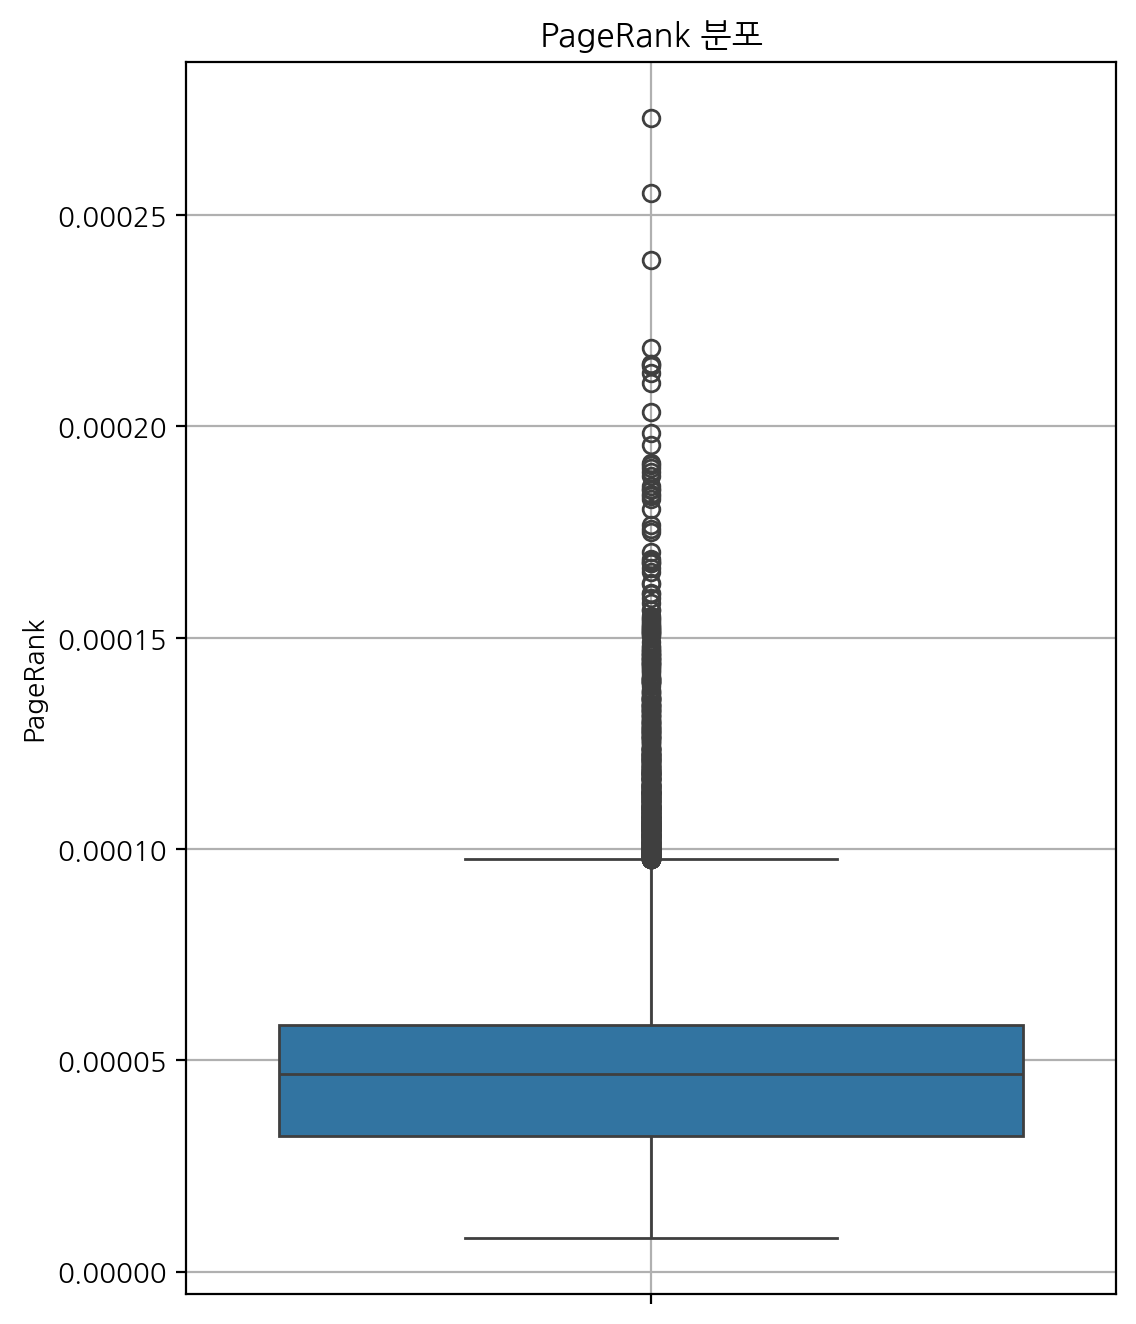

In [121]:
plt.figure(figsize=(6, 8))
sns.boxplot(centrality['pagerank'])
plt.title('PageRank 분포')
plt.ylabel('PageRank')
plt.grid(True)
plt.show()

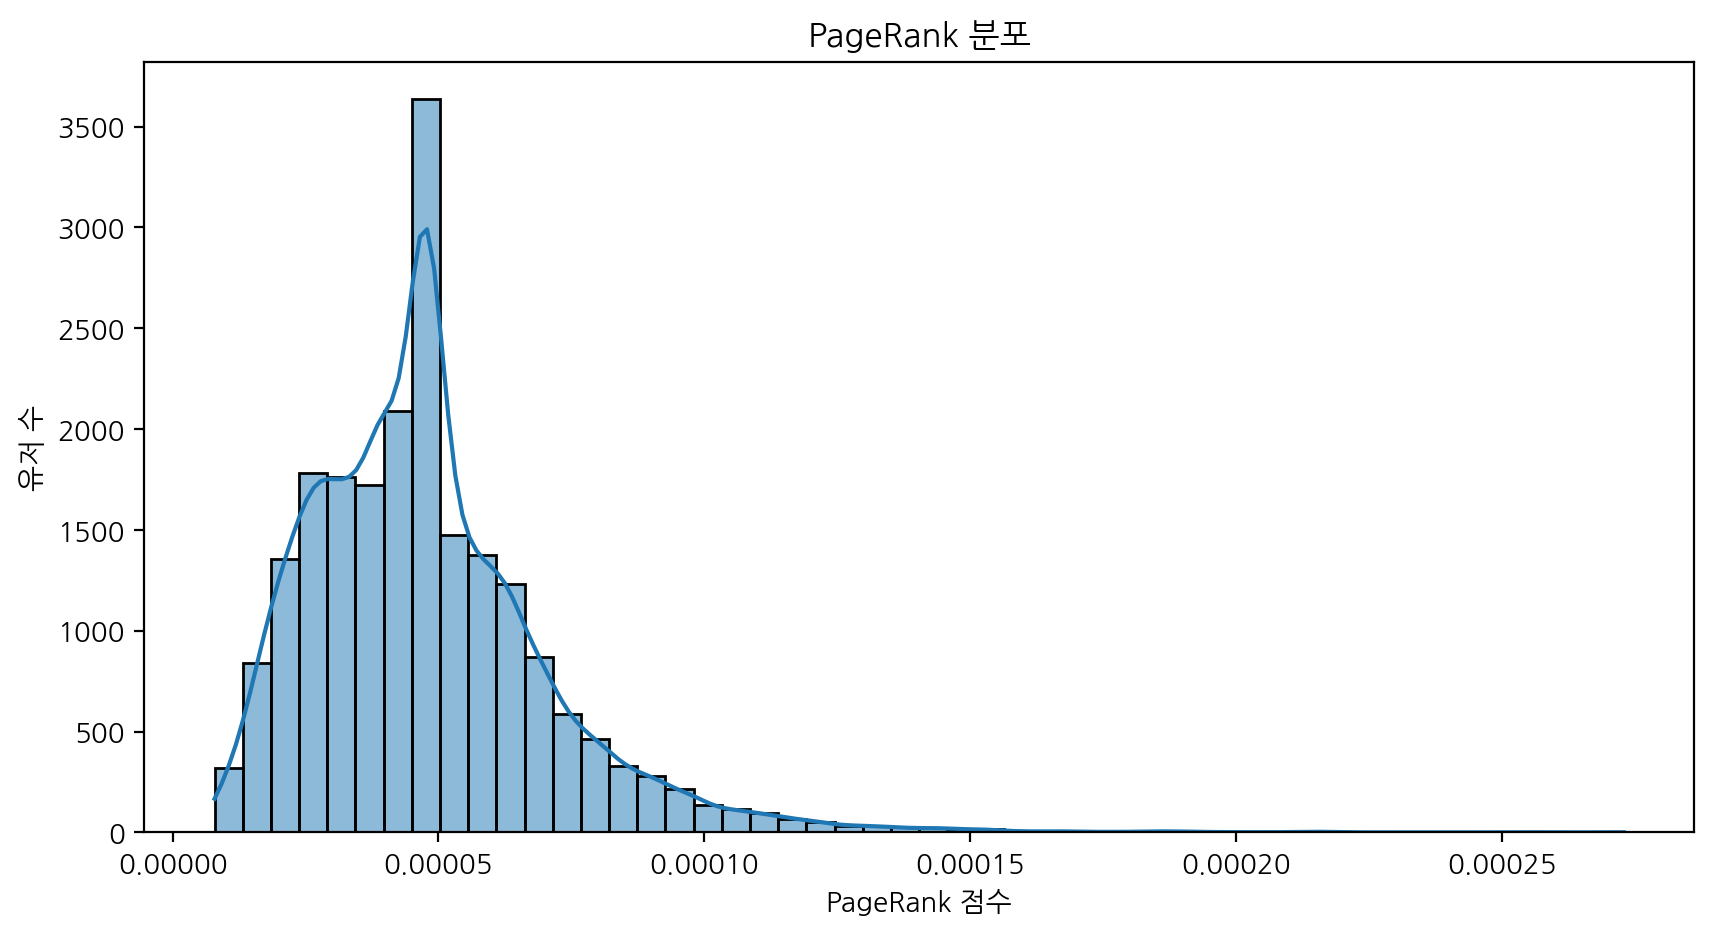

In [122]:
# pagerank 시각화
plt.figure(figsize=(10, 5))
sns.histplot(centrality['pagerank'], bins=50, kde=True)
plt.title('PageRank 분포')
plt.xlabel('PageRank 점수')
plt.ylabel('유저 수')
plt.show()

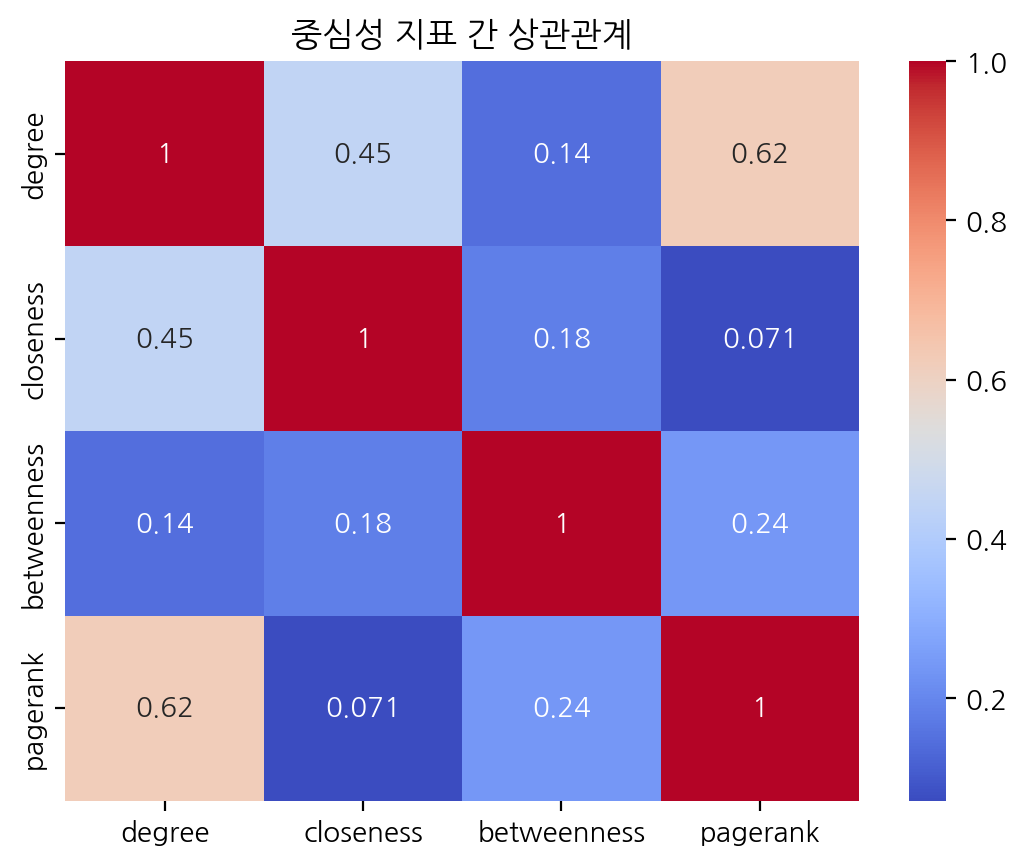

In [123]:
# 상관분석 (중복되는 지표 제거)
sns.heatmap(centrality[['degree', 'closeness', 'betweenness', 'pagerank']].corr(), annot=True, cmap='coolwarm')
plt.title('중심성 지표 간 상관관계')
plt.show()

- 친구 수(degree)가 많을수록 PageRank가 높아질 수는 있지만, 연결된 친구의 ‘질’에 따라 PageRank는 달라진다. 
- => 따라서 단순 친구 수만으로는 영향력을 설명하기 어렵고, PageRank는 그 자체로 차별화된 구조적 의미를 가진다

### 시각화
- pagerank 유저는 누구이고, 활성유저인가?

#### 투표, 답장, 초성열람 분포 시각화

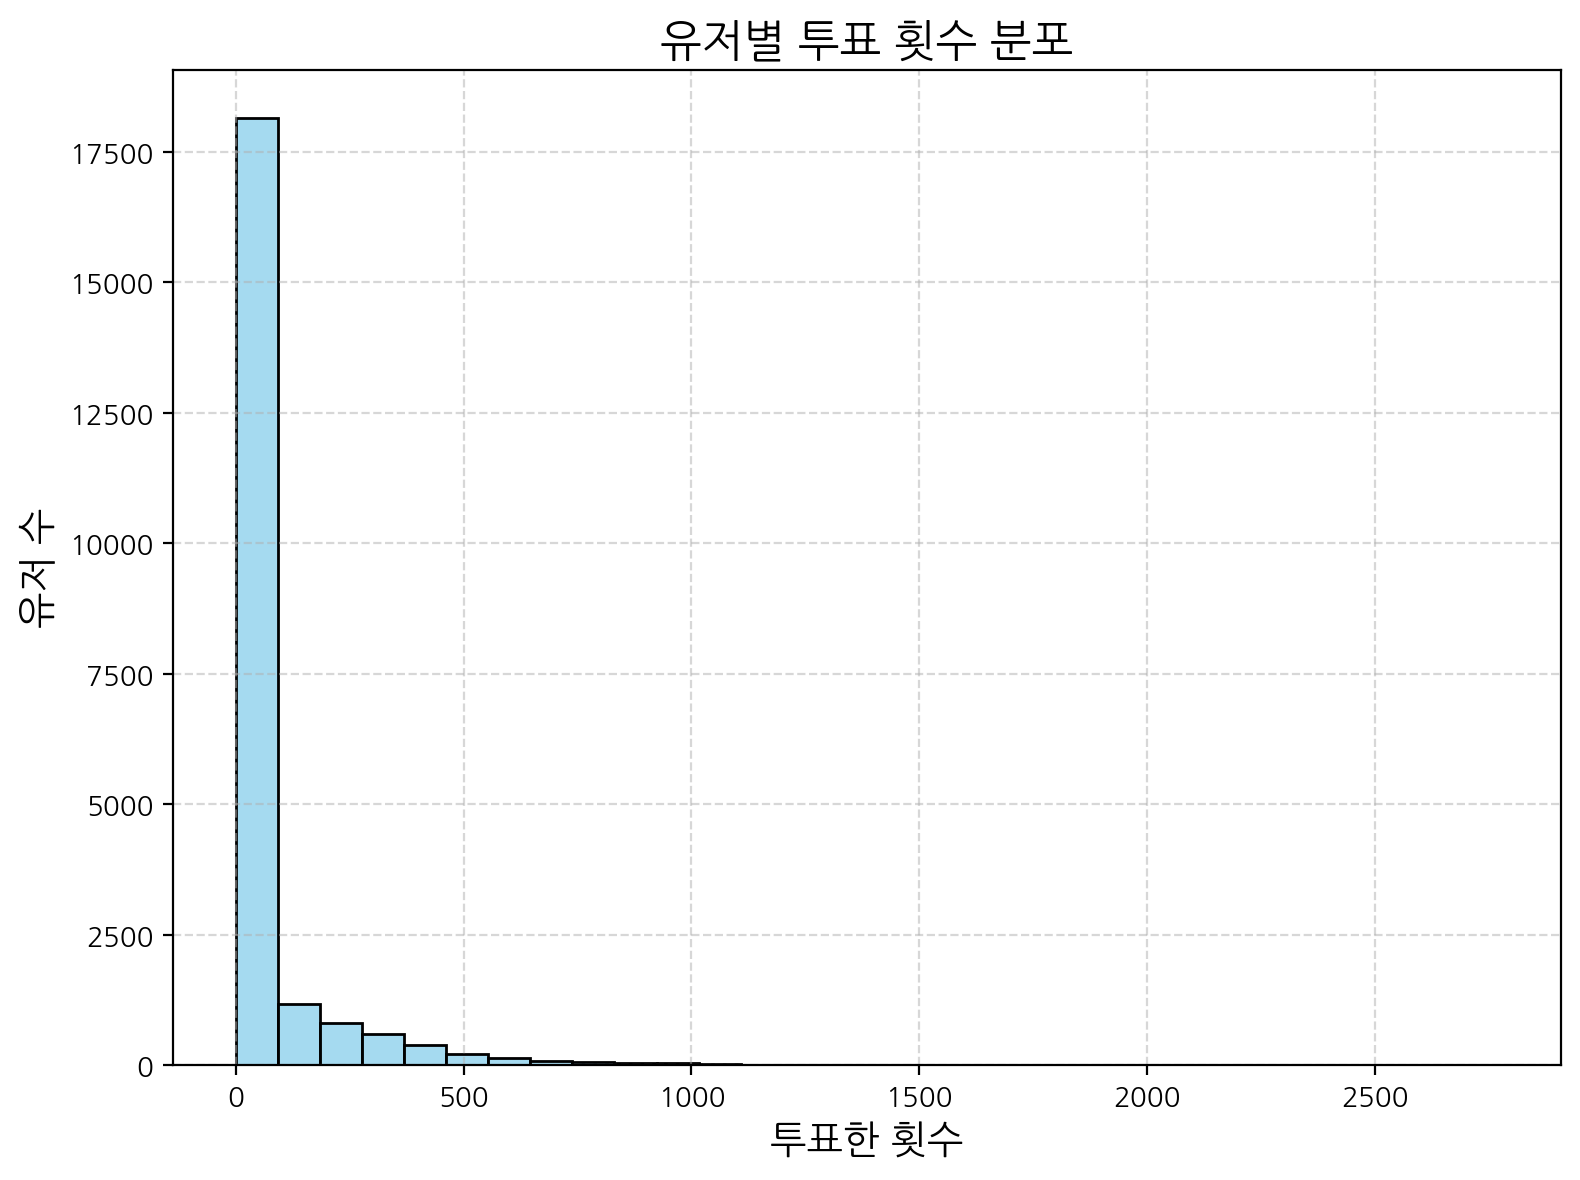

In [124]:
# 투표 분포수 확인
plt.figure(figsize=(8, 6))
sns.histplot(social_final, x='투표한수', bins=30, color='skyblue', edgecolor='black')

plt.title('유저별 투표 횟수 분포', fontsize=16)
plt.xlabel('투표한 횟수', fontsize=14)
plt.ylabel('유저 수', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

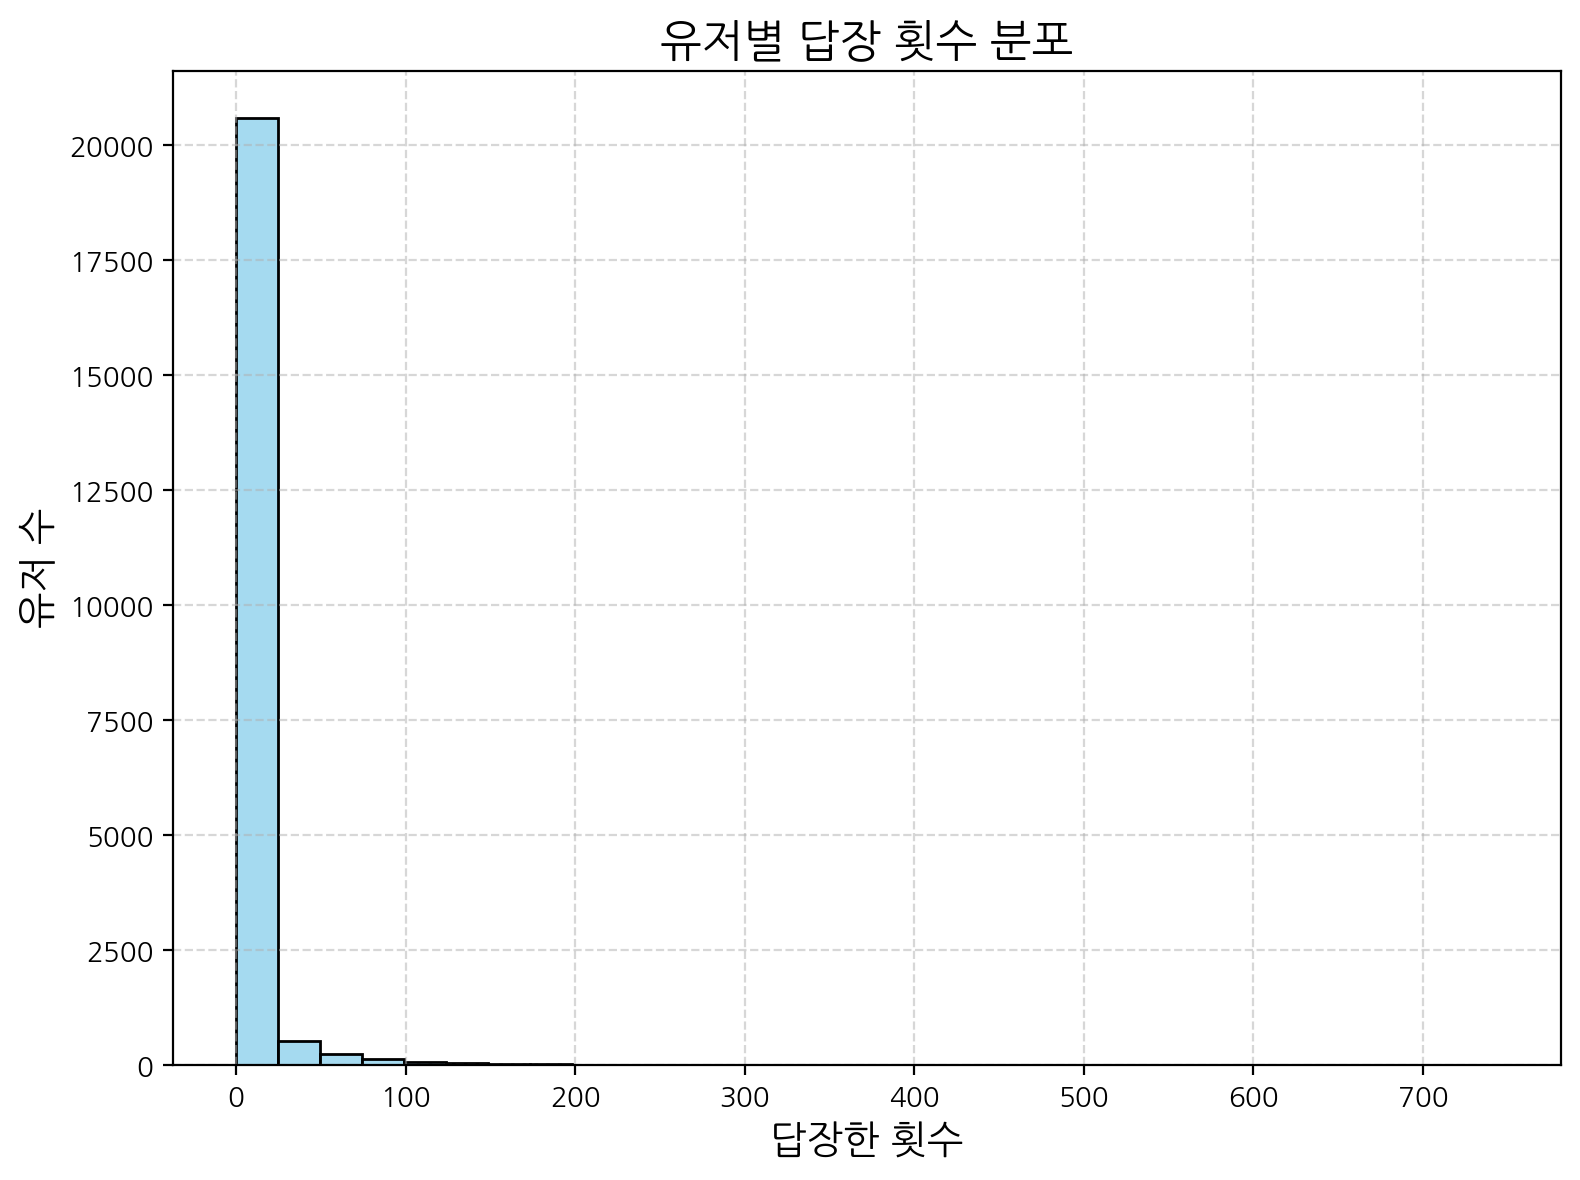

In [125]:
# 답장 분포수 확인
plt.figure(figsize=(8, 6))
sns.histplot(social_final, x='답장수', bins=30, color='skyblue', edgecolor='black')

plt.title('유저별 답장 횟수 분포', fontsize=16)
plt.xlabel('답장한 횟수', fontsize=14)
plt.ylabel('유저 수', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

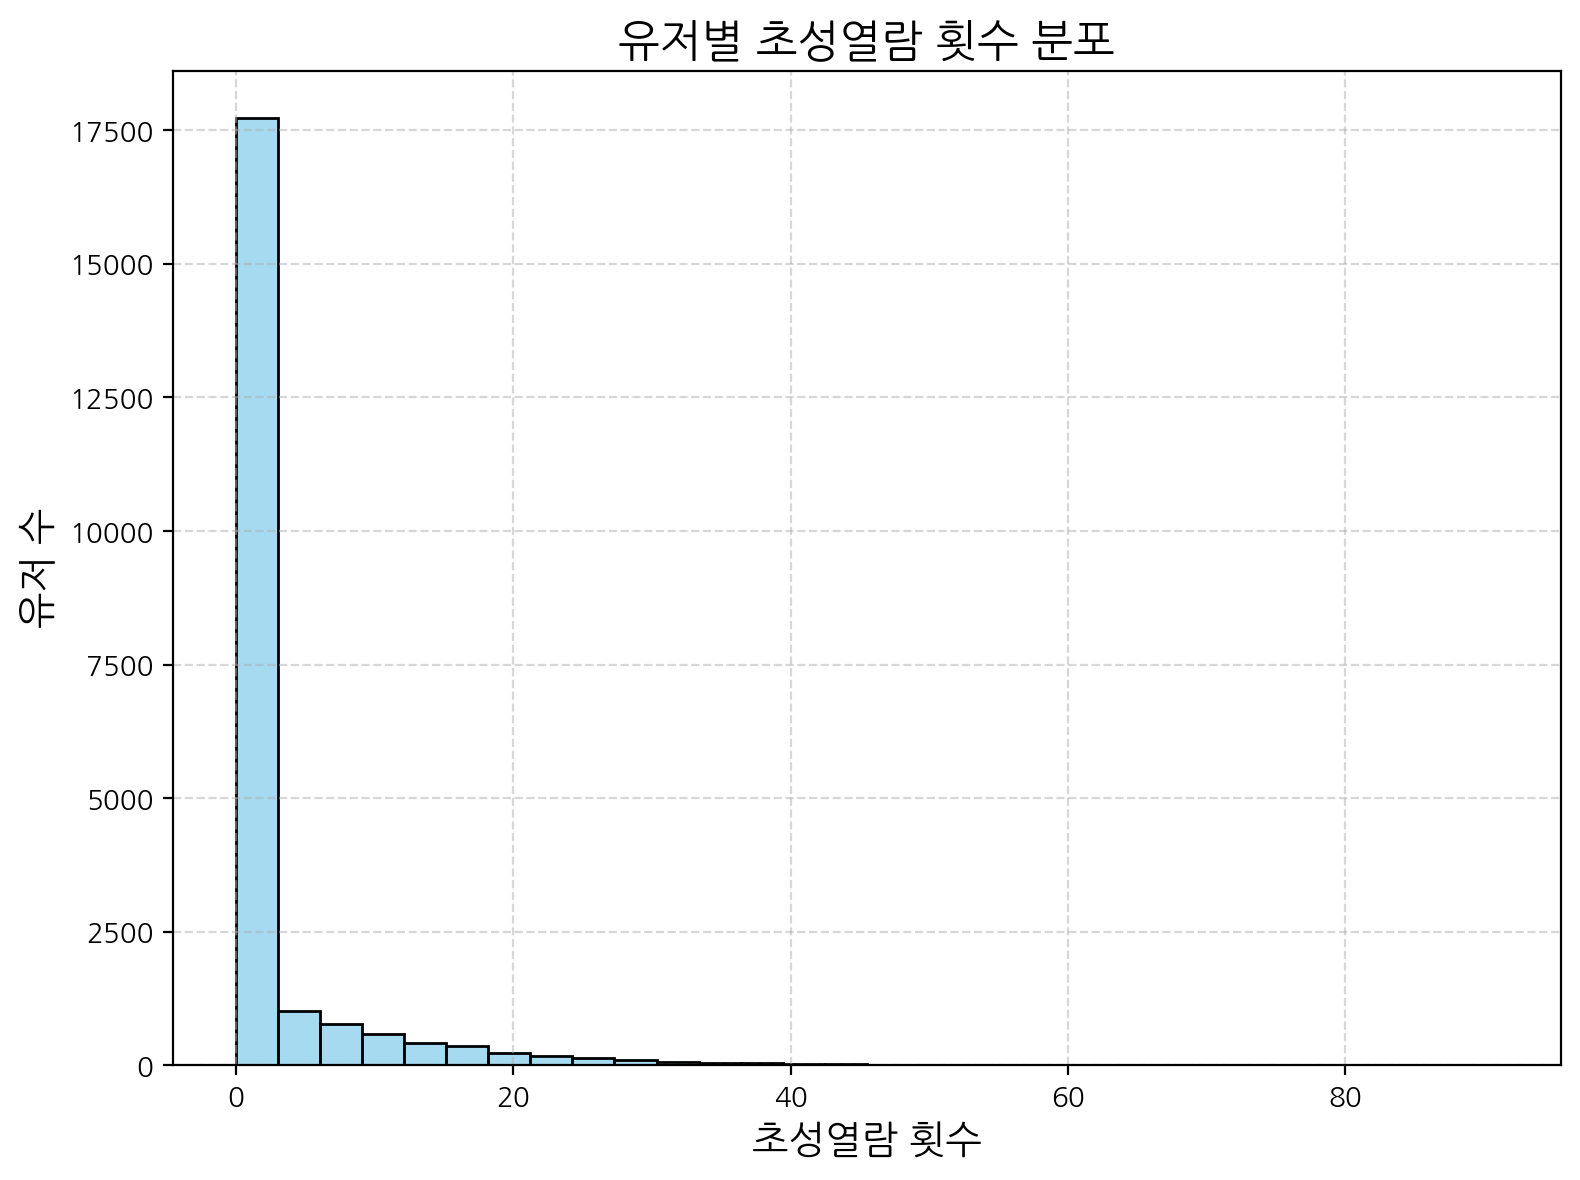

In [126]:
# 초성오픈수 분포수 확인
plt.figure(figsize=(8, 6))
sns.histplot(social_final, x='초성오픈수', bins=30, color='skyblue', edgecolor='black')

plt.title('유저별 초성열람 횟수 분포', fontsize=16)
plt.xlabel('초성열람 횟수', fontsize=14)
plt.ylabel('유저 수', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 투표, 답장, 초성열람 구간화(이상치 제거 필요할 수 있음)

In [127]:
# 4분위 보고 구간화 하기
print(social_final['투표한수'].describe())

count    21786.000000
mean        55.692142
std        149.660609
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2770.000000
Name: 투표한수, dtype: float64


In [128]:
# 4분위 기준으로 구간화
# 1. 초기값 '투표X'로 설정
social_final['투표활발도'] = '투표X'

# 2. 투표한 수가 1 이상인 유저만 따로 추출
nonzero = social_final[social_final['투표한수'] > 0]

# 3. qcut으로 분위 구간 나누기
social_final.loc[social_final['투표한수'] > 0, '투표활발도'] = pd.qcut(
    nonzero['투표한수'],
    q=4,
    labels=['낮음', '중간', '높음', '매우높음']
)

In [129]:
# 4분위 보고 구간화 하기
print(social_final['답장수'].describe())

count    21786.000000
mean         5.489764
std         24.259357
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        744.000000
Name: 답장수, dtype: float64


In [130]:
# 4분위 기준으로 구간화
# 1. 초기값 '답장X'로 설정
social_final['답장활발도'] = '답장1회'

# 2. 답장한 수가 1 이상인 유저만 따로 추출
nonzero = social_final[social_final['답장수'] > 1]

# 3. qcut으로 분위 구간 나누기
social_final.loc[social_final['답장수'] > 1, '답장활발도'] = pd.qcut(
    nonzero['답장수'],
    q=4,
    labels=['낮음', '중간', '높음', '매우높음']
)

In [131]:
# 4분위 보고 구간화 하기
print(social_final['초성오픈수'].describe())

count    21786.000000
mean         2.639126
std          6.577658
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         91.000000
Name: 초성오픈수, dtype: float64


In [132]:
# 초기화
social_final['콘텐츠소비도'] = '초성오픈X'

# 0회 이상인 유저만
nonzero = social_final[social_final['초성오픈수'] > 0]

# 분위 구간화
qcut_result = pd.qcut(nonzero['초성오픈수'], q=4, labels=['낮음', '중간', '높음', '매우높음'])

# 대입 (타입 맞추기)
social_final.loc[nonzero.index, '콘텐츠소비도'] = qcut_result.astype(str)

In [133]:
social_final["콘텐츠소비도"].value_counts()

콘텐츠소비도
초성오픈X    15811
낮음        1915
높음        1388
매우높음      1365
중간        1307
Name: count, dtype: int64

#### 참여중심유저, 콘텐츠소비유저 태깅

In [134]:
# 1. 조건 태깅 함수화
def tag_user_type(df):
    df['참여중심유저'] = (
        (df['투표활발도'].isin(['높음', '매우높음'])) &
        (df['답장활발도'].isin(['높음', '매우높음']))
    ).astype(int)

    df['콘텐츠소비유저'] = (
        df['콘텐츠소비도'].isin(['높음', '매우높음'])
    ).astype(int)

    return df

# 2. 세부 유저군 태깅
def assign_group(row):
    if row['참여중심유저'] == 1 and row['콘텐츠소비유저'] == 1:
        return '핵심유저'
    elif row['참여중심유저'] == 1:
        return '참여중심유저'
    elif row['콘텐츠소비유저'] == 1:
        return '콘텐츠소비유저'
    else:
        return '저관여유저'

# 3. 적용
social_final = tag_user_type(social_final)
social_final['유저군'] = social_final.apply(assign_group, axis=1)

In [135]:
social_final['유저군'].value_counts()

유저군
저관여유저      18804
콘텐츠소비유저     1696
핵심유저        1057
참여중심유저       229
Name: count, dtype: int64

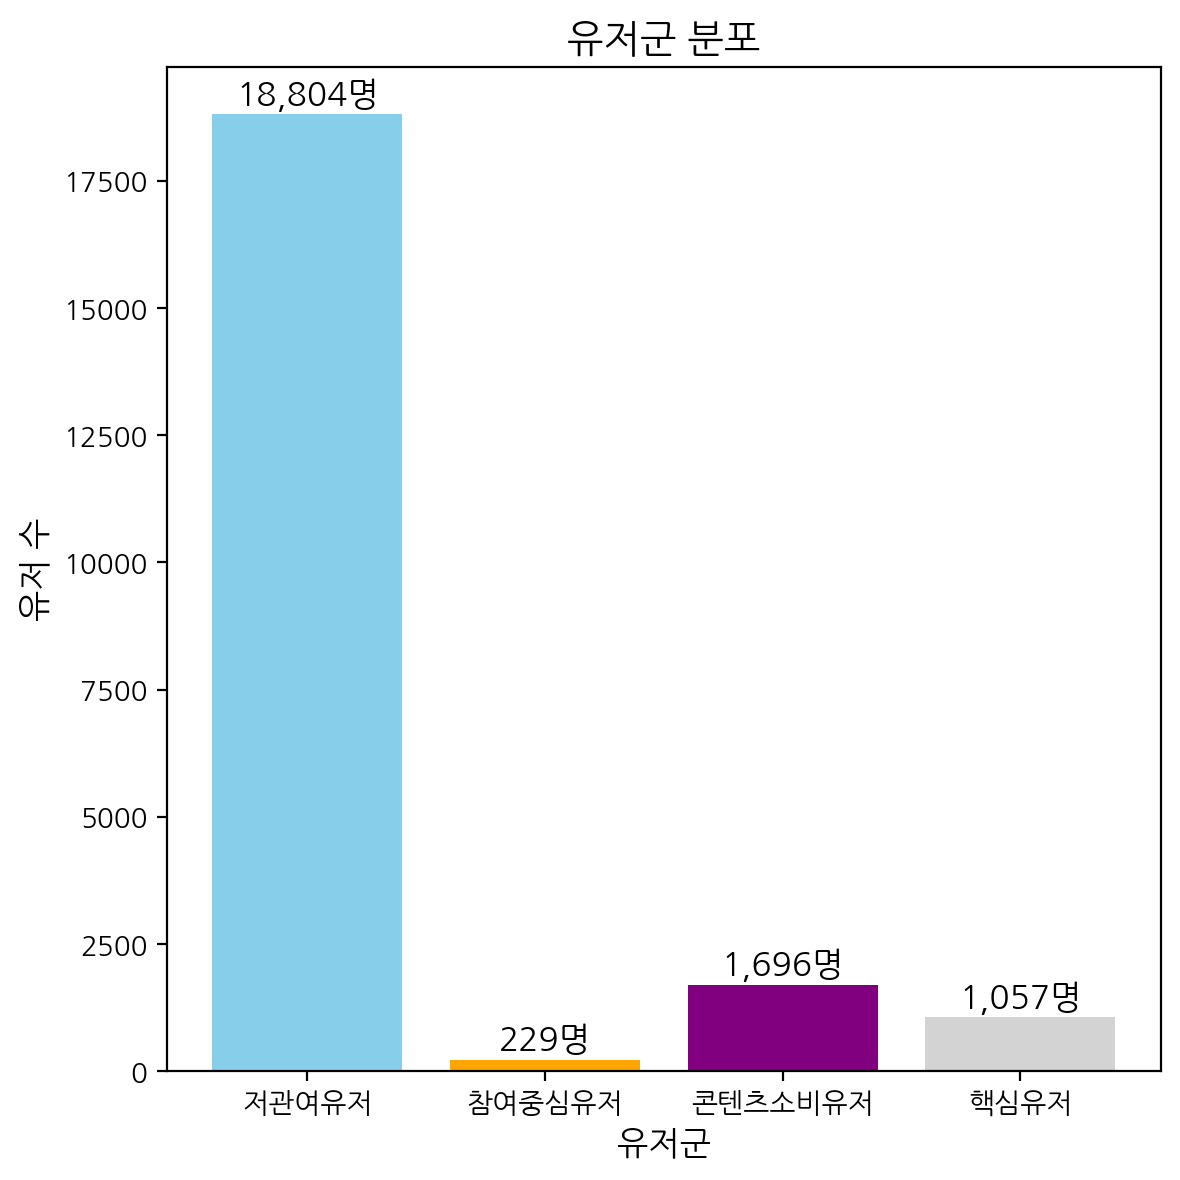

In [136]:
#유저군 분포 시각화

# 유저군 분포 집계
group_counts = social_final['유저군'].value_counts().sort_index()  # 정렬은 optional
labels = group_counts.index
values = group_counts.values

# 시각화
plt.figure(figsize=(6, 6))
bars = plt.bar(labels, values, color=['skyblue', 'orange', 'purple', 'lightgray'])

# 막대 위에 글씨 추가
for i, value in enumerate(values):
    plt.text(i, value + max(values) * 0.003, f"{value:,}명", ha='center', va='bottom', fontsize=12)

plt.title('유저군 분포', fontsize=14)
plt.xlabel('유저군', fontsize=12)
plt.ylabel('유저 수', fontsize=12)
plt.tight_layout()
plt.show()

#### pagerank 상위 유저만 시각화

#### 분포 통계검정

In [137]:
# PageRank 기준 내림차순
pr = centrality.sort_values(by='pagerank', ascending=False).copy()

# social_final과 병합해서 유저세분화 컬럼 붙이기
merge_social = pd.merge(pr, social_final[['user_id', '유저군']], on='user_id', how='left')

In [138]:
# 유저군별 PageRank 평균 비교
merge_social.groupby('유저군')['pagerank'].mean().sort_values(ascending=False).reset_index()

,유저군,pagerank
0,핵심유저,0.000071
1,참여중심유저,0.000062
2,콘텐츠소비유저,0.000062
3,저관여유저,0.000045


In [139]:
only_participation = social_final[social_final['유저군'] == '참여중심유저']
only_consumption = social_final[social_final['유저군'] == '콘텐츠소비유저']

# 중앙성 병합
p1 = pd.merge(only_participation, centrality[['user_id', 'pagerank']], on='user_id')['pagerank']
p2 = pd.merge(only_consumption, centrality[['user_id', 'pagerank']], on='user_id')['pagerank']

In [140]:
# 등분산 검정

levene_stat, levene_p = levene(p1, p2)
print(f"🔎 Levene 등분산 검정 p-value: {levene_p:.4f}")

# p > 0.05 → 등분산 가정 가능 (→ 일반 t-test)
# p < 0.05 → 등분산 가정 어려움 (→ Welch t-test)

🔎 Levene 등분산 검정 p-value: 0.4244


In [141]:
equal_var = True if levene_p > 0.05 else False
t_stat, t_p = ttest_ind(p1, p2, equal_var=equal_var)
print(f"📊 독립표본 t-test p-value: {t_p:.4f}")

# p < 0.05 → 평균 차이 있음
# p > 0.05 → 평균 차이 없음

📊 독립표본 t-test p-value: 0.7522


In [142]:
ks_stat, ks_p = ks_2samp(p1, p2)
print(f"📈 KS 검정 (분포 전체 비교) p-value: {ks_p:.4f}")

# p < 0.05 → 분포 형태 자체에 유의미한 차이 있음

📈 KS 검정 (분포 전체 비교) p-value: 0.7011


#### 유저군별 시각화

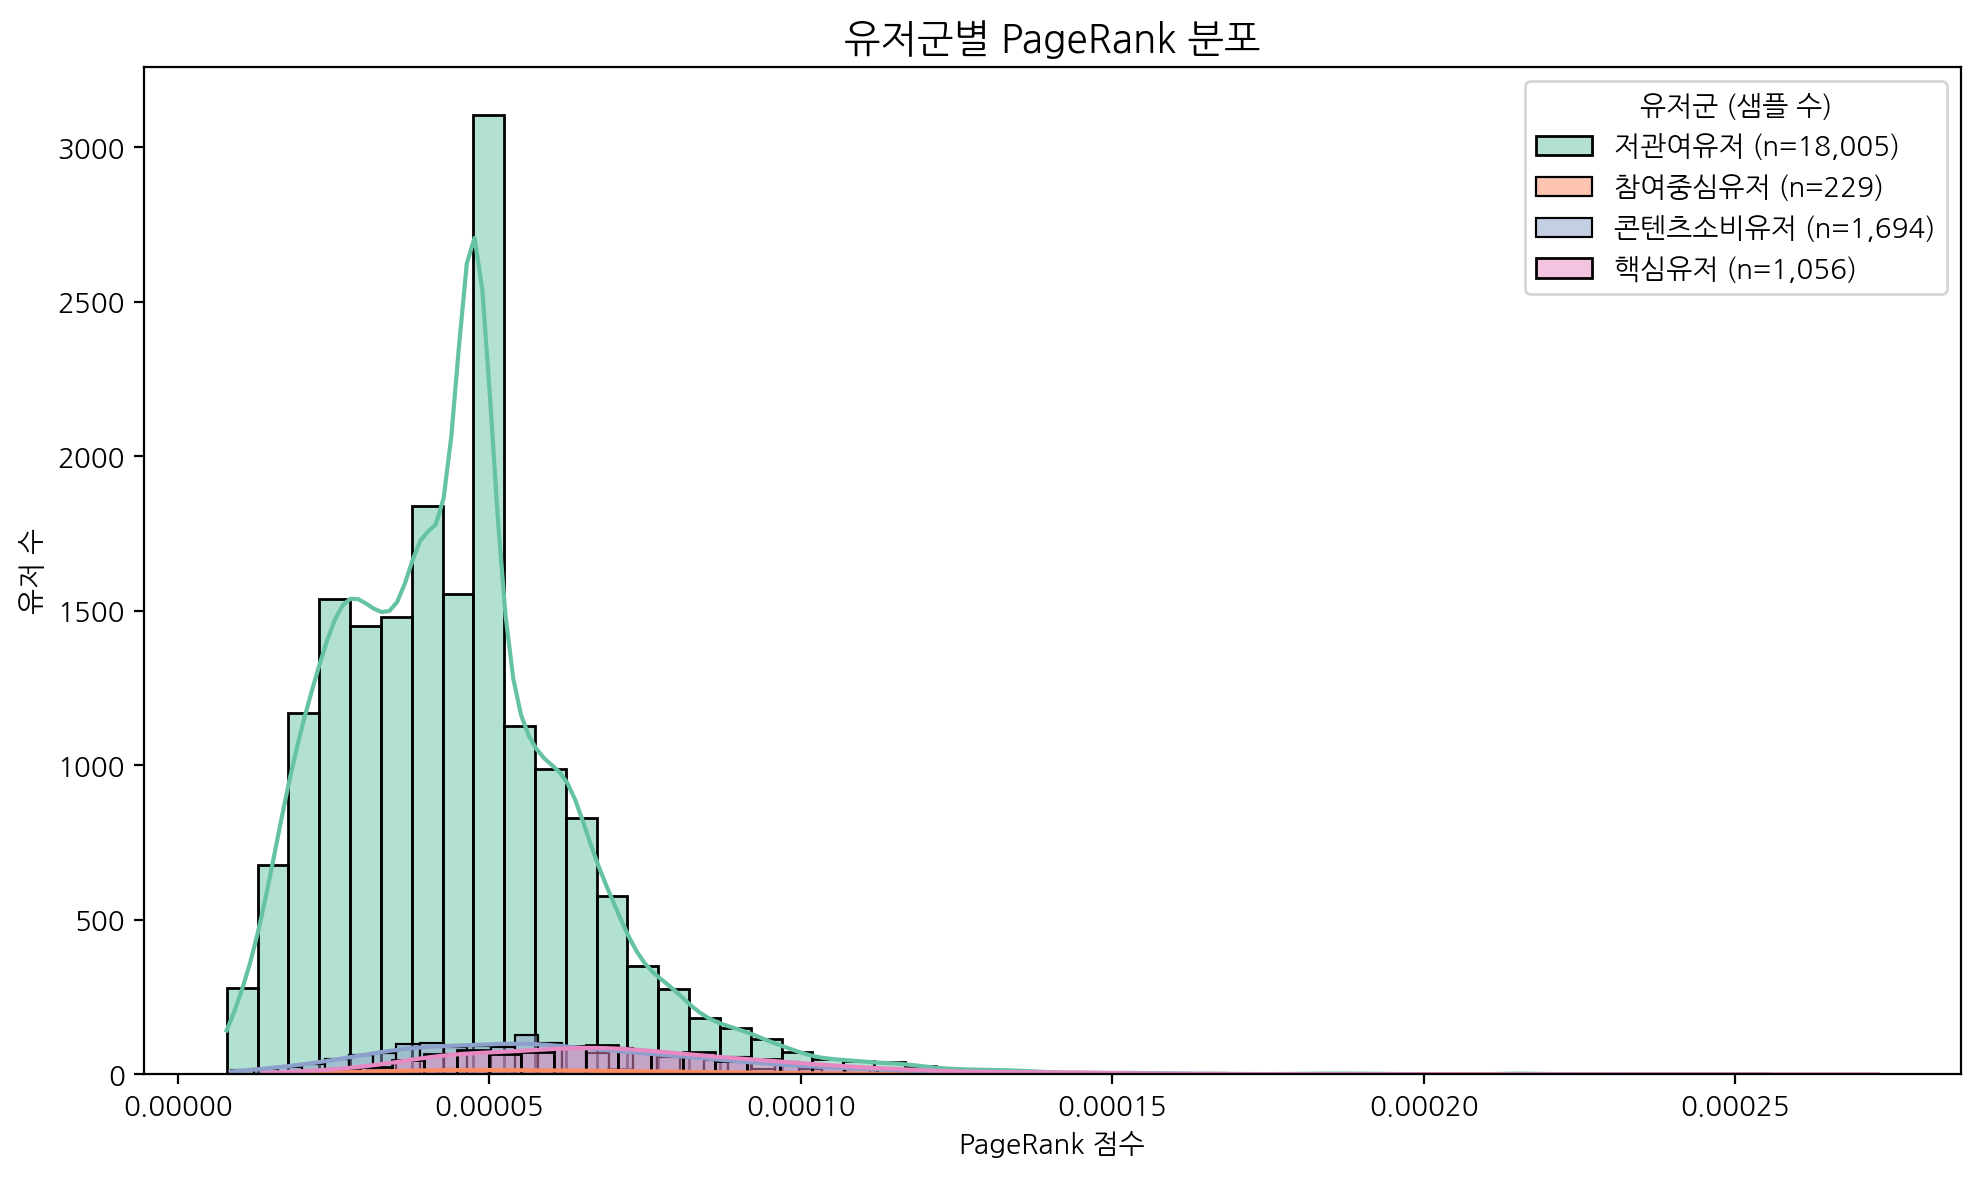

In [143]:
# 🚨 새로운 시각화 / 유저군별 PageRank 분포 히스토그램 (한 화면에 겹치게)

# 유저군별 샘플 수 계산
group_counts = merge_social['유저군'].value_counts().to_dict()

# 범례 표기용 컬럼 생성
merge_social['유저군_표기'] = merge_social['유저군'].map(lambda x: f"{x} (n={group_counts.get(x, 0):,})")

# 시각화 시작
plt.figure(figsize=(10, 6))

# 유저군별로 loop 돌면서 직접 plot (범례 제대로 나오게 하기 위해)
palette = sns.color_palette('Set2', len(merge_social['유저군_표기'].unique()))
for i, (group, df_) in enumerate(merge_social.groupby('유저군_표기')):
    sns.histplot(
        data=df_,
        x='pagerank',
        bins=50,
        kde=True,
        label=group,
        color=palette[i],
        alpha=0.5
    )

plt.title('유저군별 PageRank 분포', fontsize=14)
plt.xlabel('PageRank 점수')
plt.ylabel('유저 수')
plt.legend(title='유저군 (샘플 수)')
plt.tight_layout()
plt.show()

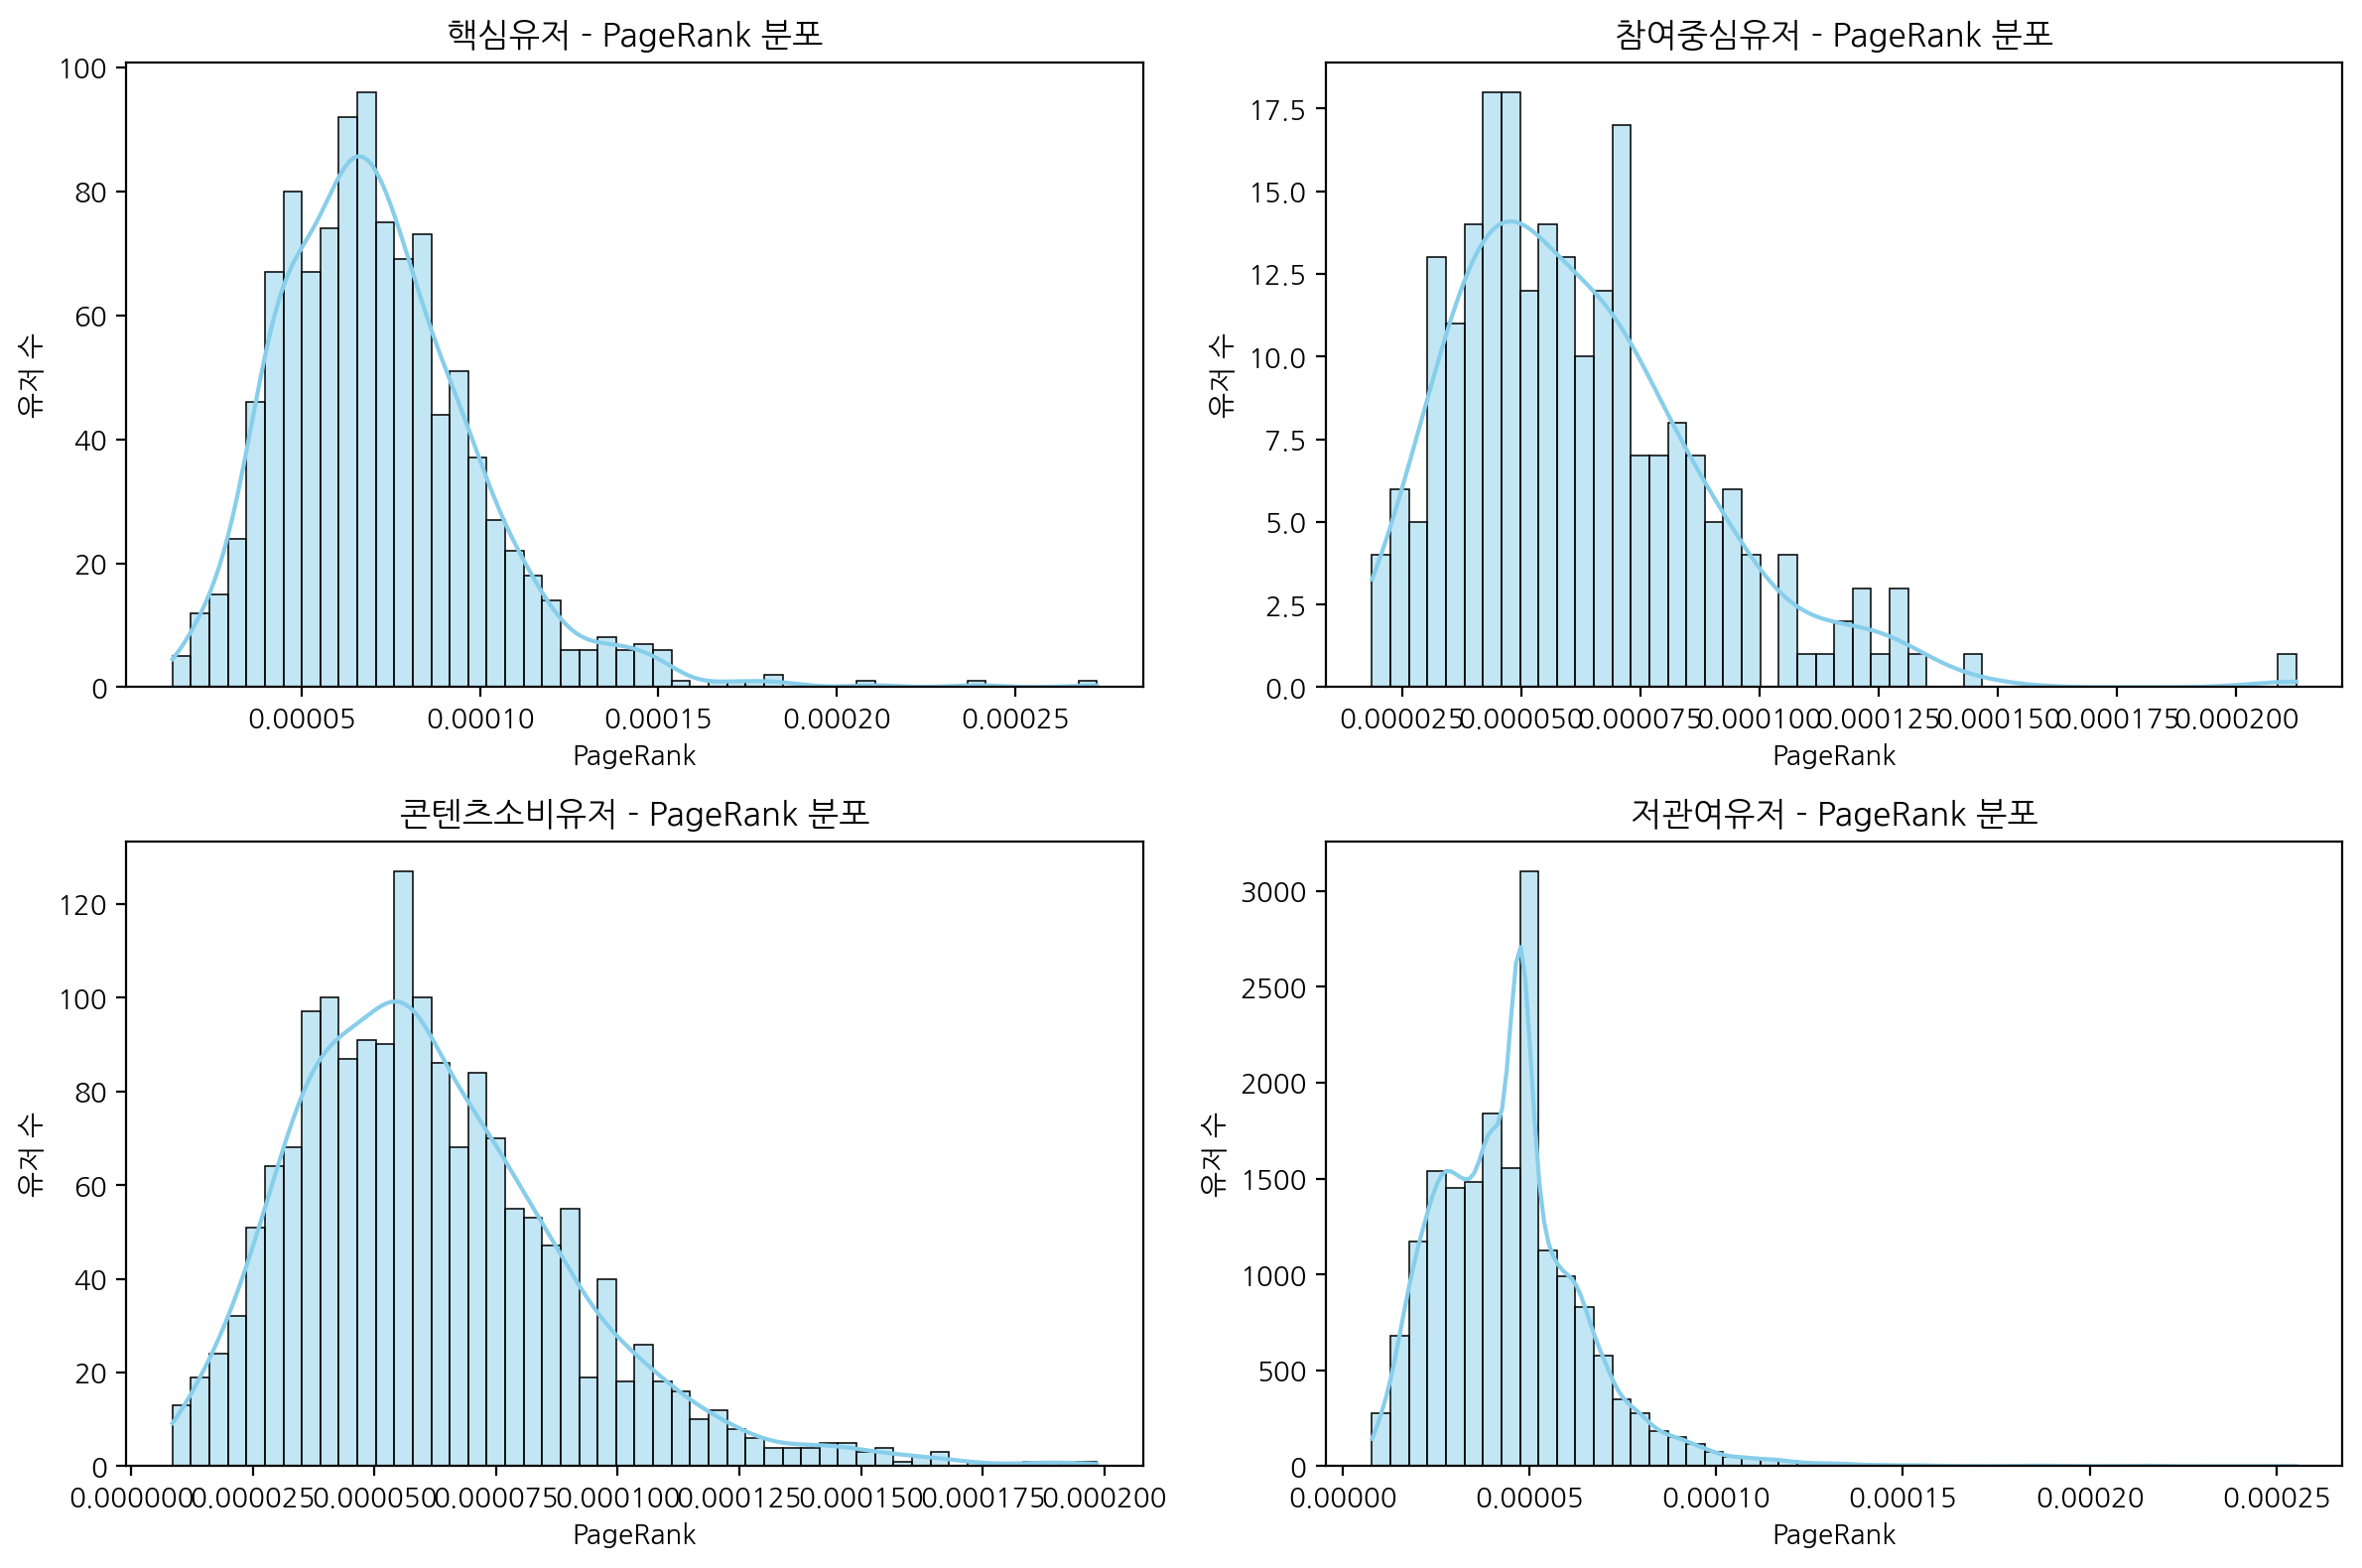

In [144]:
# :rotating_light: 새로운 시각화 / 2x2 서브플롯: 유저군별 PageRank 분포 개별 시각화

# 유저군 리스트 (정렬 순서는 자유)
user_groups = ['핵심유저', '참여중심유저', '콘텐츠소비유저', '저관여유저']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, group in enumerate(user_groups):
    subset = merge_social[merge_social['유저군'] == group]
    sns.histplot(subset['pagerank'], bins=50, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'{group} - PageRank 분포')
    axes[i].set_xlabel('PageRank')
    axes[i].set_ylabel('유저 수')

plt.tight_layout()
plt.show()

In [145]:
# 🚨 PageRank 점수가 0.00062 이상인 유저만 추출
high_pr_users = merge_social[merge_social['pagerank'] >= 0.000062]['user_id'].tolist()

G_high = G.subgraph(high_pr_users)

In [146]:
len(high_pr_users)

4295

In [147]:
# 3. 레이아웃 정의
pos = nx.spring_layout(G_high, seed=3)

# 4. 유저군별 색상 정의
user_group_colors = {
    '핵심유저': 'lightgrey',
    '참여중심유저': 'orange',
    '콘텐츠소비유저': 'purple',
    '저관여유저': 'skyblue'
}

# 5. merge에서 유저 정보 필터링
high_df = merge_social[merge_social['user_id'].isin(G_high.nodes())].set_index('user_id')

# 6. 노드 색상: 유저군 기준
node_colors = [
    user_group_colors.get(high_df.loc[node, '유저군'], 'grey')
    for node in G_high.nodes()
]

# 7. 노드 크기: PageRank 기준
node_sizes = [
    high_df.loc[node, 'pagerank'] * 100000
    for node in G_high.nodes()
]

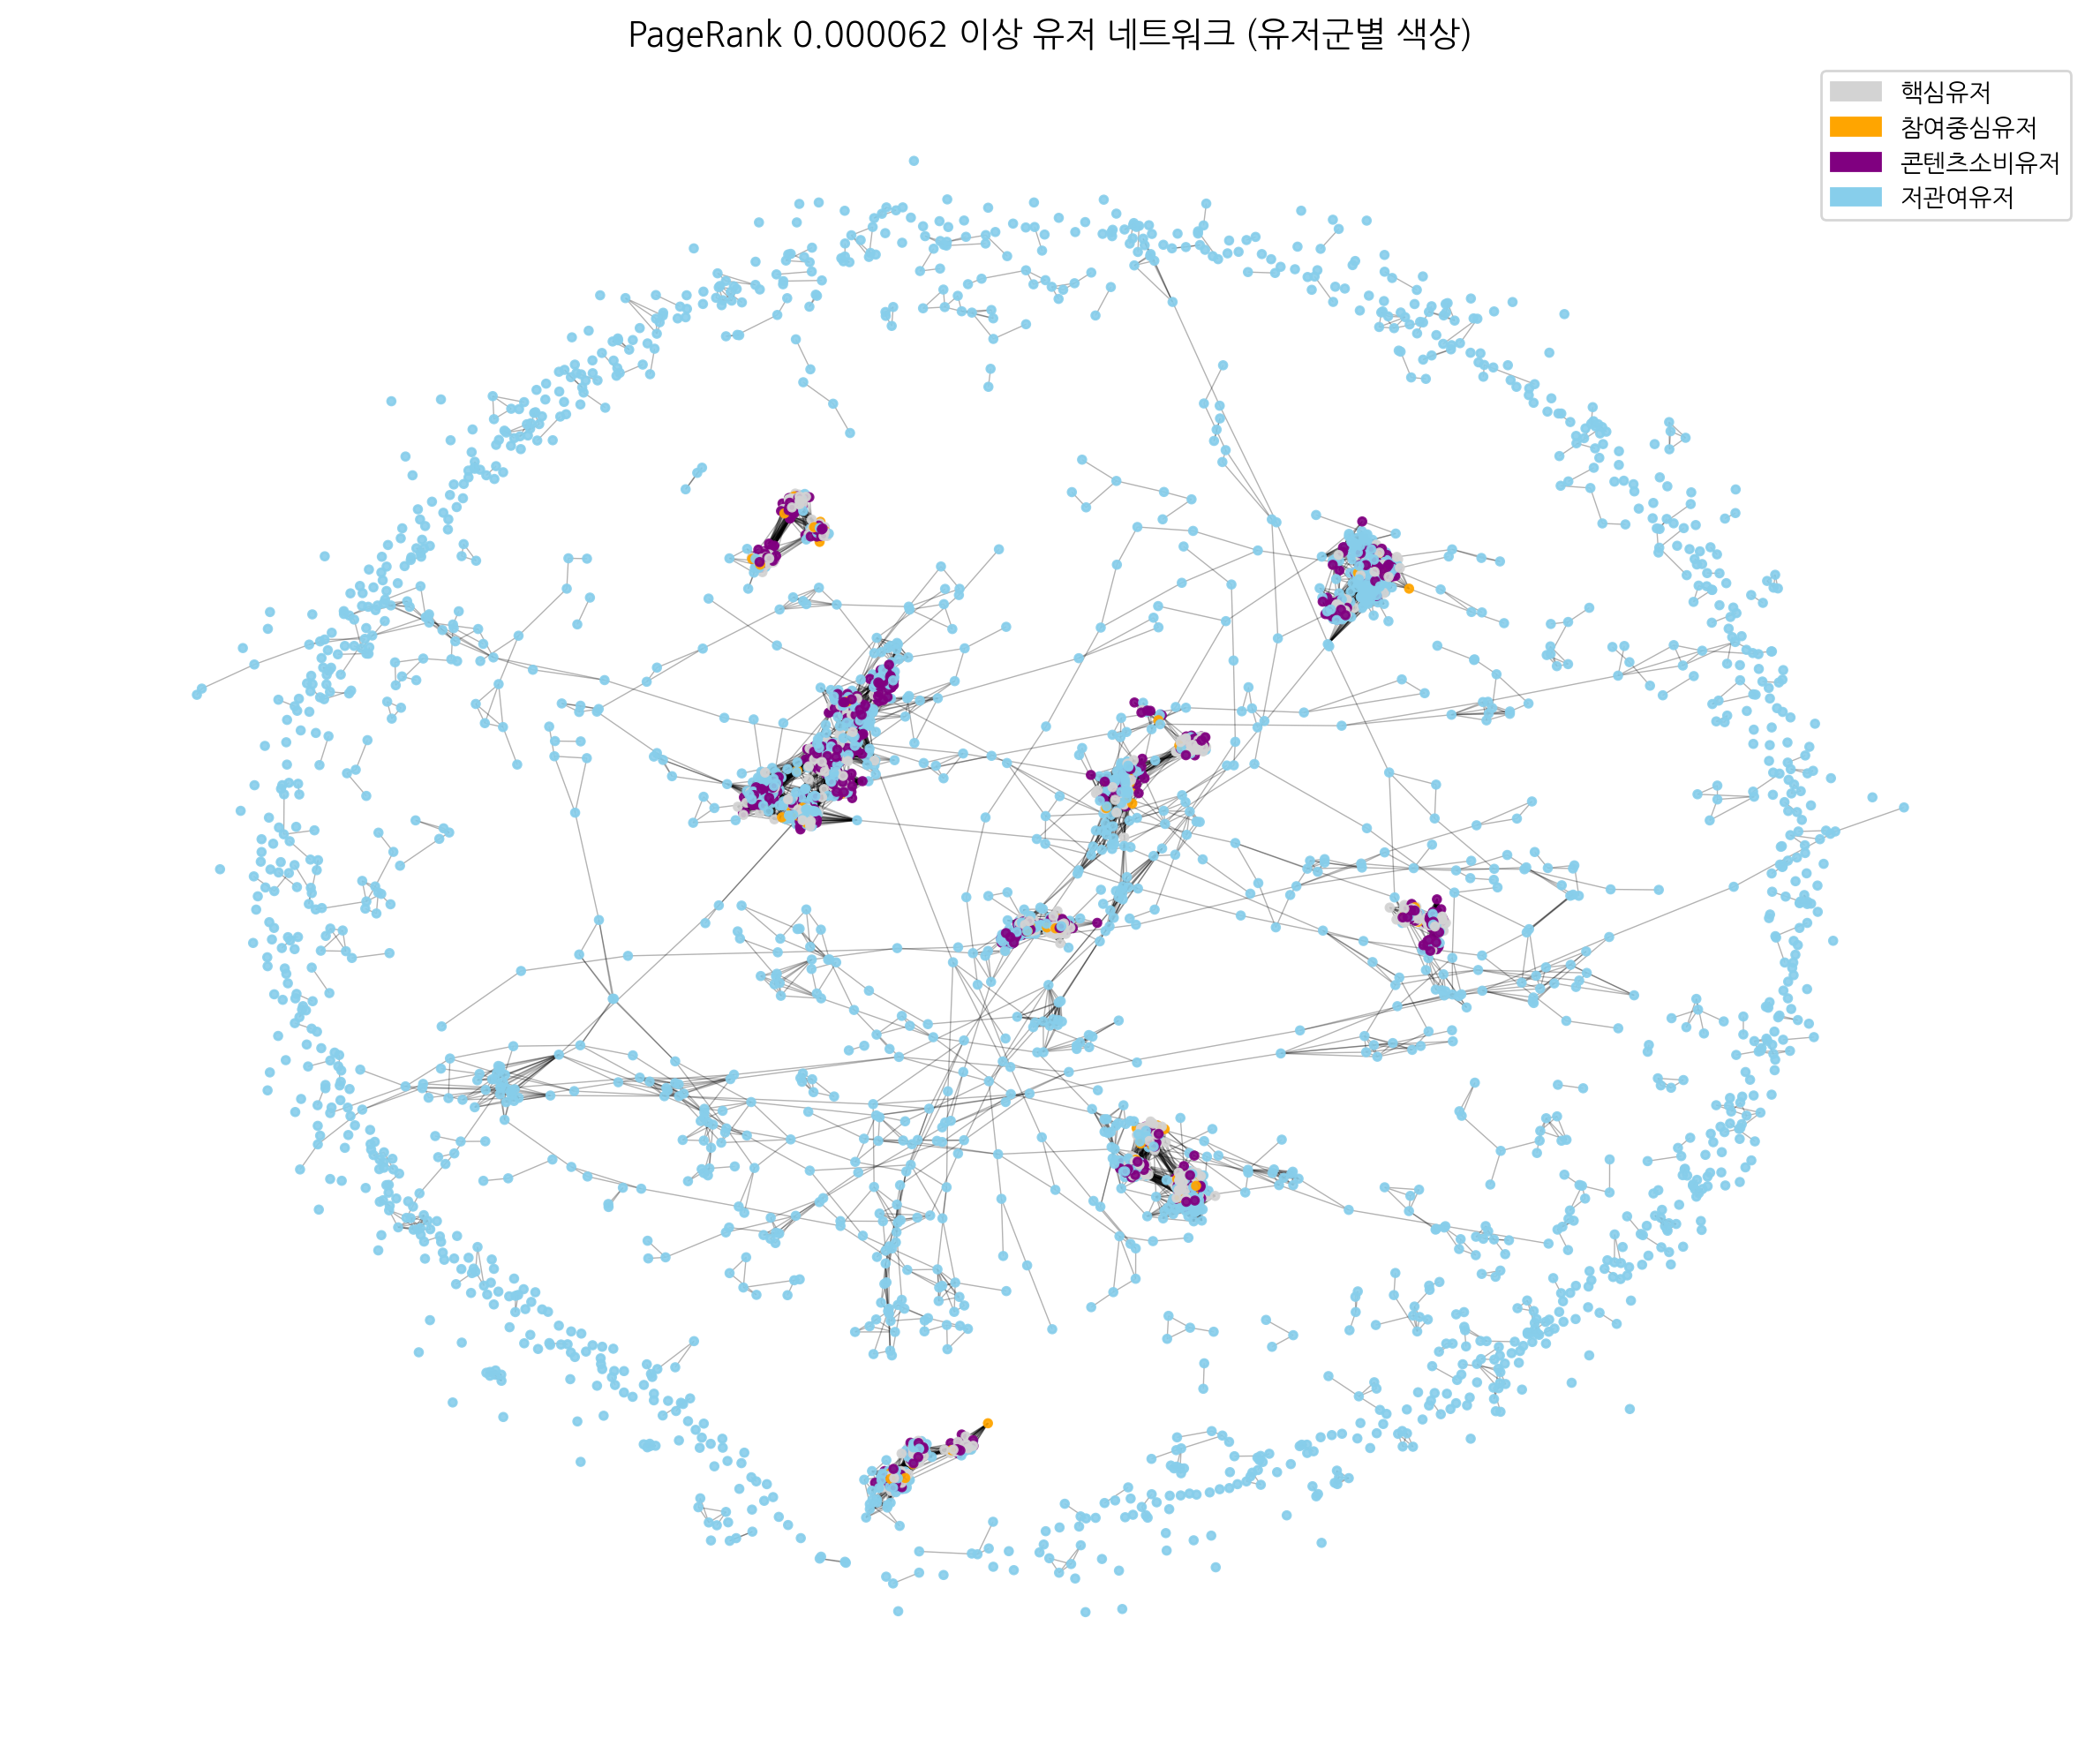

In [148]:
# 8. 시각화

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G_high, pos, node_size=10, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G_high, pos, width=0.5, alpha=0.3)

plt.title('PageRank 0.000062 이상 유저 네트워크 (유저군별 색상)', fontsize=14)

# 범례 생성
legend_handles = [mpatches.Patch(color=color, label=label) for label, color in user_group_colors.items()]
plt.legend(handles=legend_handles, loc='upper right', fontsize=10)

plt.axis('off')
plt.tight_layout()
plt.show()

In [149]:
# pos: 네트워크 레이아웃 위치 dict → numpy 배열로 변환
pos_array = np.array([pos[n] for n in G_high.nodes])
node_list = list(G_high.nodes)

# 위치값 스케일링
scaler = StandardScaler()
pos_scaled = scaler.fit_transform(pos_array)

In [150]:
for test_eps in [0.1, 0.15, 0.2, 0.25, 0.3]:
    db = DBSCAN(eps=test_eps, min_samples=5).fit(pos_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"[eps={test_eps}] → 클러스터 수: {n_clusters}, 노이즈 수: {n_noise}")

[eps=0.1] → 클러스터 수: 34, 노이즈 수: 211
[eps=0.15] → 클러스터 수: 5, 노이즈 수: 30
[eps=0.2] → 클러스터 수: 1, 노이즈 수: 5
[eps=0.25] → 클러스터 수: 1, 노이즈 수: 0
[eps=0.3] → 클러스터 수: 1, 노이즈 수: 0


In [151]:
for test_eps in [0.1, 0.11, 0.12, 0.13, 0.14, 0.15]:
    db = DBSCAN(eps=test_eps, min_samples=5).fit(pos_scaled)
    labels = db.labels_
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    print(f"[eps={test_eps}] → 클러스터 수: {n_clusters}, 노이즈 수: {n_noise}")

[eps=0.1] → 클러스터 수: 34, 노이즈 수: 211
[eps=0.11] → 클러스터 수: 25, 노이즈 수: 145
[eps=0.12] → 클러스터 수: 16, 노이즈 수: 109
[eps=0.13] → 클러스터 수: 13, 노이즈 수: 70
[eps=0.14] → 클러스터 수: 9, 노이즈 수: 42
[eps=0.15] → 클러스터 수: 5, 노이즈 수: 30


In [152]:
merge_social

,user_id,degree,closeness,betweenness,pagerank,유저군,유저군_표기
0,860304,170,0.105616,0.007232,0.000273,핵심유저,"핵심유저 (n=1,056)"
1,1137034,201,0.079396,0.002842,0.000255,저관여유저,"저관여유저 (n=18,005)"
2,915445,226,0.076508,0.002175,0.000239,핵심유저,"핵심유저 (n=1,056)"
3,887864,133,0.104535,0.004375,0.000219,저관여유저,"저관여유저 (n=18,005)"
4,915060,202,0.077308,0.003962,0.000215,저관여유저,"저관여유저 (n=18,005)"
...,...,...,...,...,...,...,...
20979,1381958,1,0.068855,0.000000,0.000008,저관여유저,"저관여유저 (n=18,005)"
20980,1278431,1,0.072137,0.000000,0.000008,저관여유저,"저관여유저 (n=18,005)"
20981,1301915,1,0.072137,0.000000,0.000008,저관여유저,"저관여유저 (n=18,005)"
20982,1214232,1,0.060506,0.000000,0.000008,저관여유저,"저관여유저 (n=18,005)"


In [153]:
#merge_social.drop(columns=["dbscan_community"], inplace=True)

# DBSCAN 재적용 (확정 파라미터)
db = DBSCAN(eps=0.135, min_samples=5).fit(pos_scaled)
db_labels = db.labels_  # -1은 노이즈(외곽 유저)

# 커뮤니티 ID dict 생성
node_list = list(G_high.nodes)
custom_partition = dict(zip(node_list, db_labels))

# 데이터프레임으로 정리
dbscan_df = pd.DataFrame({
    'user_id': node_list,
    'dbscan_community': db_labels
})

# merge에 붙이기
merge_dbscan = merge_social.merge(dbscan_df, on='user_id', how='left')

print(merge_dbscan['dbscan_community'].value_counts().sort_index())

dbscan_community
-1.0       59
 0.0     1025
 1.0      237
 2.0      376
 3.0      715
 4.0     1628
 5.0      213
 6.0        8
 7.0        5
 8.0        5
 9.0       10
 10.0      14
Name: count, dtype: int64


In [154]:
# 1. 커뮤니티 ID 추출
unique_labels = sorted(merge_dbscan['dbscan_community'].dropna().unique())  # 예: [-1, 0, 1, ..., 8]
n_clusters = len([l for l in unique_labels if l != -1])  # 실제 커뮤니티 수

# 2. 색상 매핑 (tab10 → 시각적으로 구분 잘됨, 최대 10개)
cmap = cm.get_cmap('tab10', n_clusters + 1)
color_map = {}

for i, label in enumerate(unique_labels):
    if label == -1:
        color_map[label] = 'lightgrey'  # 노이즈(외곽) 따로 처리
    else:
        color_map[label] = cmap(i)

# 3. 노드 색상 지정
node_colors = [color_map[custom_partition[node]] for node in G_high.nodes]

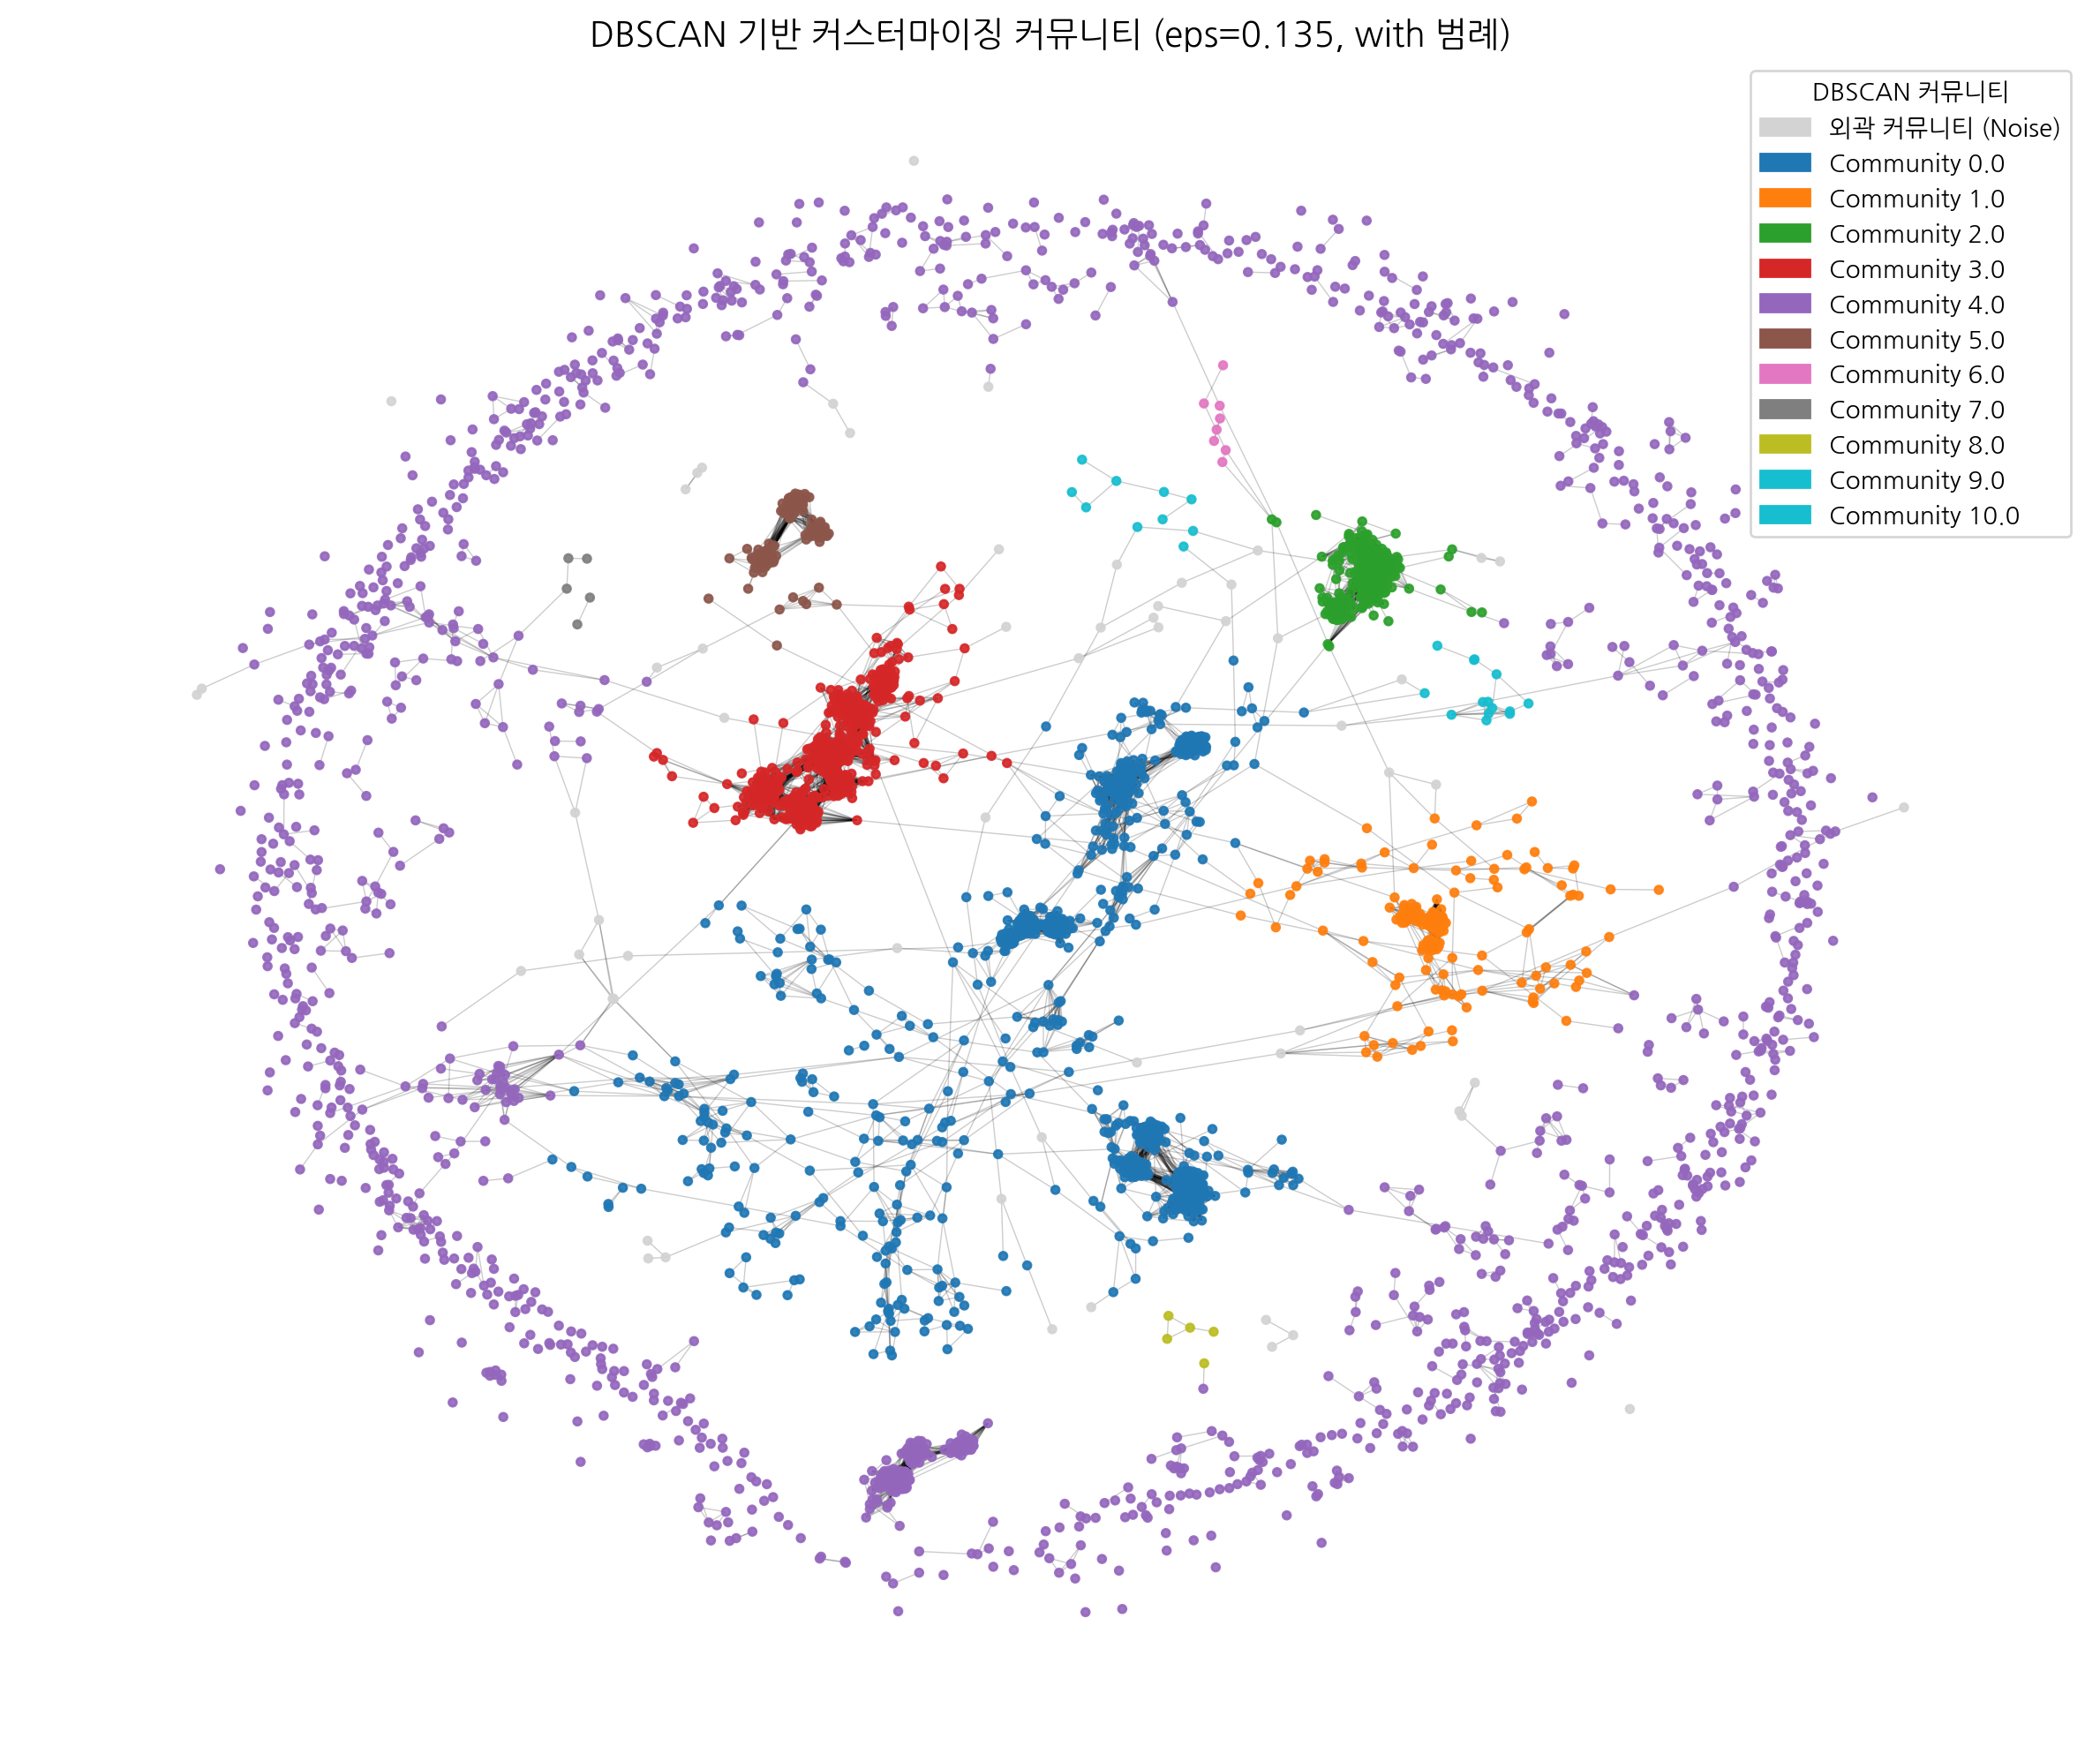

In [157]:
# 4. 시각화
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G_high, pos, node_size=10, node_color=node_colors, alpha=0.9)
nx.draw_networkx_edges(G_high, pos, alpha=0.2, width=0.5)

plt.title('DBSCAN 기반 커스터마이징 커뮤니티 (eps=0.135, with 범례)', fontsize=14)
plt.axis('off')

# 5. 범례 생성
legend_handles = []
for label in unique_labels:
    label_name = f"Community {label}" if label != -1 else "외곽 커뮤니티 (Noise)"
    legend_handles.append(
        mpatches.Patch(color=color_map[label], label=label_name)
    )

plt.legend(handles=legend_handles, title="DBSCAN 커뮤니티", fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

#### 커뮤니티 파일 저장

In [159]:
merge_dbscan

,user_id,degree,closeness,betweenness,pagerank,dbscan_community
0,860304,170,0.105616,0.007232,0.000273,3.0
1,1137034,201,0.079396,0.002842,0.000255,4.0
2,915445,226,0.076508,0.002175,0.000239,0.0
3,887864,133,0.104535,0.004375,0.000219,3.0
4,915060,202,0.077308,0.003962,0.000215,0.0
...,...,...,...,...,...,...
20979,1381958,1,0.068855,0.000000,0.000008,NaN
20980,1278431,1,0.072137,0.000000,0.000008,NaN
20981,1301915,1,0.072137,0.000000,0.000008,NaN
20982,1214232,1,0.060506,0.000000,0.000008,NaN


In [161]:
social_final

,user_id,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,친구요청받은수,친구요청거절수,친구요청수락수,친구요청펜딩수,...,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수,투표활발도,답장활발도,콘텐츠소비도,참여중심유저,콘텐츠소비유저,유저군
0,832340,2023-03-29,10,151,5,0.0,1.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
1,833294,2023-03-31,7,154,6,0.0,13.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,낮음,낮음,0,0,저관여유저
2,833203,2023-03-31,8,109,11,0.0,8.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,높음,초성오픈X,0,0,저관여유저
3,833525,2023-03-31,30,162,2,0.0,26.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,낮음,초성오픈X,0,0,저관여유저
4,833626,2023-03-31,11,133,6,0.0,7.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21781,1578711,2023-07-15,5,65,5,3.0,0.0,0.0,0.0,3.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
21782,1578894,2023-07-17,3,61,8,2.0,0.0,0.0,2.0,0.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
21783,1578871,2023-07-17,1,81,4,0.0,1.0,0.0,0.0,0.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
21784,1579064,2023-07-18,3,80,2,1.0,0.0,0.0,1.0,0.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저


In [158]:
merge_dbscan.drop(columns=["유저군", "유저군_표기"], inplace=True)

In [163]:
community = pd.merge(merge_dbscan, social_final, on="user_id", how="inner")
community.head()

,user_id,degree,closeness,betweenness,pagerank,dbscan_community,created_at_attendance,출석주기,마지막출석후경과일,출석일수,...,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수,투표활발도,답장활발도,콘텐츠소비도,참여중심유저,콘텐츠소비유저,유저군
0,860304,170,0.105616,0.007232,0.000273,3.0,2023-04-30,1,71,59,...,0.0,728.198529,495.0,343.0,매우높음,높음,매우높음,1,1,핵심유저
1,1137034,201,0.079396,0.002842,0.000255,4.0,2023-05-11,1,78,55,...,0.0,0.000000,6.0,6.0,낮음,답장1회,중간,0,0,저관여유저
2,915445,226,0.076508,0.002175,0.000239,0.0,2023-05-06,0,86,111,...,0.0,585.523333,391.0,325.0,매우높음,매우높음,매우높음,1,1,핵심유저
3,887864,133,0.104535,0.004375,0.000219,3.0,2023-05-05,2,76,32,...,0.0,0.000000,64.0,58.0,낮음,답장1회,낮음,0,0,저관여유저
4,915060,202,0.077308,0.003962,0.000215,0.0,2023-05-06,1,99,58,...,0.0,360.086111,76.0,68.0,낮음,매우높음,낮음,0,0,저관여유저


In [164]:
community.to_csv("community.csv", index=False)

#### 클러스터 파일 저장
- 클러스터링 활용 용도 

In [165]:
cluster = pd.merge(centrality, social_final, on="user_id", how="inner")
cluster.head()

,user_id,degree,closeness,betweenness,pagerank,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,...,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수,투표활발도,답장활발도,콘텐츠소비도,참여중심유저,콘텐츠소비유저,유저군
0,837534,3,0.082612,0.000010,0.000023,2023-04-19,6,161,3,3.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
1,833714,4,0.080508,0.000004,0.000033,2023-04-01,11,120,7,1.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
2,837587,5,0.075792,0.000493,0.000049,2023-04-19,5,133,8,1.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
3,837556,8,0.081048,0.000888,0.000074,2023-04-19,9,155,3,1.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
4,837615,8,0.080205,0.000650,0.000067,2023-04-19,10,153,3,2.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저


In [166]:
cluster.to_csv("cluster.csv", index=False)

#### 해석

In [ ]:
# 파랑색(0번), 주황색(1번), 초록색(2번)
# 빨강색(3번),보라색(4번), 갈색(5번)

In [292]:
numberlist = [number for number in range(0,6)]

extinct_community = community[community['dbscan_community'].isin(numberlist)].reset_index(drop=True)

In [308]:
extinct_community.shape

(4194, 35)

In [309]:
extinct_community.columns

Index(['user_id', 'degree', 'closeness', 'betweenness', 'pagerank', 'dbscan_community', 'created_at_attendance', '출석주기', '마지막출석후경과일', '출석일수', '친구요청수', '친구요청받은수', '친구요청거절수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후거절한수', '친구요청받은후수락한수', 'is_push_on', 'ban_status', 'gender', '초성오픈수', '답장수', '답장까지소요시간(분)', '열람수', '투표받은수', '질문차단수', '답장받기까지소요시간(분)', '투표한수', '참여한질문수', '투표활발도', '답장활발도', '콘텐츠소비도', '참여중심유저', '콘텐츠소비유저', '유저군'], dtype='object')

#### 커뮤니티별로 데이터프레임 다시 쪼개기

In [310]:
community_groups = {
    i: extinct_community[extinct_community['dbscan_community'] == i].reset_index(drop=True)
    for i in range(6)  # 0부터 5까지
}

In [311]:
for i in range(6):
    globals()[f'comm{i}'] = community_groups[i]

#### 커뮤니티별로 유저군 비율 보기

In [312]:
group_summary = []

for i, df in community_groups.items():
    counts = df['유저군'].value_counts(normalize=True)
    for user_type, ratio in counts.items():
        group_summary.append({
            '커뮤니티': i,
            '유저군': user_type,
            '비율': round(ratio, 4)
        })

summary_df = pd.DataFrame(group_summary)

In [313]:
summary_df

,커뮤니티,유저군,비율
0,0,저관여유저,0.5551
1,0,핵심유저,0.2420
2,0,콘텐츠소비유저,0.1668
3,0,참여중심유저,0.0361
4,1,저관여유저,0.4726
5,1,콘텐츠소비유저,0.2574
6,1,핵심유저,0.2405
7,1,참여중심유저,0.0295
8,2,저관여유저,0.5133
9,2,콘텐츠소비유저,0.2979


In [314]:
for i, df in community_groups.items():
    print(f"\n🧩 커뮤니티 {i}번 유저군 비율")
    print(df['유저군'].value_counts(normalize=True).map(lambda x: f'{x:.2%}'))


🧩 커뮤니티 0번 유저군 비율
유저군
저관여유저      55.51%
핵심유저       24.20%
콘텐츠소비유저    16.68%
참여중심유저      3.61%
Name: proportion, dtype: object

🧩 커뮤니티 1번 유저군 비율
유저군
저관여유저      47.26%
콘텐츠소비유저    25.74%
핵심유저       24.05%
참여중심유저      2.95%
Name: proportion, dtype: object

🧩 커뮤니티 2번 유저군 비율
유저군
저관여유저      51.33%
콘텐츠소비유저    29.79%
핵심유저       15.69%
참여중심유저      3.19%
Name: proportion, dtype: object

🧩 커뮤니티 3번 유저군 비율
유저군
저관여유저      45.59%
콘텐츠소비유저    35.10%
핵심유저       16.50%
참여중심유저      2.80%
Name: proportion, dtype: object

🧩 커뮤니티 4번 유저군 비율
유저군
저관여유저      91.89%
핵심유저        4.12%
콘텐츠소비유저     3.38%
참여중심유저      0.61%
Name: proportion, dtype: object

🧩 커뮤니티 5번 유저군 비율
유저군
핵심유저       38.97%
콘텐츠소비유저    35.21%
저관여유저      18.78%
참여중심유저      7.04%
Name: proportion, dtype: object


In [349]:
# 커뮤니티별 유저군 비율 데이터프레임 만들기
community_summary = []

for i, df in community_groups.items():
    counts = df['유저군'].value_counts(normalize=True)
    for user_type, ratio in counts.items():
        community_summary.append({'커뮤니티': i, '유저군': user_type, '비율': ratio})

community_summary_df = pd.DataFrame(community_summary)

In [350]:
community_summary_df

,커뮤니티,유저군,비율
0,0,저관여유저,0.555122
1,0,핵심유저,0.241951
2,0,콘텐츠소비유저,0.166829
3,0,참여중심유저,0.036098
4,1,저관여유저,0.472574
5,1,콘텐츠소비유저,0.257384
6,1,핵심유저,0.240506
7,1,참여중심유저,0.029536
8,2,저관여유저,0.513298
9,2,콘텐츠소비유저,0.297872


In [351]:
# 커뮤니티 번호 → x축에 표시할 텍스트 이름
x_tick_labels = {
    0: '파랑(0)',
    1: '주황(1)',
    2: '초록(2)',
    3: '빨강(3)',
    4: '보라(4)',
    5: '갈색(5)',
}

# 커뮤니티 번호 → 이름 텍스트로 새로운 컬럼 생성
community_summary_df['커뮤니티명'] = community_summary_df['커뮤니티'].map(x_tick_labels)

In [352]:
community_summary_df

,커뮤니티,유저군,비율,커뮤니티명
0,0,저관여유저,0.555122,파랑(0)
1,0,핵심유저,0.241951,파랑(0)
2,0,콘텐츠소비유저,0.166829,파랑(0)
3,0,참여중심유저,0.036098,파랑(0)
4,1,저관여유저,0.472574,주황(1)
5,1,콘텐츠소비유저,0.257384,주황(1)
6,1,핵심유저,0.240506,주황(1)
7,1,참여중심유저,0.029536,주황(1)
8,2,저관여유저,0.513298,초록(2)
9,2,콘텐츠소비유저,0.297872,초록(2)


In [374]:
# 번호 → 이름 매핑 딕셔너리
community_label_map = {
    0: '파랑',
    1: '주황',
    2: '초록',
    3: '빨강',
    4: '보라',
    5: '갈색'
}

# 매핑해서 새 컬럼 추가
extinct_community['커뮤니티명'] = extinct_community['dbscan_community'].map(community_label_map)

# 확인
extinct_community[['dbscan_community', '커뮤니티명']].head(10)


,dbscan_community,커뮤니티명
0,3,빨강
1,4,보라
2,0,파랑
3,3,빨강
4,0,파랑
5,4,보라
6,3,빨강
7,2,초록
8,2,초록
9,3,빨강


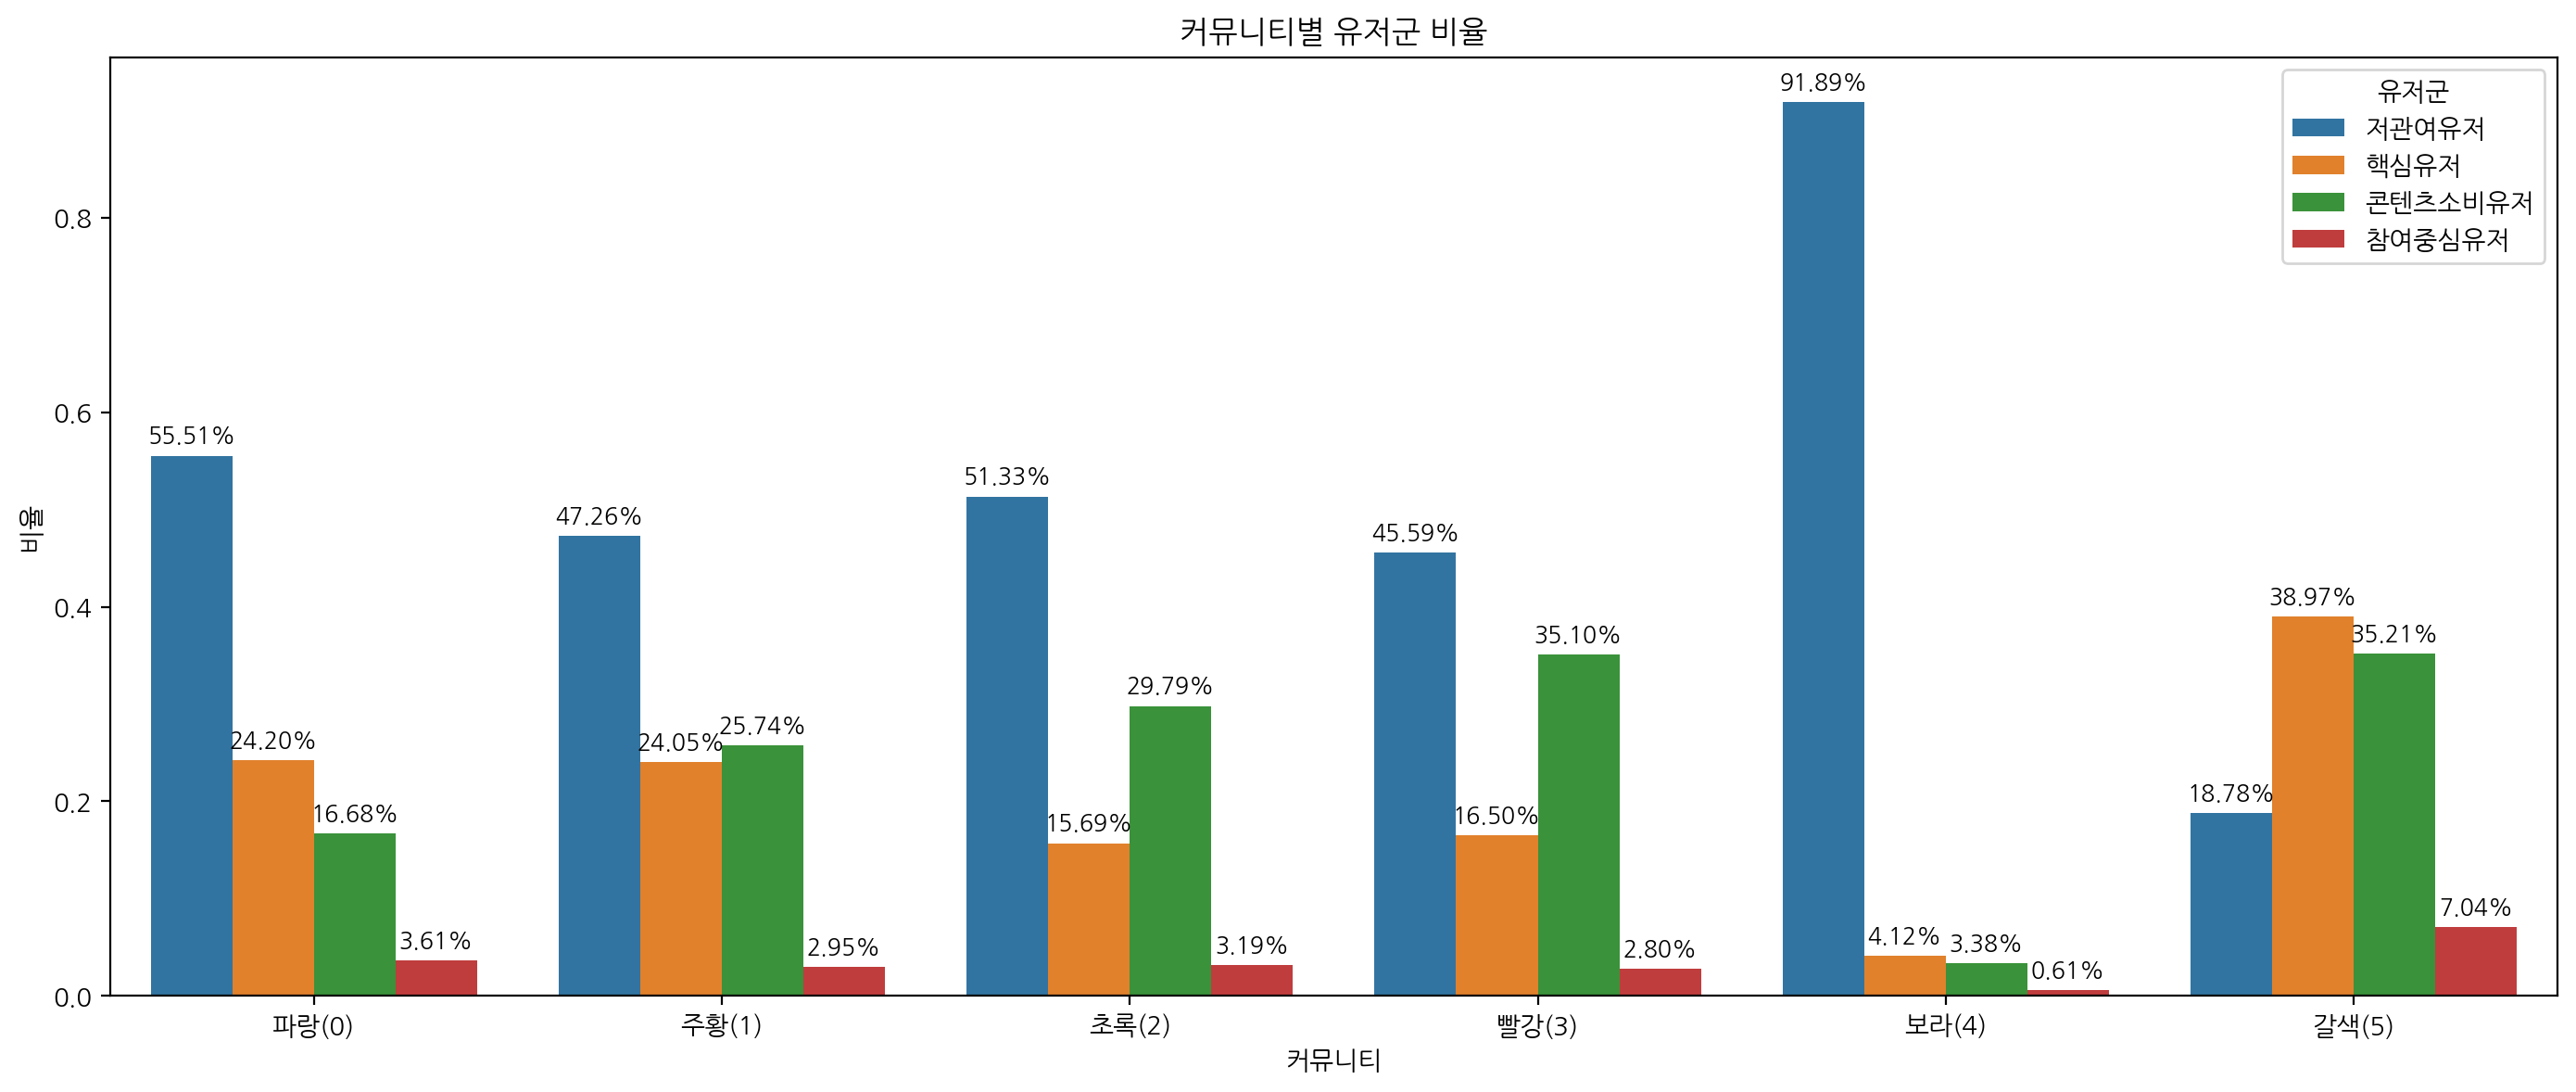

In [375]:
# 막대 그래프 그리기
plt.figure(figsize=(14, 6))
ax = sns.barplot(data=community_summary_df, x='커뮤니티명', y='비율', hue='유저군')

# 바 위에 비율 표시
for container in ax.containers:
    ax.bar_label(container, labels=[f'{v.get_height():.2%}' for v in container], label_type='edge', padding=3, fontsize=9)

plt.title('커뮤니티별 유저군 비율')
plt.ylabel('비율')
plt.xlabel('커뮤니티') 
plt.legend(title='유저군')
plt.tight_layout()
plt.show()

#### 커뮤니티별 네트워크 평균 지표 보기

In [376]:
community_groups[0].head()

,user_id,degree,closeness,betweenness,pagerank,dbscan_community,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,친구요청받은수,친구요청거절수,친구요청수락수,친구요청펜딩수,친구요청받은후거절한수,친구요청받은후수락한수,is_push_on,ban_status,gender,초성오픈수,답장수,답장까지소요시간(분),열람수,투표받은수,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수,투표활발도,답장활발도,콘텐츠소비도,참여중심유저,콘텐츠소비유저,유저군
0,915445,226,0.076508,0.002175,0.000239,0.0,2023-05-06,0,86,111,95.0,160.0,1.0,68.0,26.0,1.0,158.0,0,N,F,15.0,181.0,387.058103,821.0,876.0,0.0,585.523333,391.0,325.0,매우높음,매우높음,매우높음,1,1,핵심유저
1,915060,202,0.077308,0.003962,0.000215,0.0,2023-05-06,1,99,58,164.0,94.0,12.0,110.0,42.0,0.0,92.0,1,N,F,1.0,188.0,420.887677,214.0,302.0,0.0,360.086111,76.0,68.0,낮음,매우높음,낮음,0,0,저관여유저
2,854632,26,0.075522,0.007273,0.000196,0.0,2023-04-29,3,105,17,15.0,13.0,0.0,13.0,2.0,0.0,13.0,1,N,F,0.0,0.0,NaN,0.0,0.0,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저
3,1435526,181,0.078145,0.004868,0.000189,0.0,2023-05-21,1,50,51,282.0,21.0,8.0,173.0,101.0,0.0,8.0,1,N,M,14.0,0.0,0.000000,309.0,314.0,0.0,1440.188889,98.0,95.0,중간,답장1회,높음,0,1,콘텐츠소비유저
4,1184867,164,0.083086,0.012097,0.000185,0.0,2023-05-12,0,114,40,244.0,16.0,17.0,164.0,63.0,0.0,0.0,1,N,M,1.0,1.0,1459.166667,51.0,203.0,0.0,107.473333,48.0,48.0,낮음,답장1회,낮음,0,0,저관여유저


In [377]:
selected_columns = [
    # 행동변수
    '출석주기', '마지막출석후경과일', '출석일수',
    '친구요청수', '친구요청받은수',
    '초성오픈수',
    '답장수', '열람수', '투표받은수', '질문차단수', '투표한수',

    # 속성변수
    'user_id', 'dbscan_community', '커뮤니티명', 'degree', 'closeness', 'betweenness', 'pagerank',
    'is_push_on', 'ban_status',
    'gender', '유저군', '투표활발도', '답장활발도', '콘텐츠소비도'
]

In [378]:
extinct_selected = extinct_community.loc[:, selected_columns]

In [379]:
# 열 개수 제한 해제 → 모든 컬럼이 출력됨
pd.set_option('display.max_columns', None)

# 각 컬럼 안에 텍스트 길이 제한 해제
pd.set_option('display.max_colwidth', None)

# 전체 출력 너비 증가
pd.set_option('display.width', 2000)  # 넉넉하게 설정

In [380]:
# 1. 범주형 변수 리스트
categorical_cols = [ 'user_id', 
    'is_push_on', 'ban_status', '커뮤니티명',
    'gender', '유저군', '투표활발도', '답장활발도', '콘텐츠소비도', 'dbscan_community'
]

# 2. 수치형 변수 리스트
numeric_cols = [col for col in extinct_selected.columns if col not in categorical_cols]

# 3. 수치형 정규화
scaler = StandardScaler()
scaled_values = scaler.fit_transform(extinct_selected[numeric_cols])

# 4. 정규화된 값으로 DataFrame 만들기
scaled_df = pd.DataFrame(scaled_values, columns=numeric_cols, index=extinct_selected.index)

# 5. 원본에 덮어쓰기 (or 새 컬럼 추가)
extinct_scaled = extinct_selected.copy()
extinct_scaled[numeric_cols] = scaled_df

In [381]:
# 한글 커뮤니티명 리스트
community_map = {
    'brown': '갈색',
    'purple': '보라',
    'red': '빨강',
    'blue': '파랑',
    'orange': '주황',
    'green': '초록'
}

# 각 영어 이름을 변수명으로, 커뮤니티명을 기준으로 DataFrame 필터링
for var_name, community_name in community_map.items():
    globals()[var_name] = extinct_scaled[extinct_scaled['커뮤니티명'] == community_name]

In [382]:
# 커뮤니티 영어이름 → 한글이름 매핑
community_map = {
    'brown': '갈색',
    'purple': '보라',
    'red': '빨강',
    'blue': '파랑',
    'orange': '주황',
    'green': '초록'
}

# 수치형 변수 (mean 적용)
mean_cols = [
    '출석주기', '마지막출석후경과일', '출석일수',
    '친구요청수', '친구요청받은수',
    '초성오픈수',
    '답장수', '열람수', '투표받은수', '질문차단수', '투표한수',
    'degree', 'closeness', 'betweenness', 'pagerank'
]

# 전체 변수 + 집계함수 지정
agg_dict = {col: 'mean' for col in mean_cols}


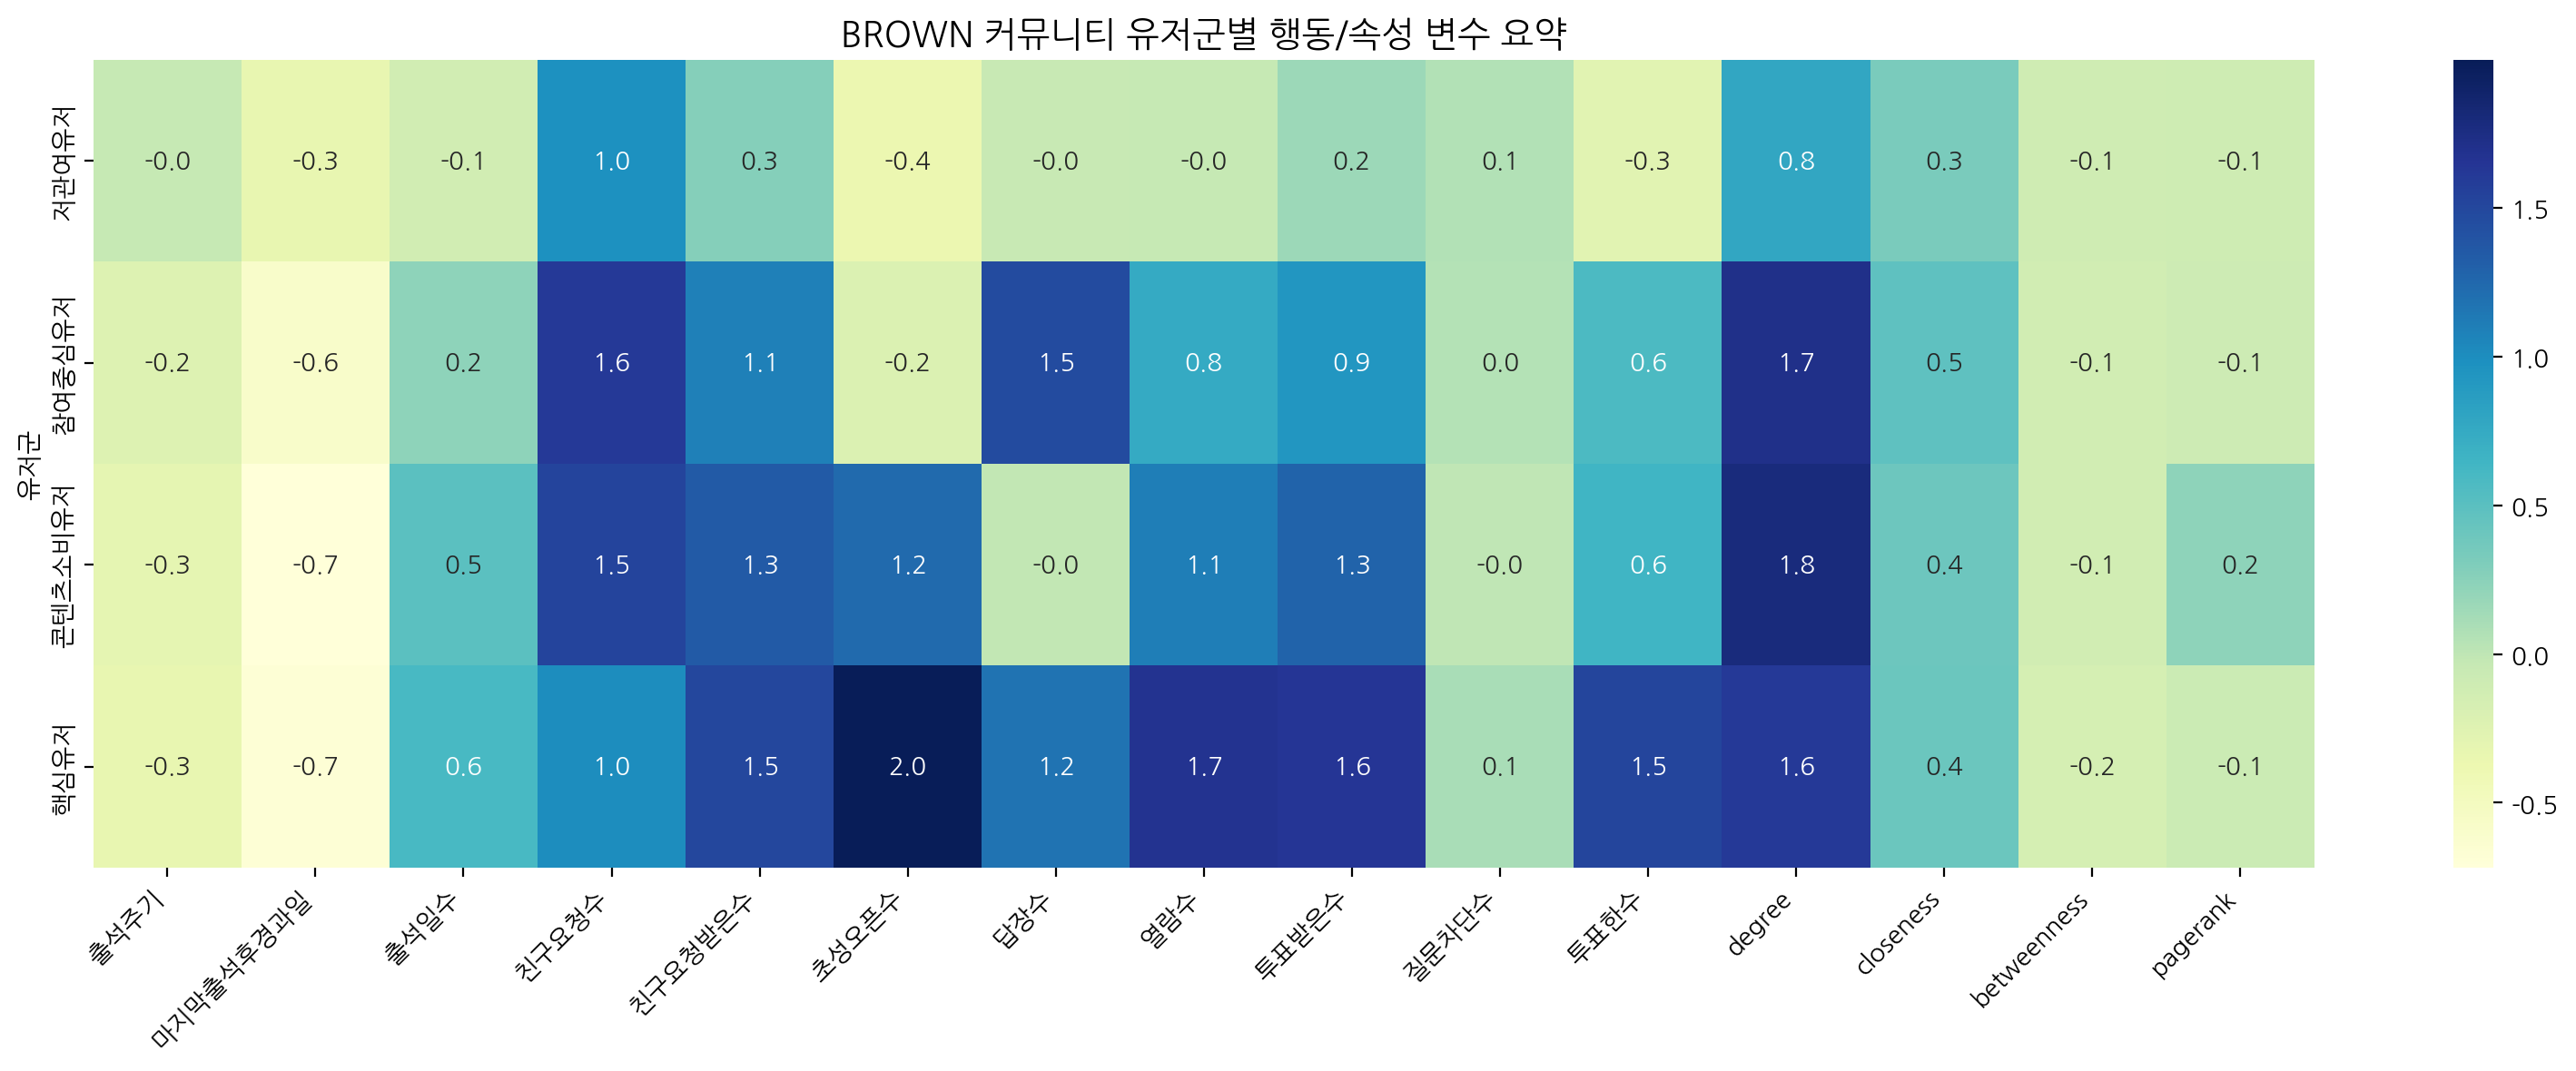

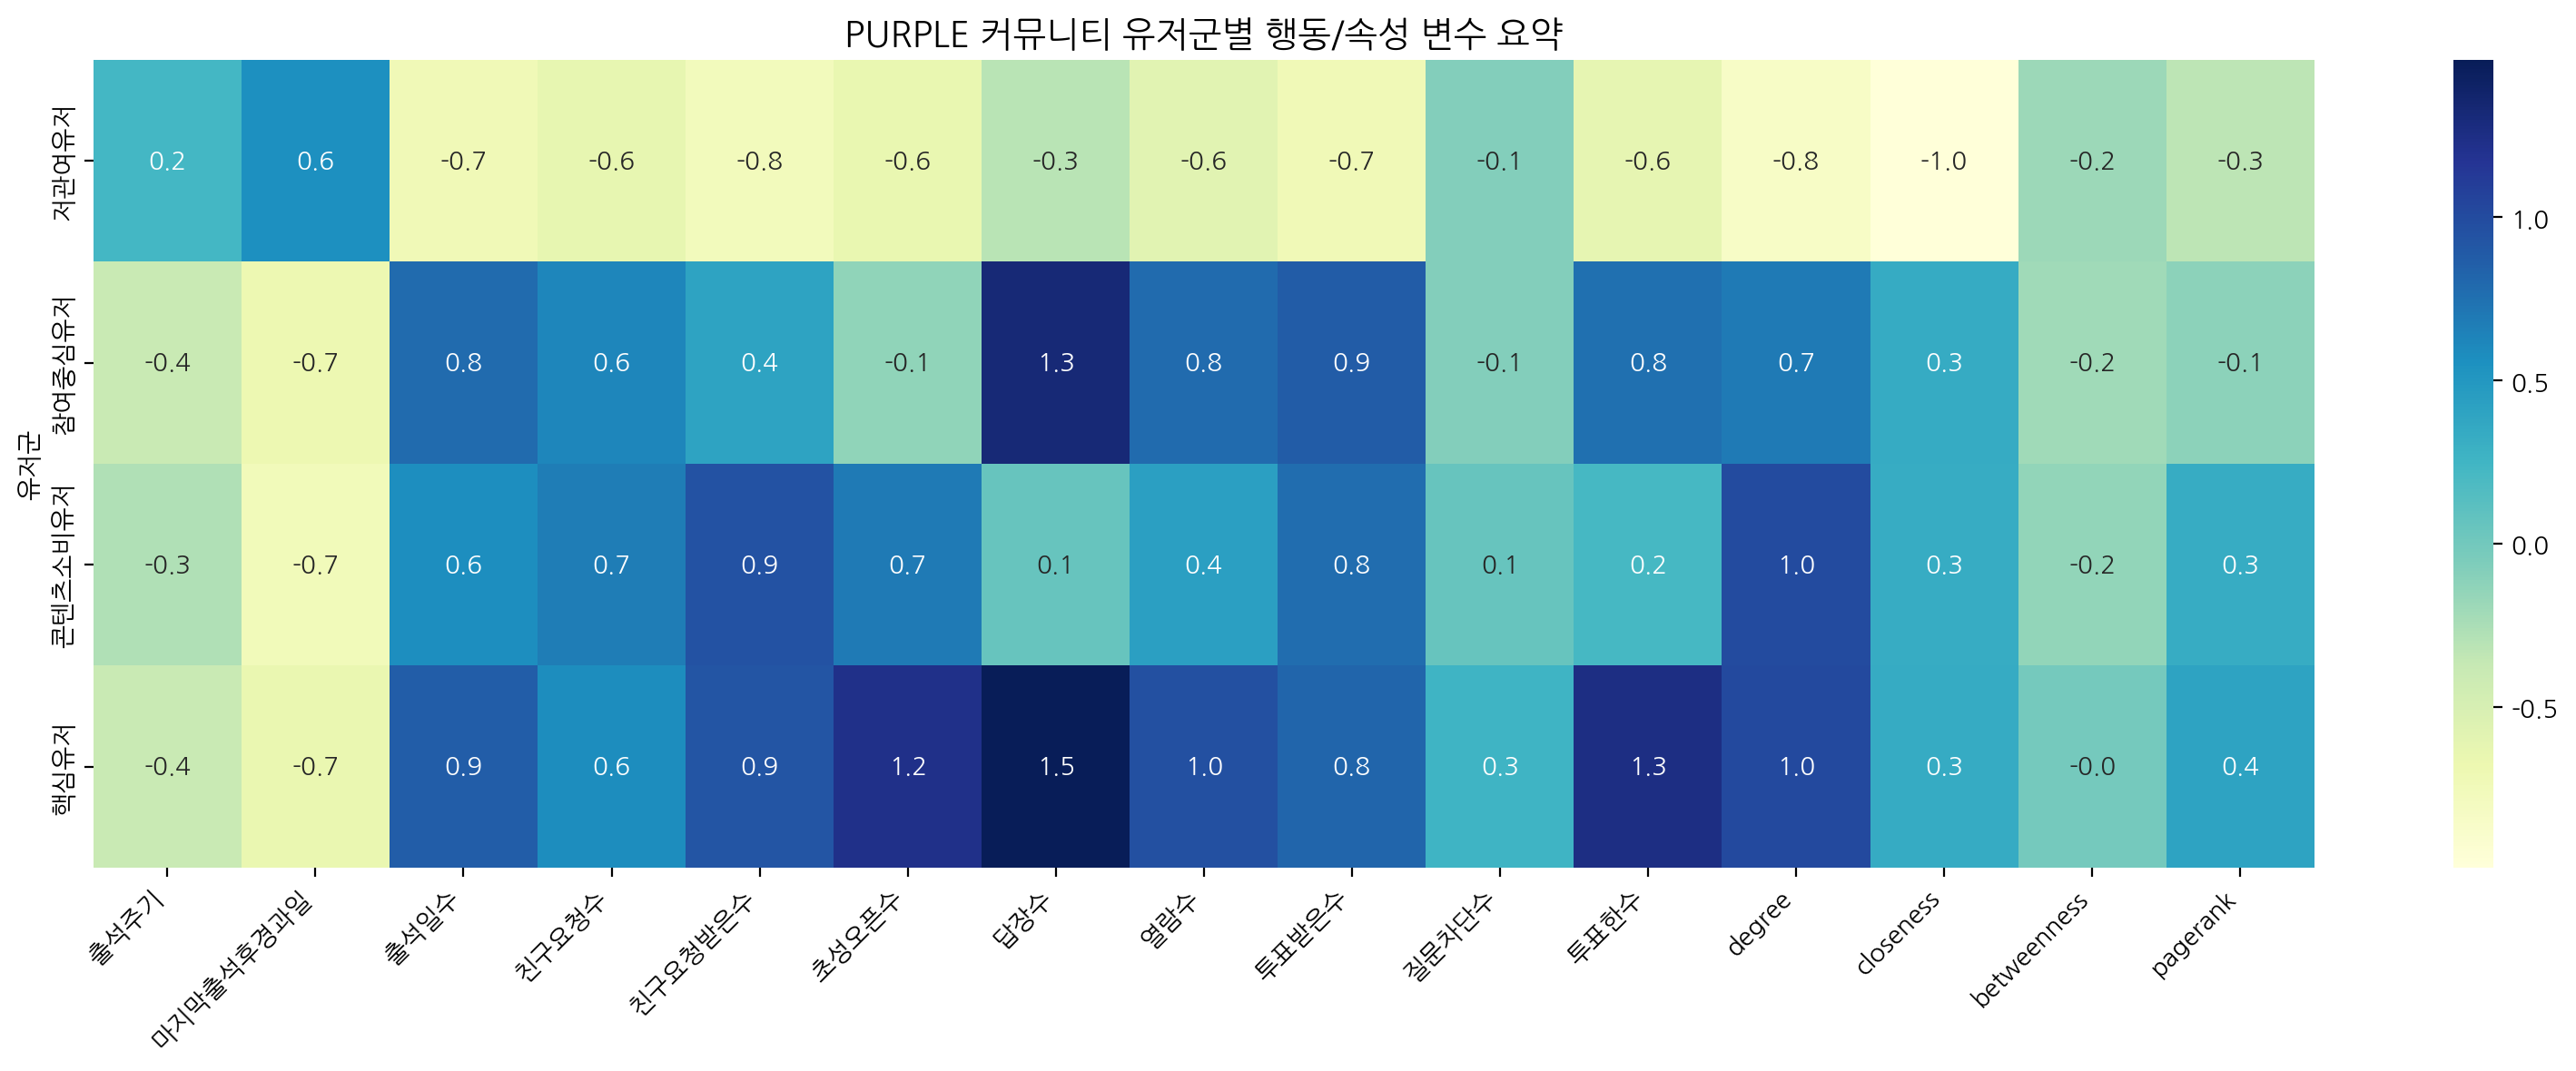

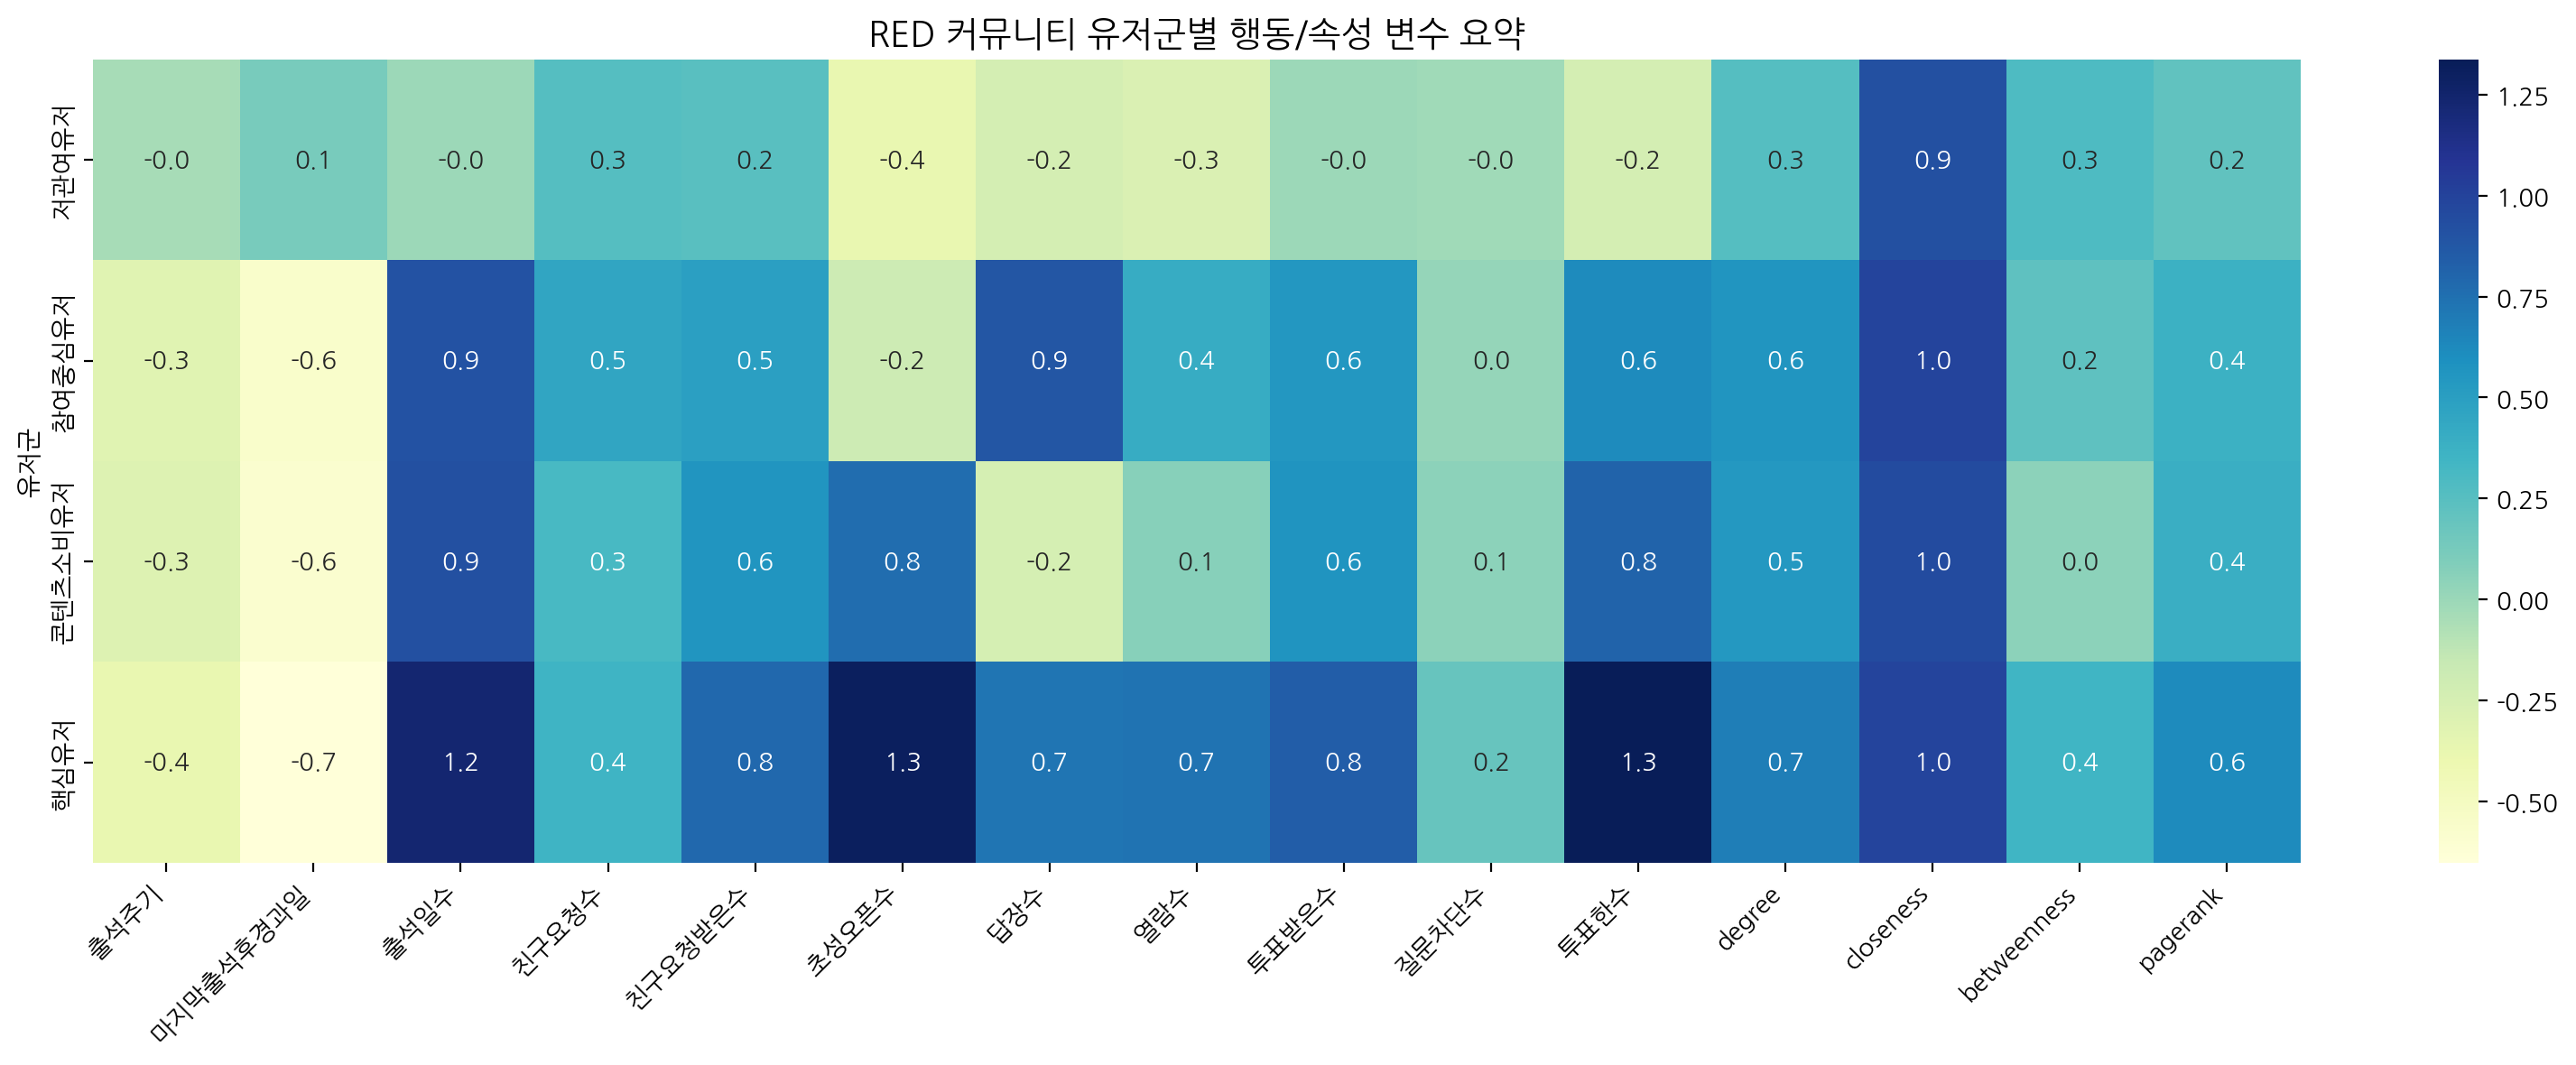

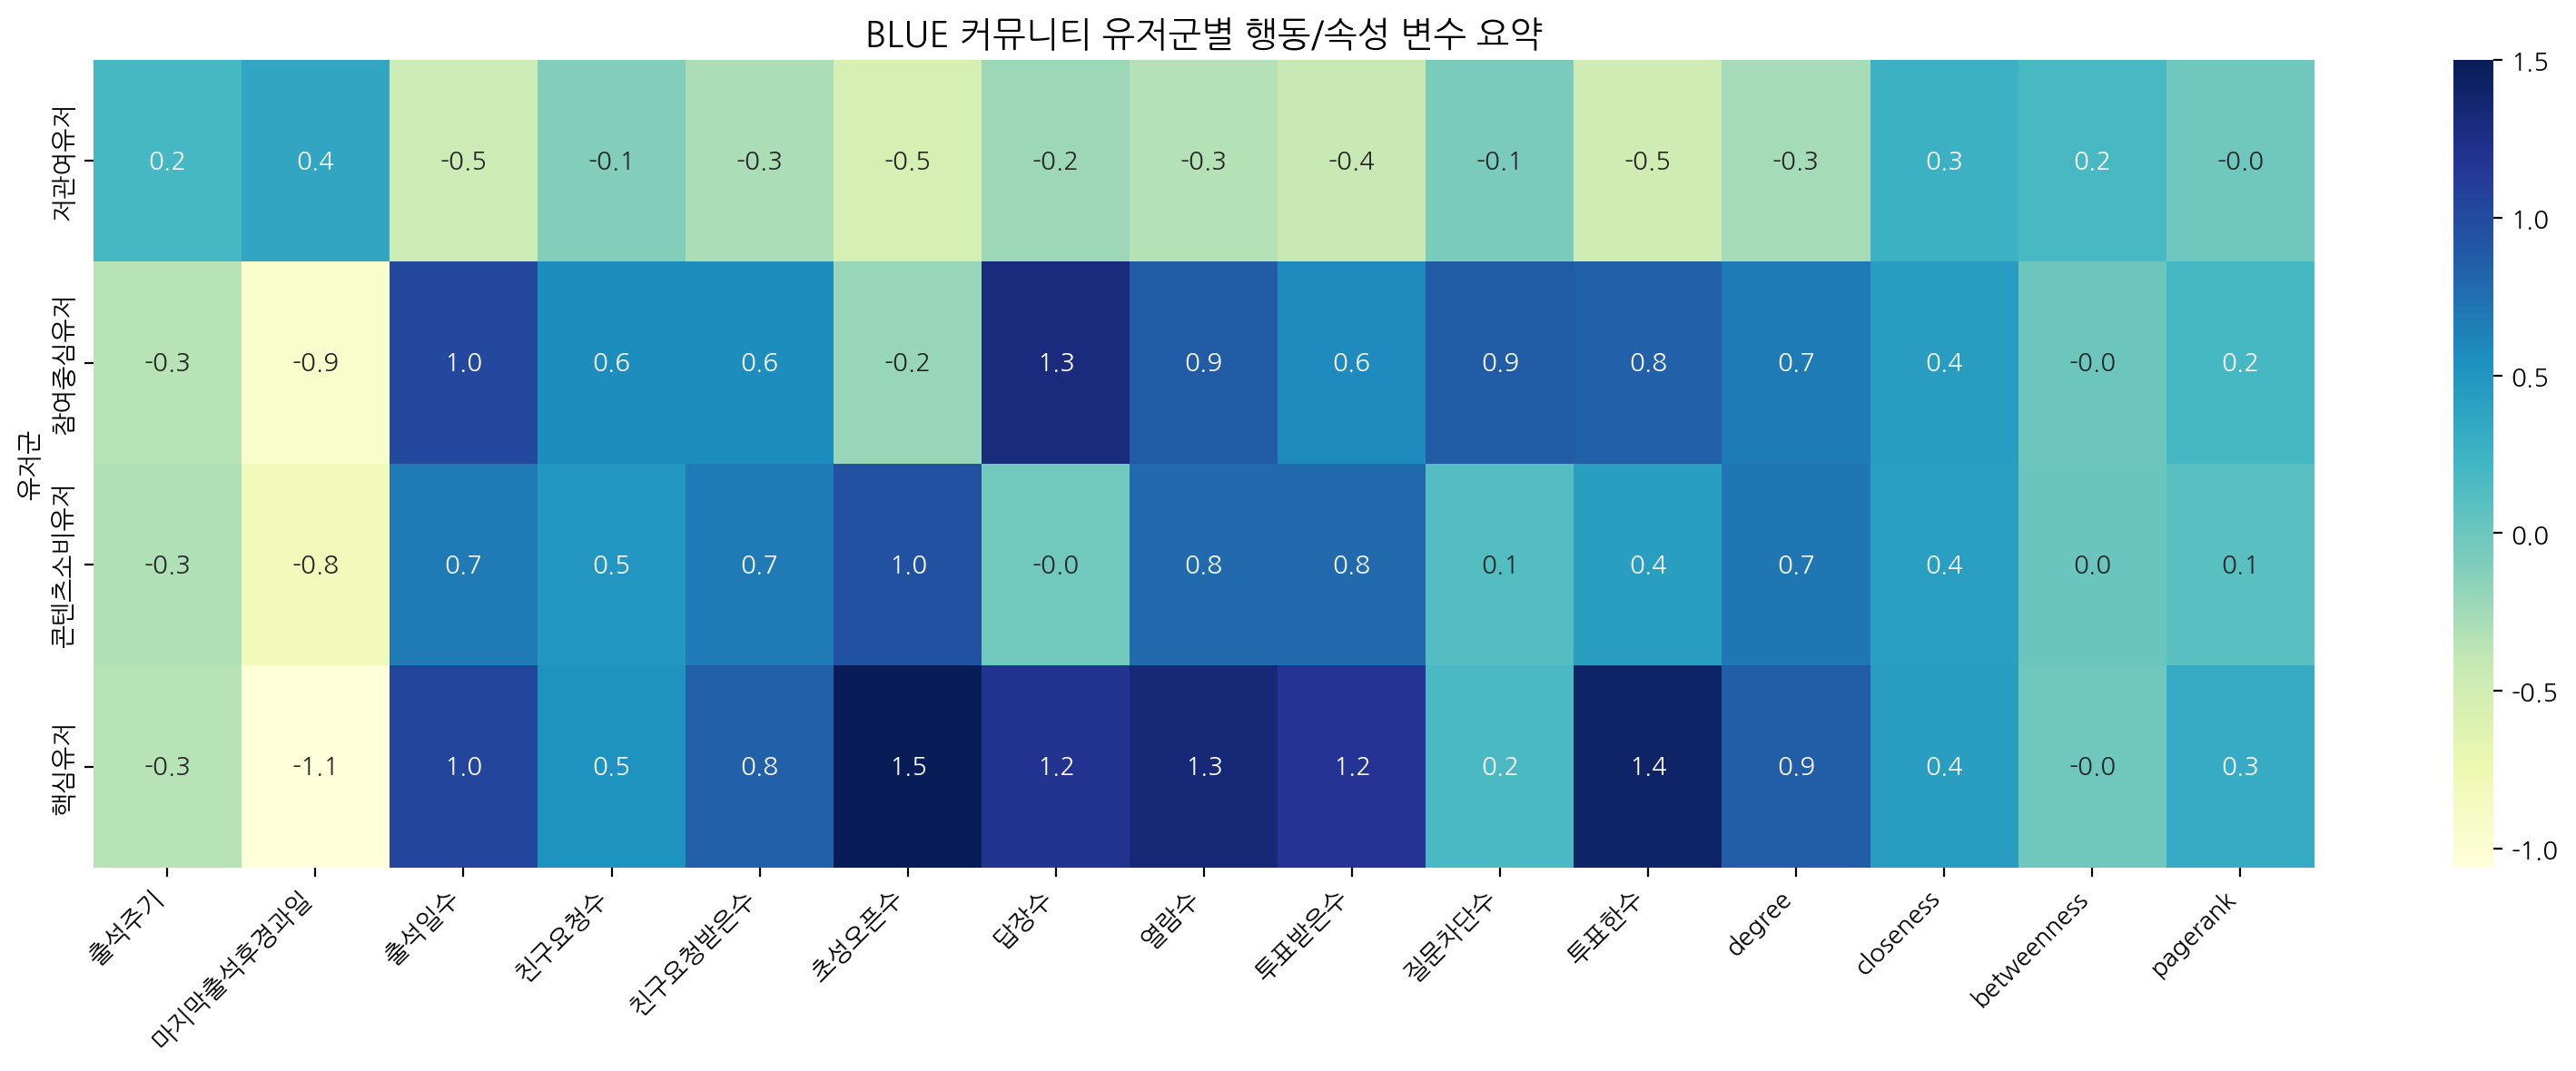

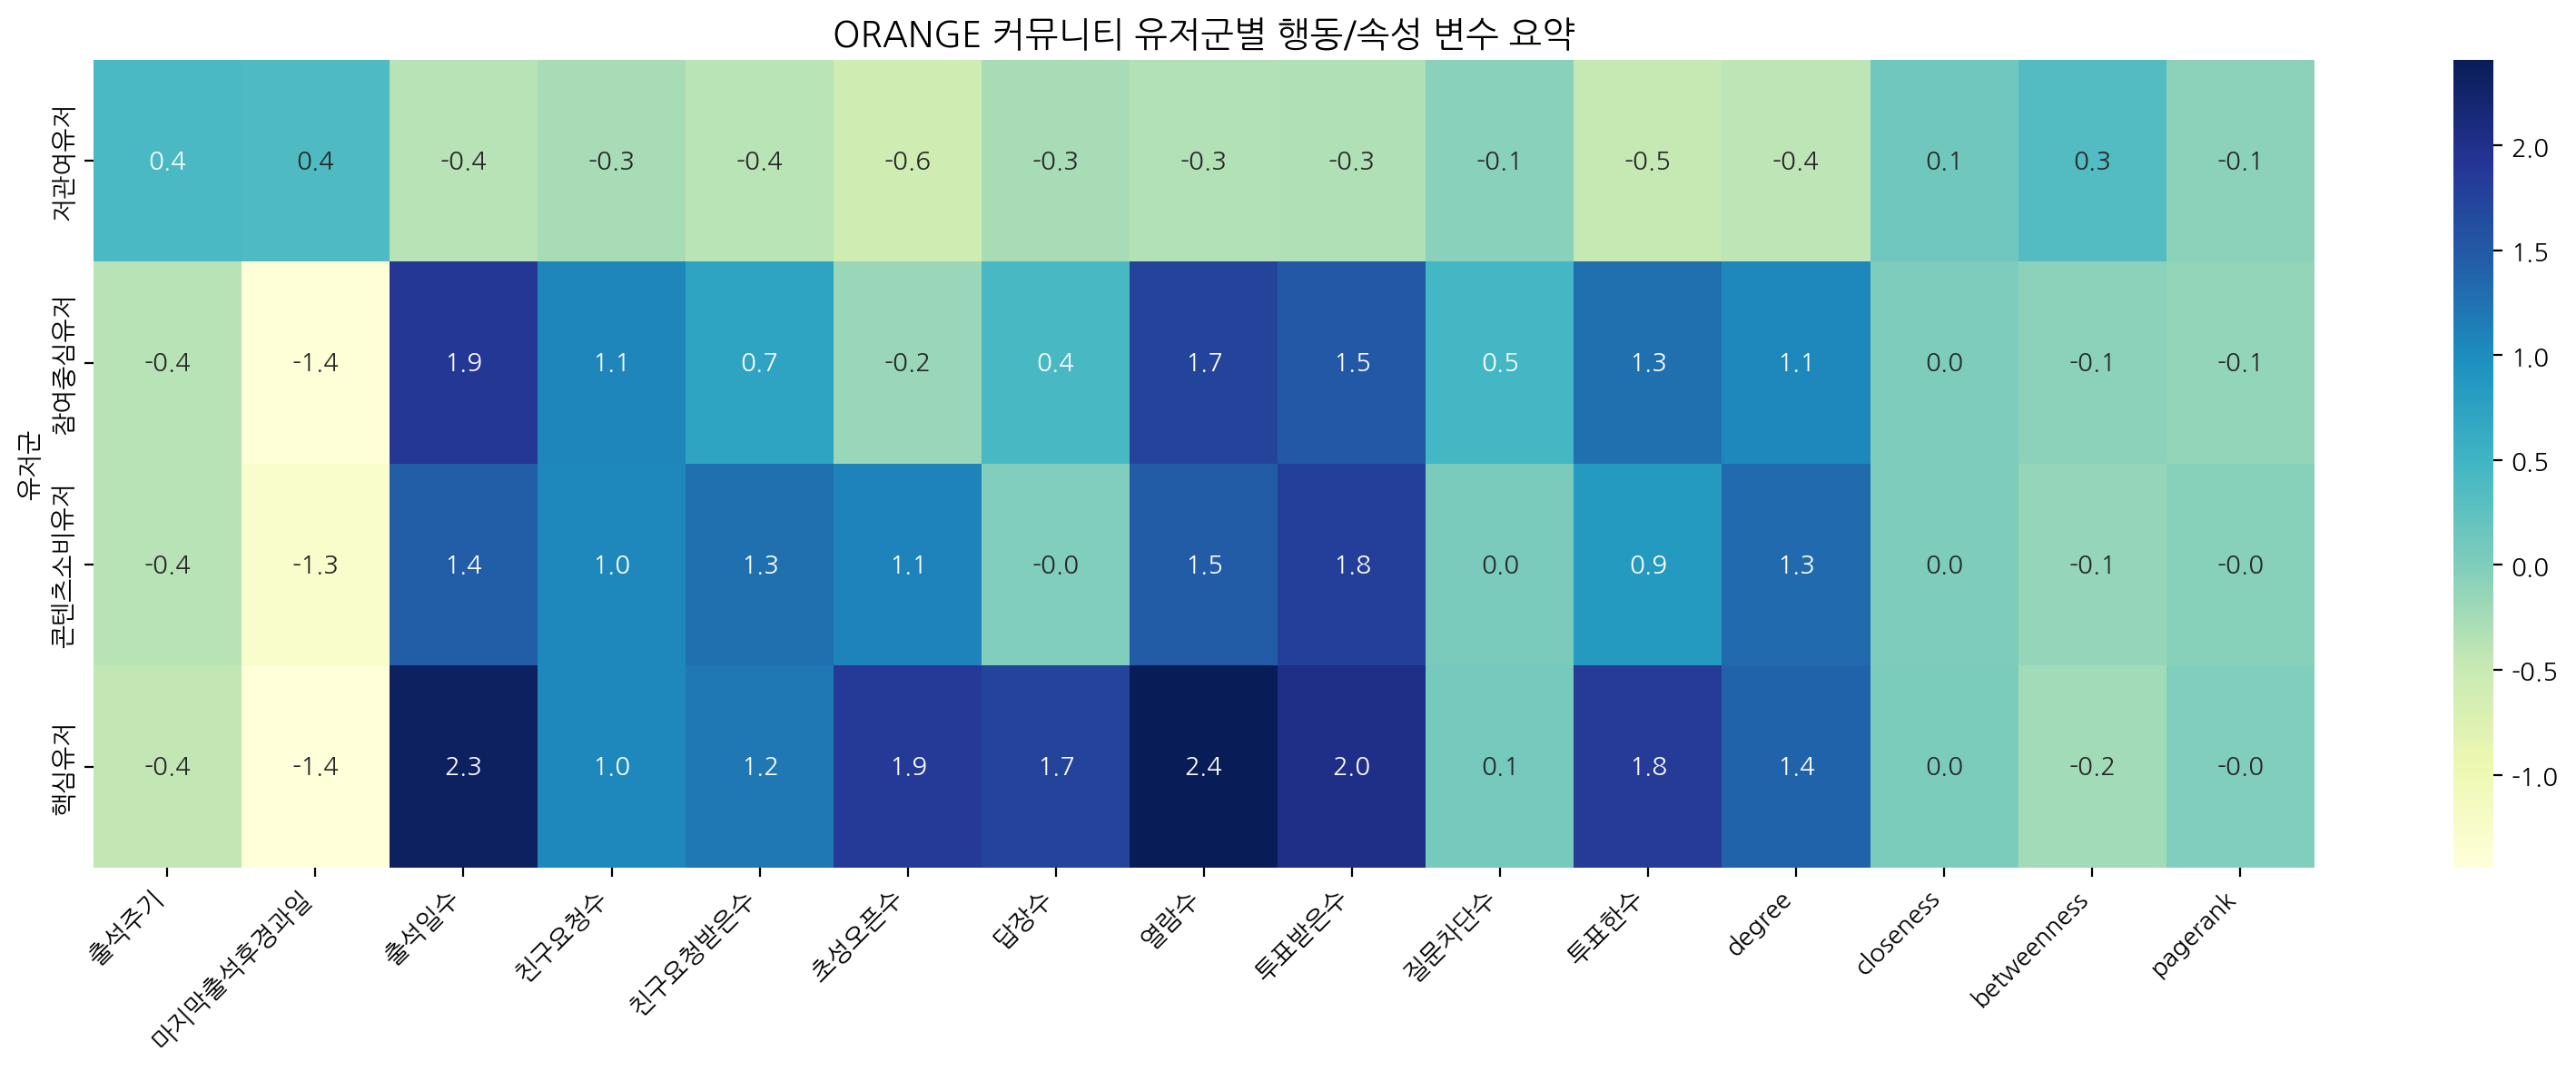

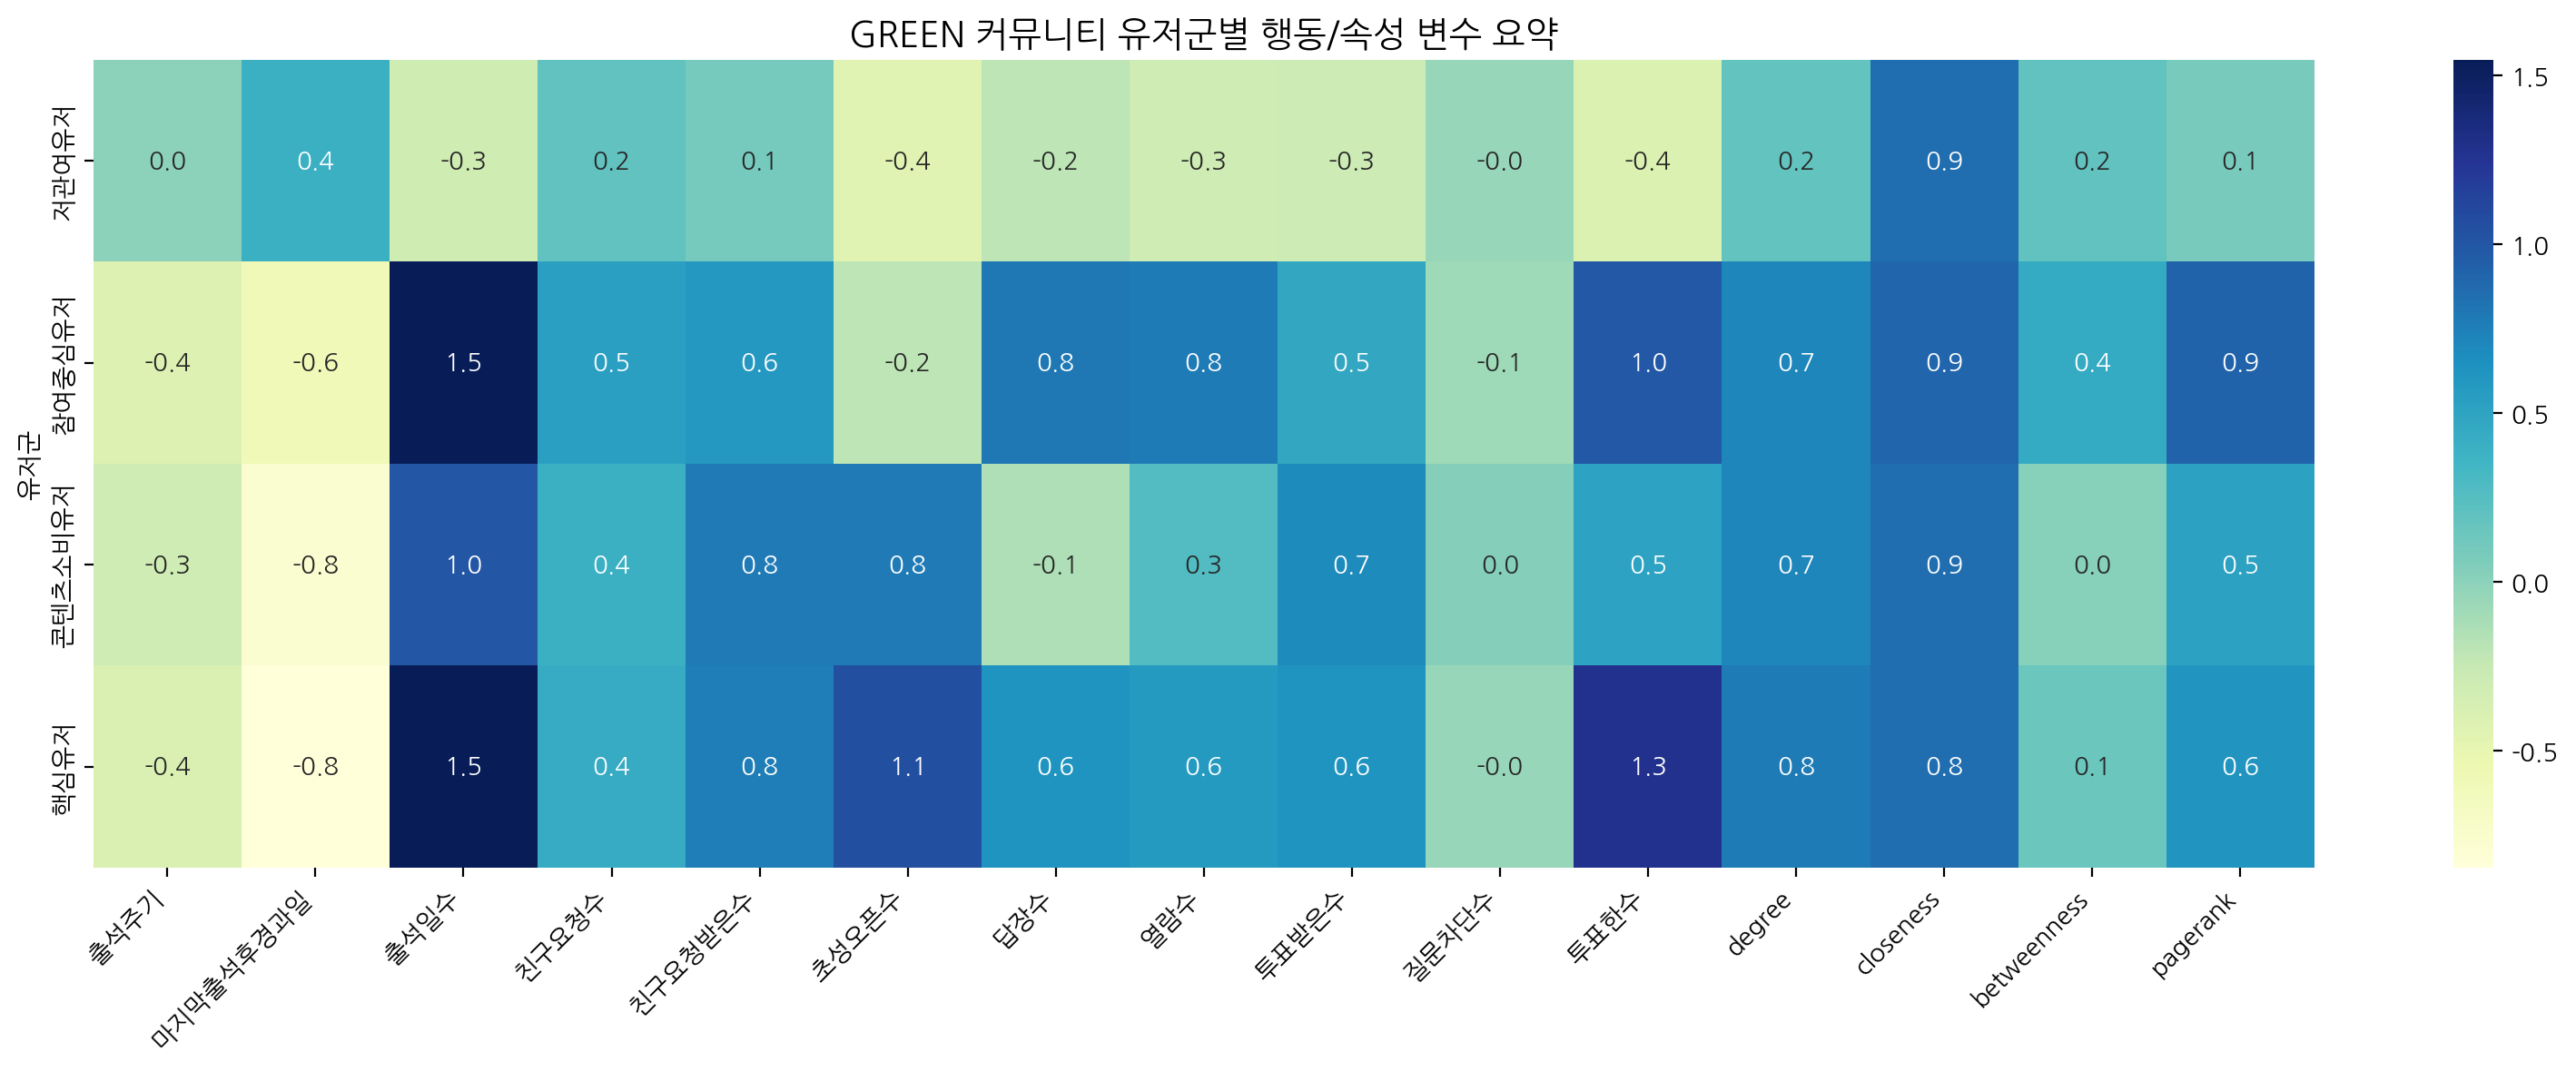

In [383]:
# 반복 시각화
for eng_name, kor_name in community_map.items():
    df = extinct_scaled[extinct_scaled['커뮤니티명'] == kor_name]
    
    # 유저군별 집계
    grouped = df.groupby('유저군').agg(agg_dict)

    # 시각화
    plt.figure(figsize=(16, 6))
    sns.heatmap(grouped, annot=True, fmt=".1f", cmap='YlGnBu')
    plt.title(f"{eng_name.upper()} 커뮤니티 유저군별 행동/속성 변수 요약", fontsize=14)
    plt.ylabel('유저군')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

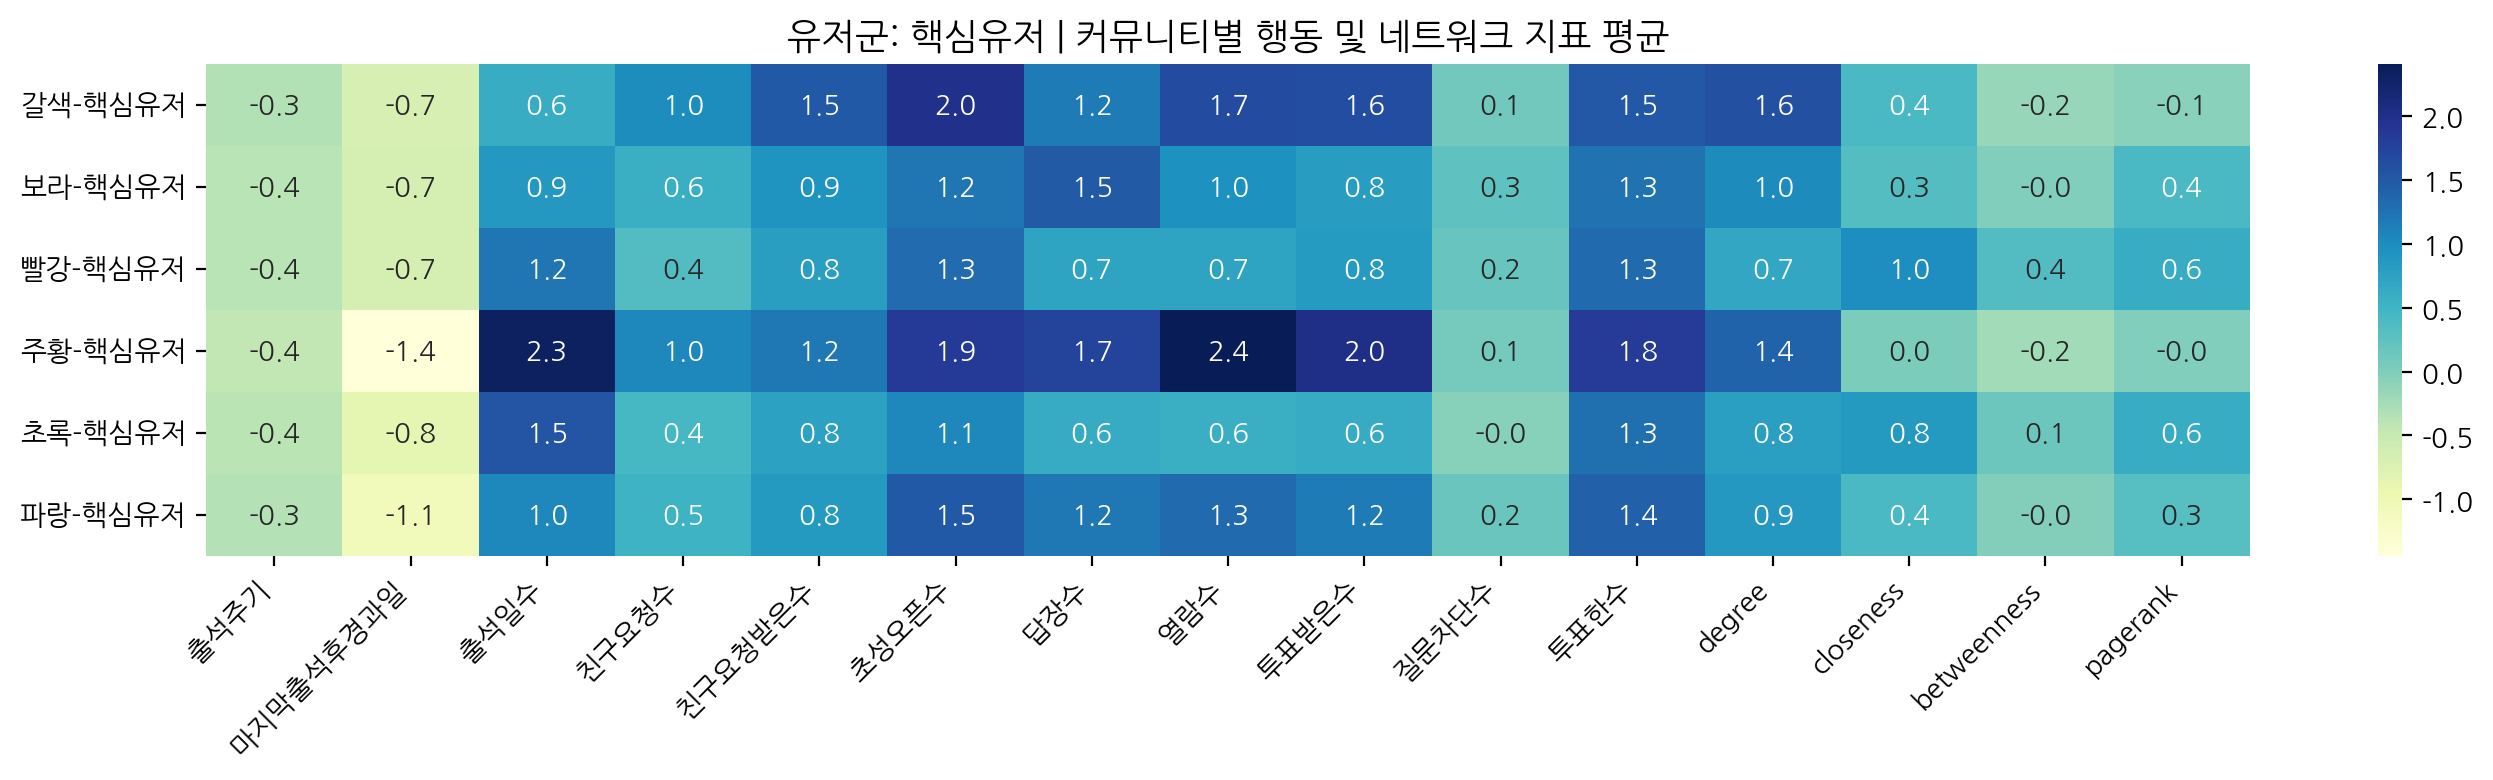

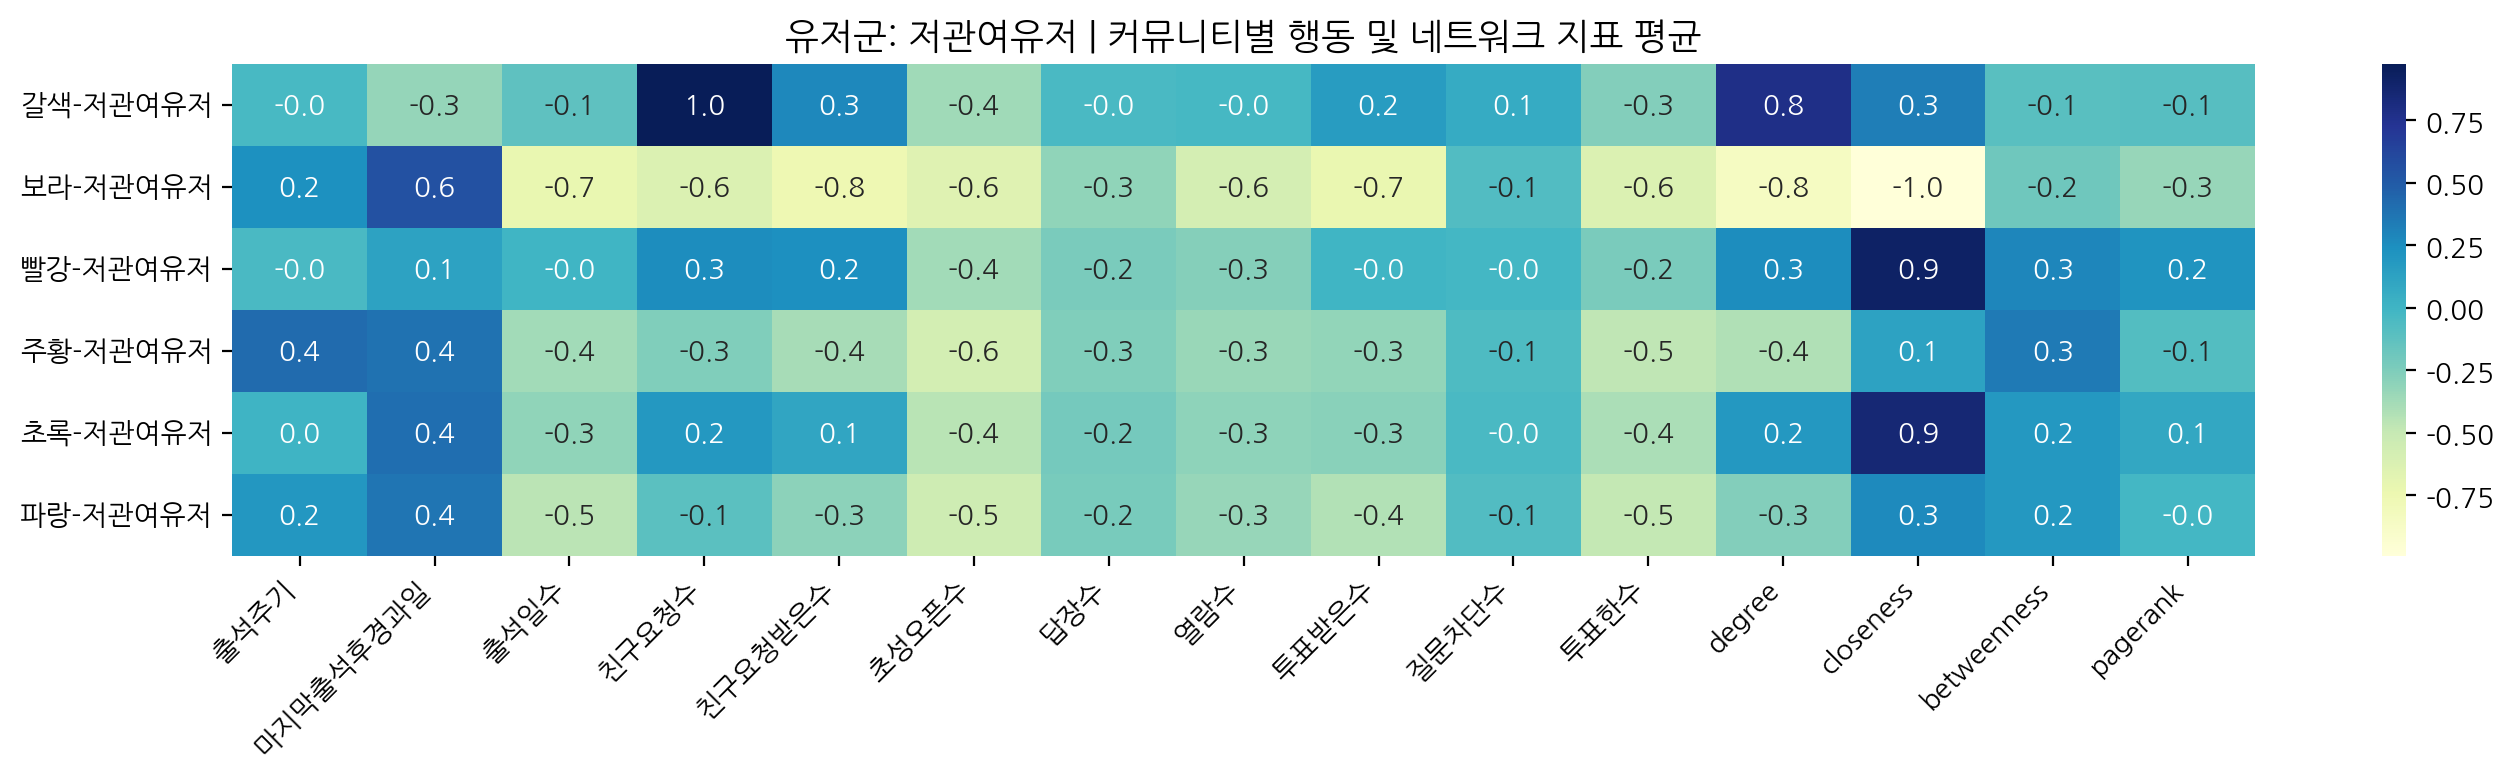

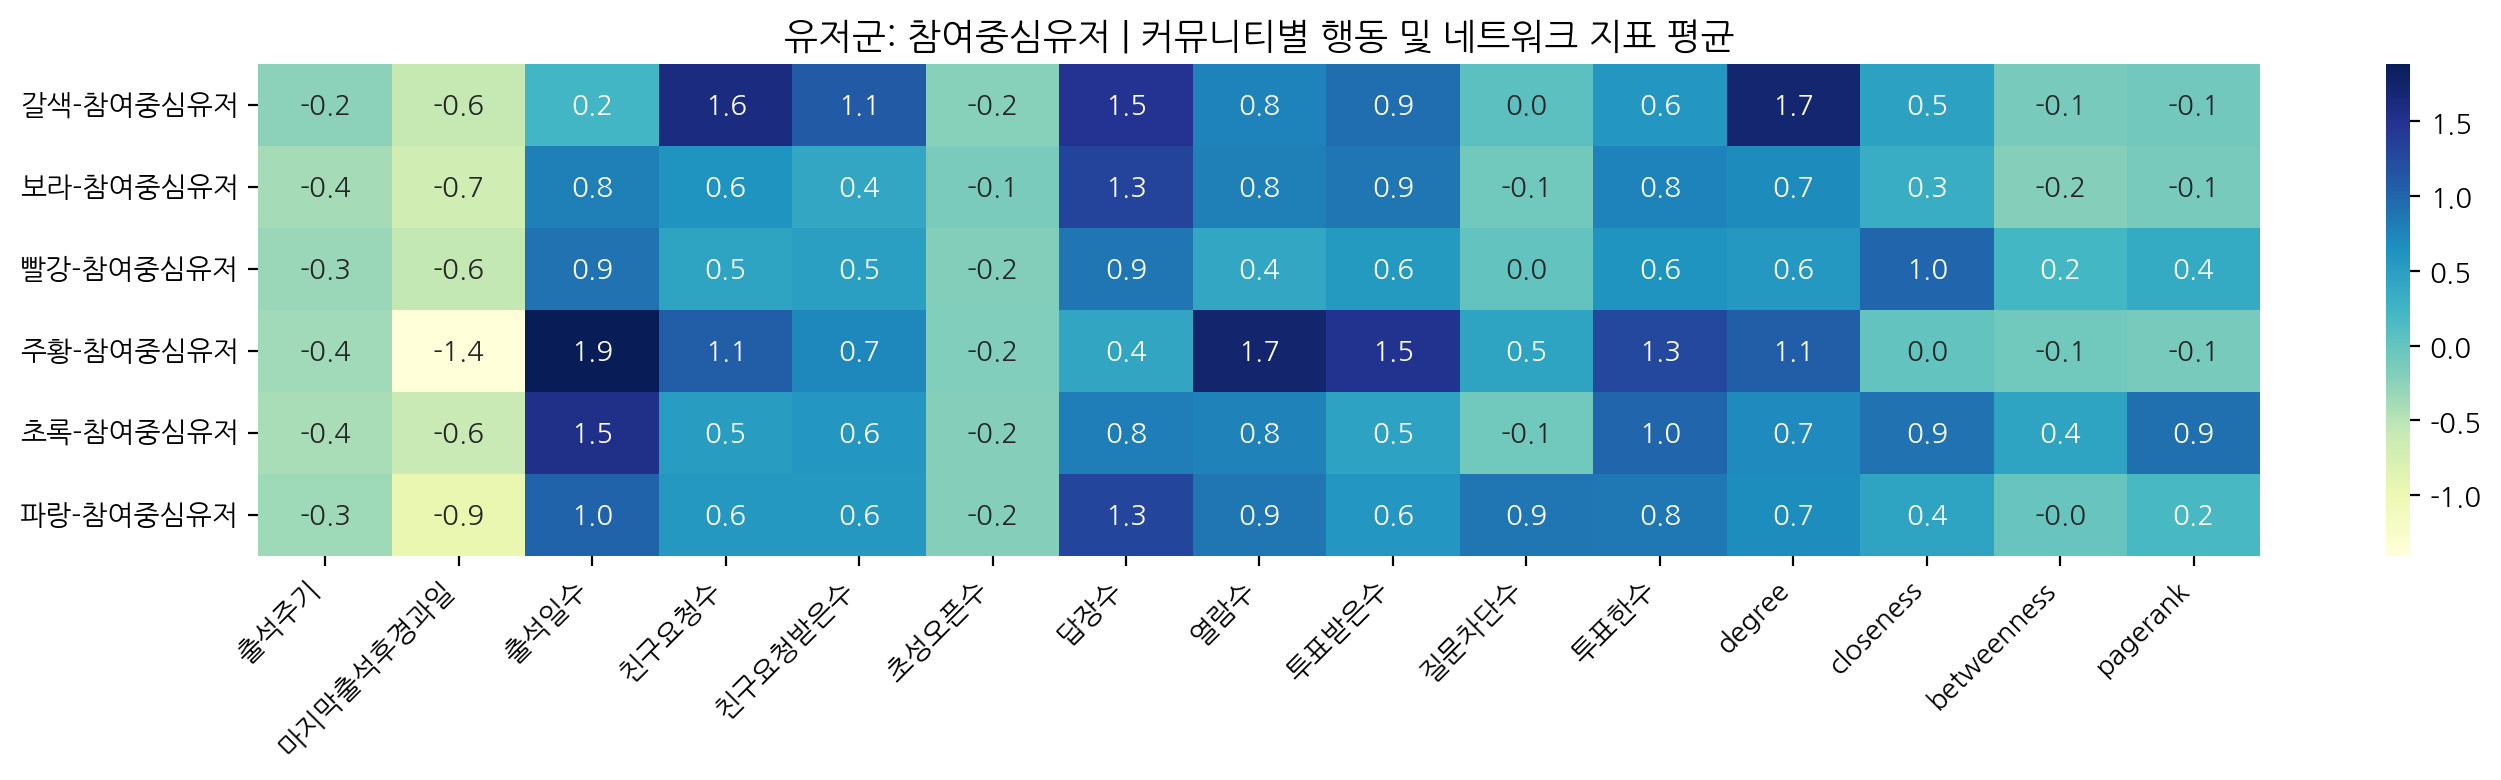

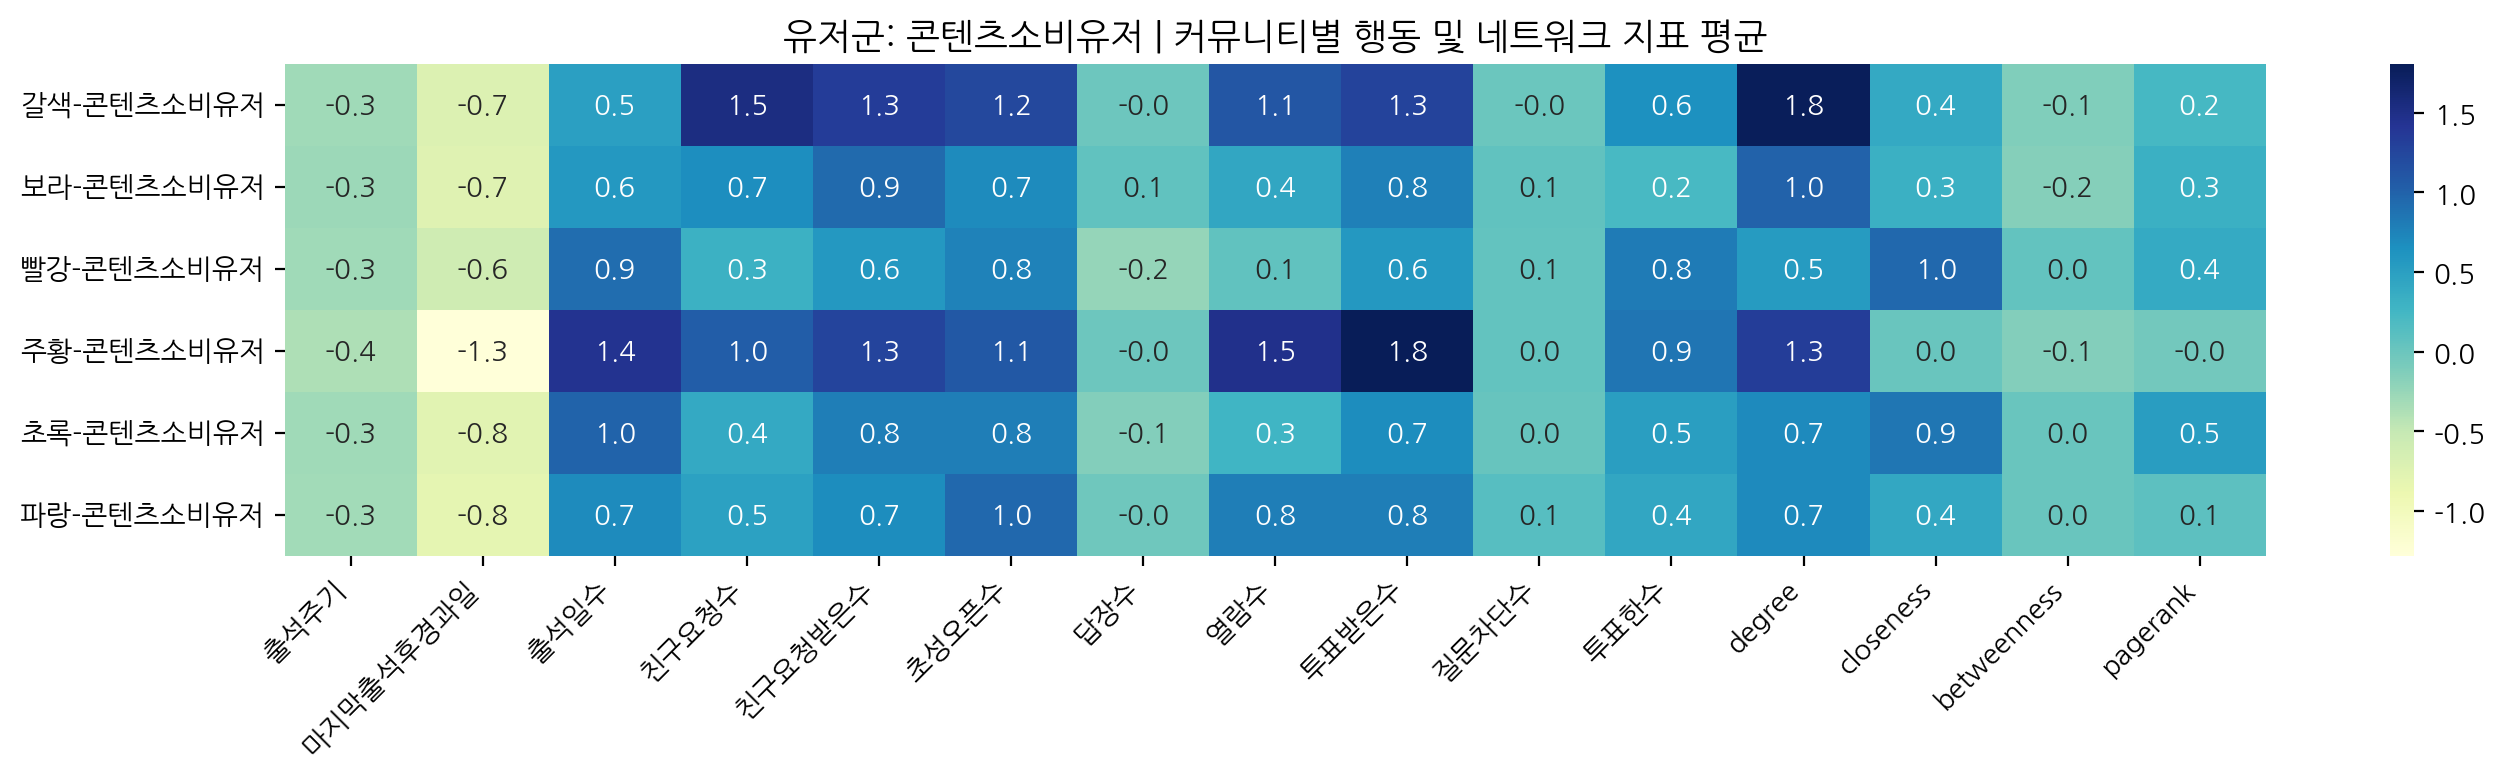

In [384]:
x_tick_labels = {
    0: '파랑',
    1: '주황',
    2: '초록',
    3: '빨강',
    4: '보라',
    5: '갈색',
}

# 수치형 지표 목록
mean_cols = [
    '출석주기', '마지막출석후경과일', '출석일수',
    '친구요청수', '친구요청받은수',
    '초성오픈수',
    '답장수', '열람수', '투표받은수', '질문차단수', '투표한수',
    'degree', 'closeness', 'betweenness', 'pagerank'
]

# 전처리: 커뮤니티명 만들기
extinct_scaled = extinct_scaled[extinct_scaled['dbscan_community'].isin(x_tick_labels.keys())].copy()
extinct_scaled['dbscan_community'] = extinct_scaled['dbscan_community'].astype(int)
extinct_scaled['커뮤니티명'] = extinct_scaled['dbscan_community'].map(x_tick_labels)

# 유저군 종류 추출
user_types = extinct_scaled['유저군'].dropna().unique()

# 반복문으로 히트맵 그리기
for user_type in user_types:
    # 해당 유저군만 필터링
    df_sub = extinct_scaled[extinct_scaled['유저군'] == user_type]
    
    # 커뮤니티명 기준 그룹 평균
    grouped = df_sub.groupby('커뮤니티명')[mean_cols].mean()
    
    # 인덱스를 "커뮤니티명-유저군" 형식으로
    grouped.index = [f"{comm}-{user_type}" for comm in grouped.index]
    
    # 히트맵 그리기
    plt.figure(figsize=(14, 4))
    sns.heatmap(grouped, annot=True, fmt=".1f", cmap='YlGnBu')
    plt.title(f"유저군: {user_type} | 커뮤니티별 행동 및 네트워크 지표 평균", fontsize=13)
    plt.ylabel('')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 4. 클러스터링

In [112]:
cluster_df = pd.read_csv('/Users/SongKG/Documents/codeit_study/고급_프로젝트/고급 프로젝트 통합 코드.ipynb/cluster.csv')
cluster_df = cluster_df.copy()
cluster_df.tail(2)

,user_id,degree,closeness,betweenness,pagerank,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,...,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수,투표활발도,답장활발도,콘텐츠소비도,참여중심유저,콘텐츠소비유저,유저군
20982,1579418,3,0.070502,1.951899e-08,0.000012,2023-07-25,0,65,14,21.0,...,0.0,0.0,49.0,49.0,낮음,답장1회,초성오픈X,0,0,저관여유저
20983,1437407,1,0.000189,0.000000e+00,0.000027,2023-05-21,19,65,5,1.0,...,0.0,NaN,0.0,0.0,투표X,답장1회,초성오픈X,0,0,저관여유저


In [387]:
social_low_user = cluster_df[cluster_df['유저군'] == '저관여유저'].copy()
social_core_user = cluster_df[cluster_df['유저군'] == '핵심유저'].copy()

### 저관여유저 클러스터링

#### K값 찾기

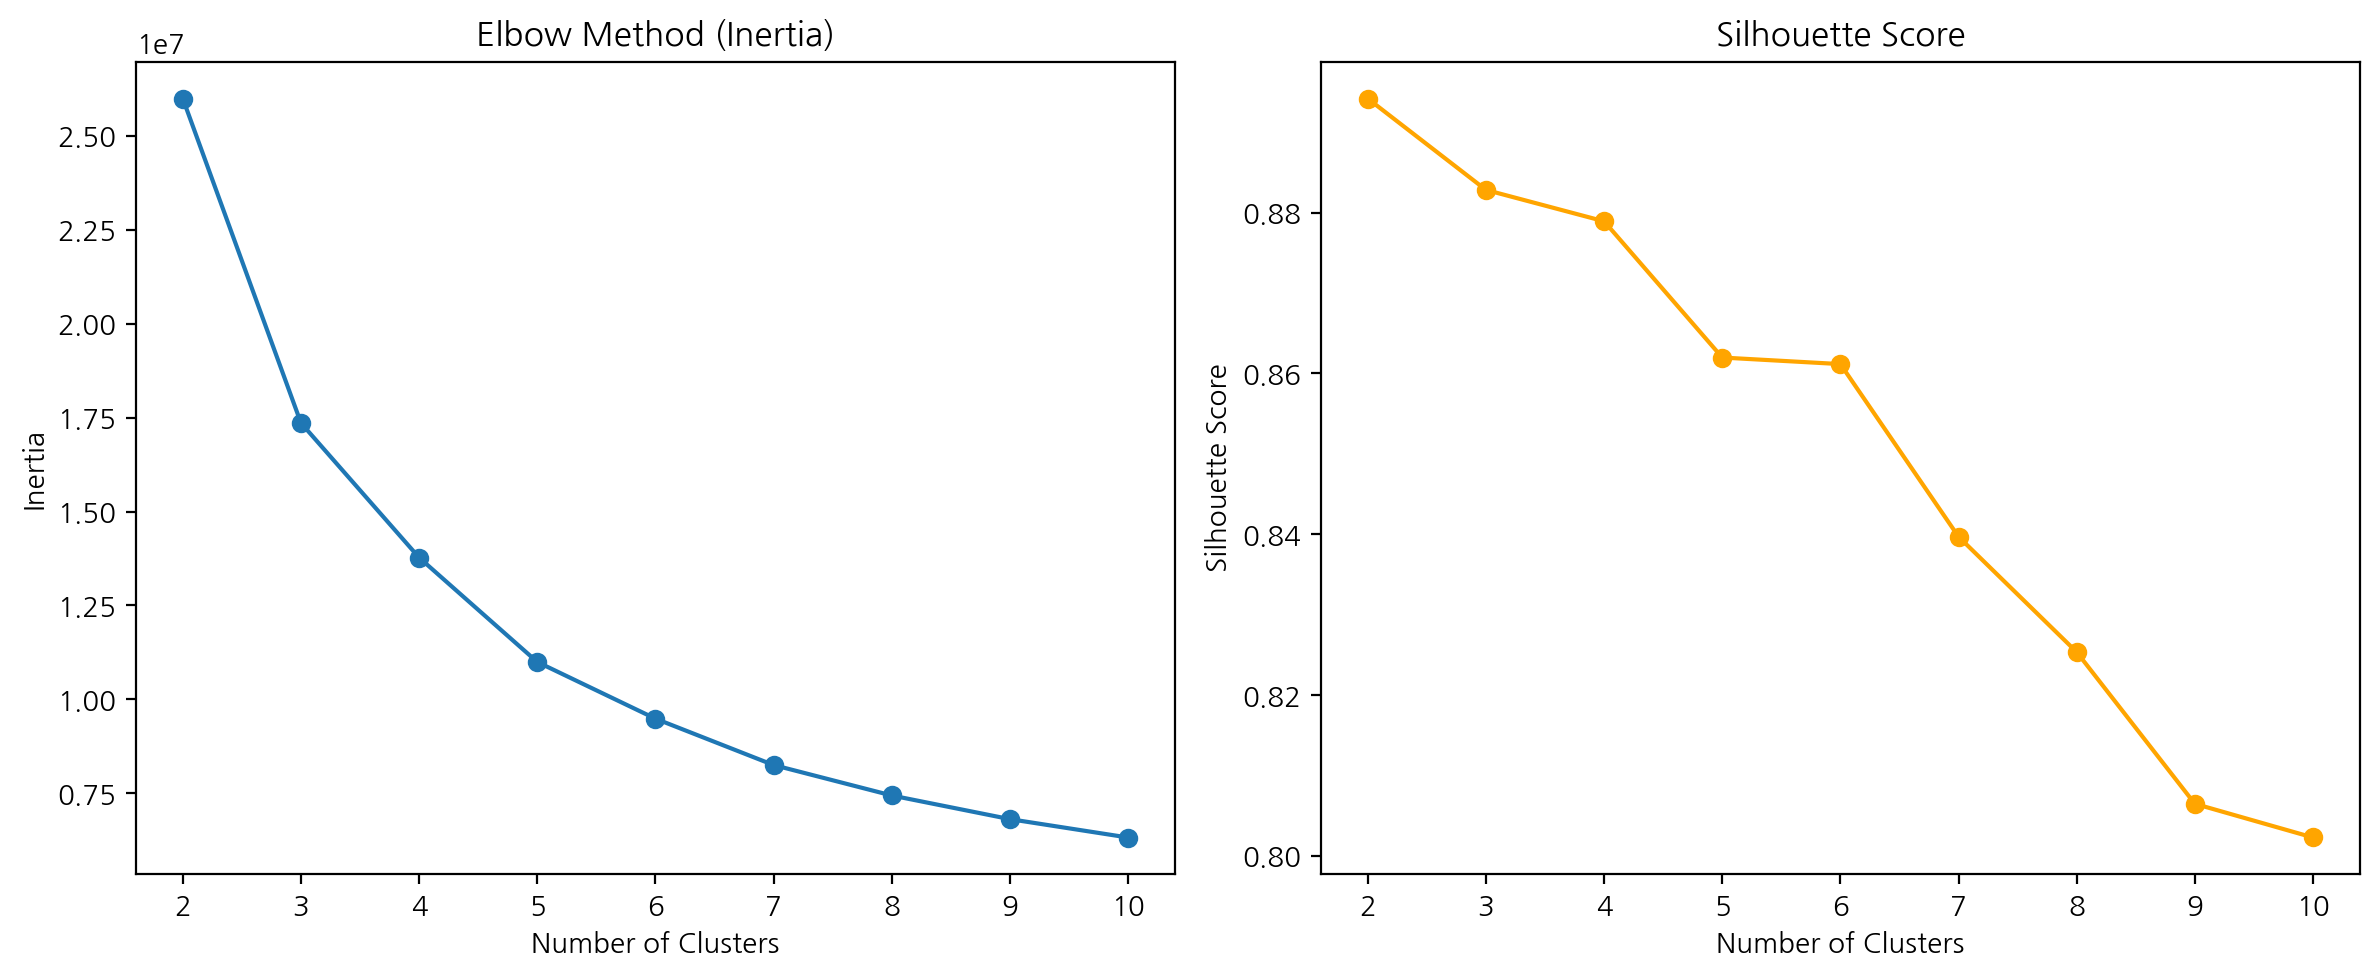

In [389]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# 1. 클러스터링 대상 컬럼 전처리
behavior_cols = ['출석주기','마지막출석후경과일','출석일수','친구요청수','친구요청받은수','초성오픈수','답장수','열람수','투표받은수','질문차단수','투표한수']

X = social_low_user[behavior_cols].dropna()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# 3. 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [390]:
# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

print(" K값별 실루엣 스코어")
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)
    
    inertias.append(inertia)
    silhouettes.append(silhouette)
    
    print(f"K = {k}: 실루엣 계수 = {silhouette:.4f}")

 K값별 실루엣 스코어
K = 2: 실루엣 계수 = 0.8942
K = 3: 실루엣 계수 = 0.8828
K = 4: 실루엣 계수 = 0.8789
K = 5: 실루엣 계수 = 0.8620
K = 6: 실루엣 계수 = 0.8612
K = 7: 실루엣 계수 = 0.8397
K = 8: 실루엣 계수 = 0.8253
K = 9: 실루엣 계수 = 0.8065
K = 10: 실루엣 계수 = 0.8023


### K=3

In [391]:
# 클러스터링 데이터 스케일링 재확인
X = social_low_user[behavior_cols].dropna()
scaler =RobustScaler()
X_scaled = scaler.fit_transform(X)

# KMeans 클러스터링 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

social_low_user.loc[X.index, '클러스터'] = cluster_labels

In [392]:
# 각 클러스터에 몇 명이 속했는지
social_low_user['클러스터'].value_counts().sort_index()

클러스터
0.0    16686
1.0     1149
2.0      170
Name: count, dtype: int64

In [393]:
cluster_df[['degree','betweenness','pagerank','closeness']].describe()

,degree,betweenness,pagerank,closeness
count,20984.000000,20984.000000,20984.000000,20984.000000
mean,13.952345,0.000216,0.000048,0.053798
std,21.000455,0.000988,0.000023,0.036004
min,1.000000,0.000000,0.000008,0.000048
25%,2.000000,0.000000,0.000032,0.000292
50%,4.000000,0.000003,0.000047,0.068198
75%,17.000000,0.000091,0.000058,0.080029
max,226.000000,0.032794,0.000273,0.105942


#### 저관여유저 인사이트 정리

- `클러스터0`(16086명):휴면 or 이탈유저군
    - 유입은 했지만 초기 활동 이후 거의 사용 X
    - 관계 형성 거의 없음, 투표도 적음
    - 리텐션 불가
    - 네트워크 중심성 해석: 중개자 거의 없음, 고립 유저, 허브 전환 가능성 희박
    - 속성 해석: 유료 컨텐츠 접근 거의 없음 -> LTV낮음
- `클러스터1`(1149명): 커뮤니티 기반 선순환 유저(소셜 중심 유저)
    - 답장, 초성오픈, 친구요청 다 많음
    - 답장 제일 많음 -> 상호작용(피드백, 커뮤니케이션) 지향함 -> 선순환 구조 가능성
    - 열람, 초성오픈 비교적 활발 -> 타인의 관심도에 대한 관심
    - 네트워크 중심성 해석: 친구는 많음, 확산의 축은 아님
    - 속성 해석: 
- `클러스터2`(170명): 참여형 유저
    - 출석,투표,열람 가장 많음 -> 투표 기능 몰입, 참여형
    - 답장 수 적음 -> 상호작용 빈약 -> 커뮤니티 리텐션 낮음
    - 네트워크 중심성 해석: 모든 지표 상위권, 허브 전환 가능성 있음, 소셜 영향력도 가질 수 있음
    - 확산 목적이면 클러스터2 유저를 타겟으로 해야함
    - 속성 해석: 다른 군집보다 남성 비중 높음,투표 활발, 답장1회 많음

In [394]:
# 행동변수별 평균 보기
social_low_user.groupby('클러스터')[behavior_cols].mean().T.round(2)

클러스터,0.0,1.0,2.0
출석주기,2.90,0.89,0.67
마지막출석후경과일,136.84,102.67,96.50
출석일수,6.35,37.87,52.61
친구요청수,3.98,24.95,30.70
친구요청받은수,3.49,22.93,26.15
초성오픈수,0.25,3.83,4.19
답장수,0.85,11.34,2.14
열람수,3.71,76.24,96.71
투표받은수,7.13,165.04,191.91
질문차단수,0.00,0.03,0.04


In [395]:
df_cluster_avg = social_low_user.groupby('클러스터')[behavior_cols].mean().T
df_cluster_avg.columns = [f'클러스터 {int(c)}' for c in df_cluster_avg.columns]

df_cluster_avg.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=2) \
    .set_caption("클러스터별 행동 변수 평균값 히트맵")


,클러스터 0,클러스터 1,클러스터 2
출석주기,2.90,0.89,0.67
마지막출석후경과일,136.84,102.67,96.50
출석일수,6.35,37.87,52.61
친구요청수,3.98,24.95,30.70
친구요청받은수,3.49,22.93,26.15
초성오픈수,0.25,3.83,4.19
답장수,0.85,11.34,2.14
열람수,3.71,76.24,96.71
투표받은수,7.13,165.04,191.91
질문차단수,0.00,0.03,0.04


In [396]:
centrality_cols = ['degree', 'closeness', 'betweenness', 'pagerank']
                  
social_low_user.groupby('클러스터')[centrality_cols].mean().T.round(6)

클러스터,0.0,1.0,2.0
degree,6.095889,35.381201,45.152941
closeness,0.046344,0.083961,0.084028
betweenness,0.000189,0.000245,0.000608
pagerank,0.000044,0.000053,0.000068


In [397]:
# 1. 중심성 지표 평균 계산
centrality_avg = social_low_user.groupby('클러스터')[centrality_cols].mean().T.round(6)

# 2. 보기 좋게 열 이름 포맷팅 (선택)
centrality_avg.columns = [f'클러스터 {int(c)}' for c in centrality_avg.columns]

# 3. 히트맵 스타일 적용
centrality_avg.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=6) \
    .set_caption("클러스터별 네트워크 중심성 지표 평균값 히트맵")

,클러스터 0,클러스터 1,클러스터 2
degree,6.095889,35.381201,45.152941
closeness,0.046344,0.083961,0.084028
betweenness,0.000189,0.000245,0.000608
pagerank,0.000044,0.000053,0.000068


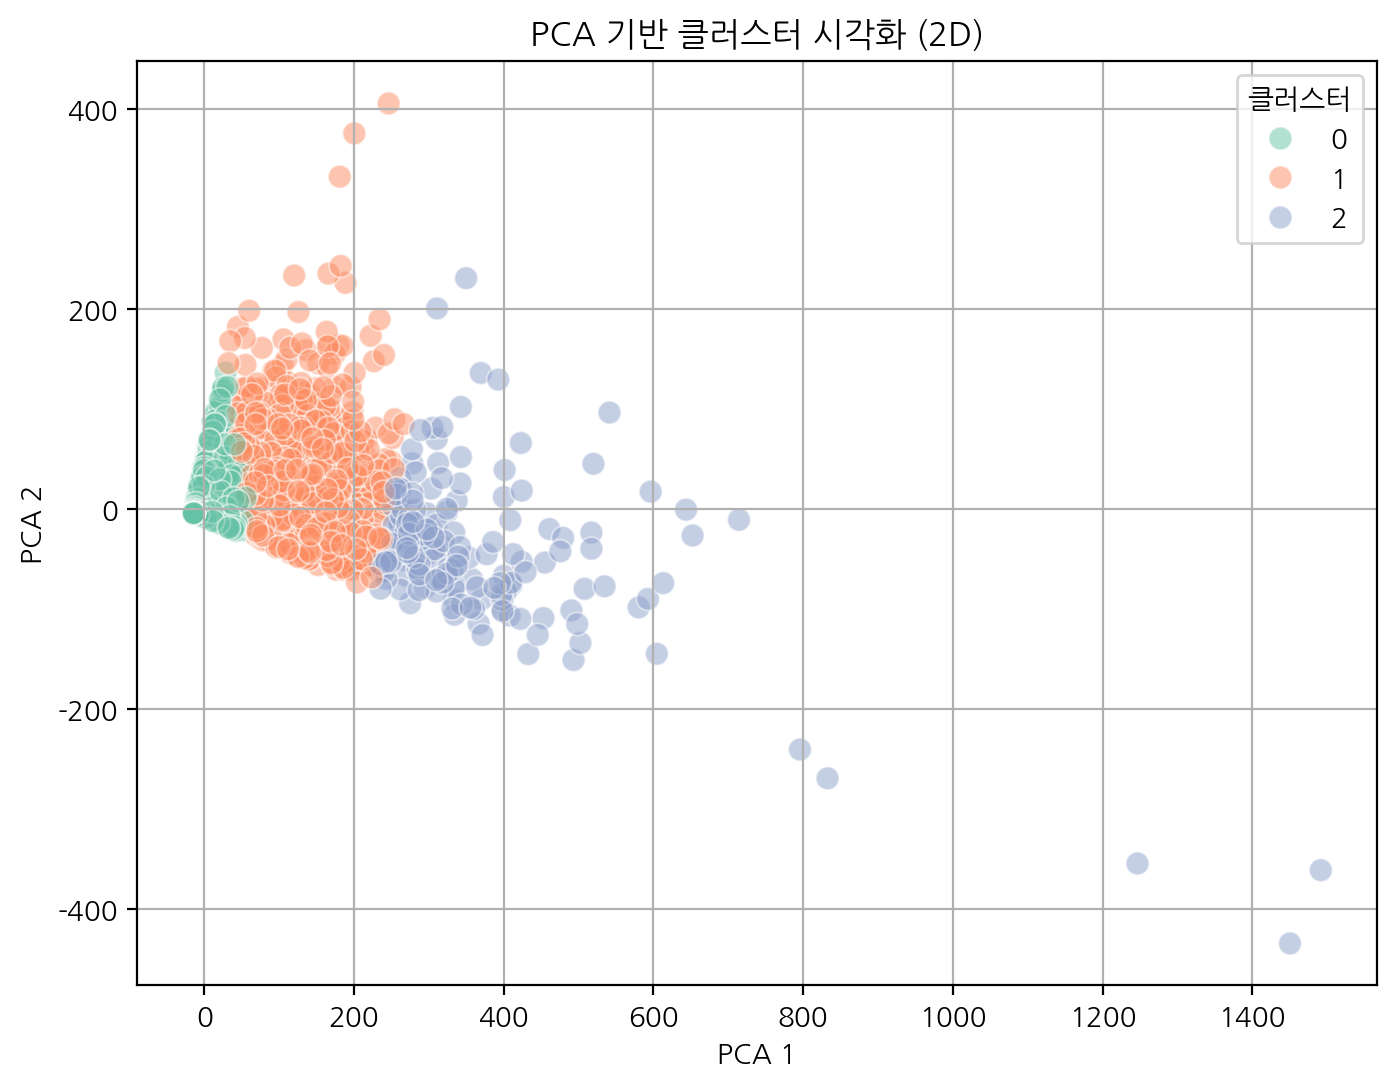

In [398]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 스케일링된 데이터와 클러스터 결과 사용
#    (X_scaled, cluster_labels는 이전에 이미 계산됨)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. 결과를 데이터프레임으로 묶기
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['클러스터'] = cluster_labels

# 3. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='클러스터', palette='Set2', s=70, alpha=0.5)
plt.title('PCA 기반 클러스터 시각화 (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='클러스터')
plt.grid(True)
plt.show()

### 핵심유저 클러스터링

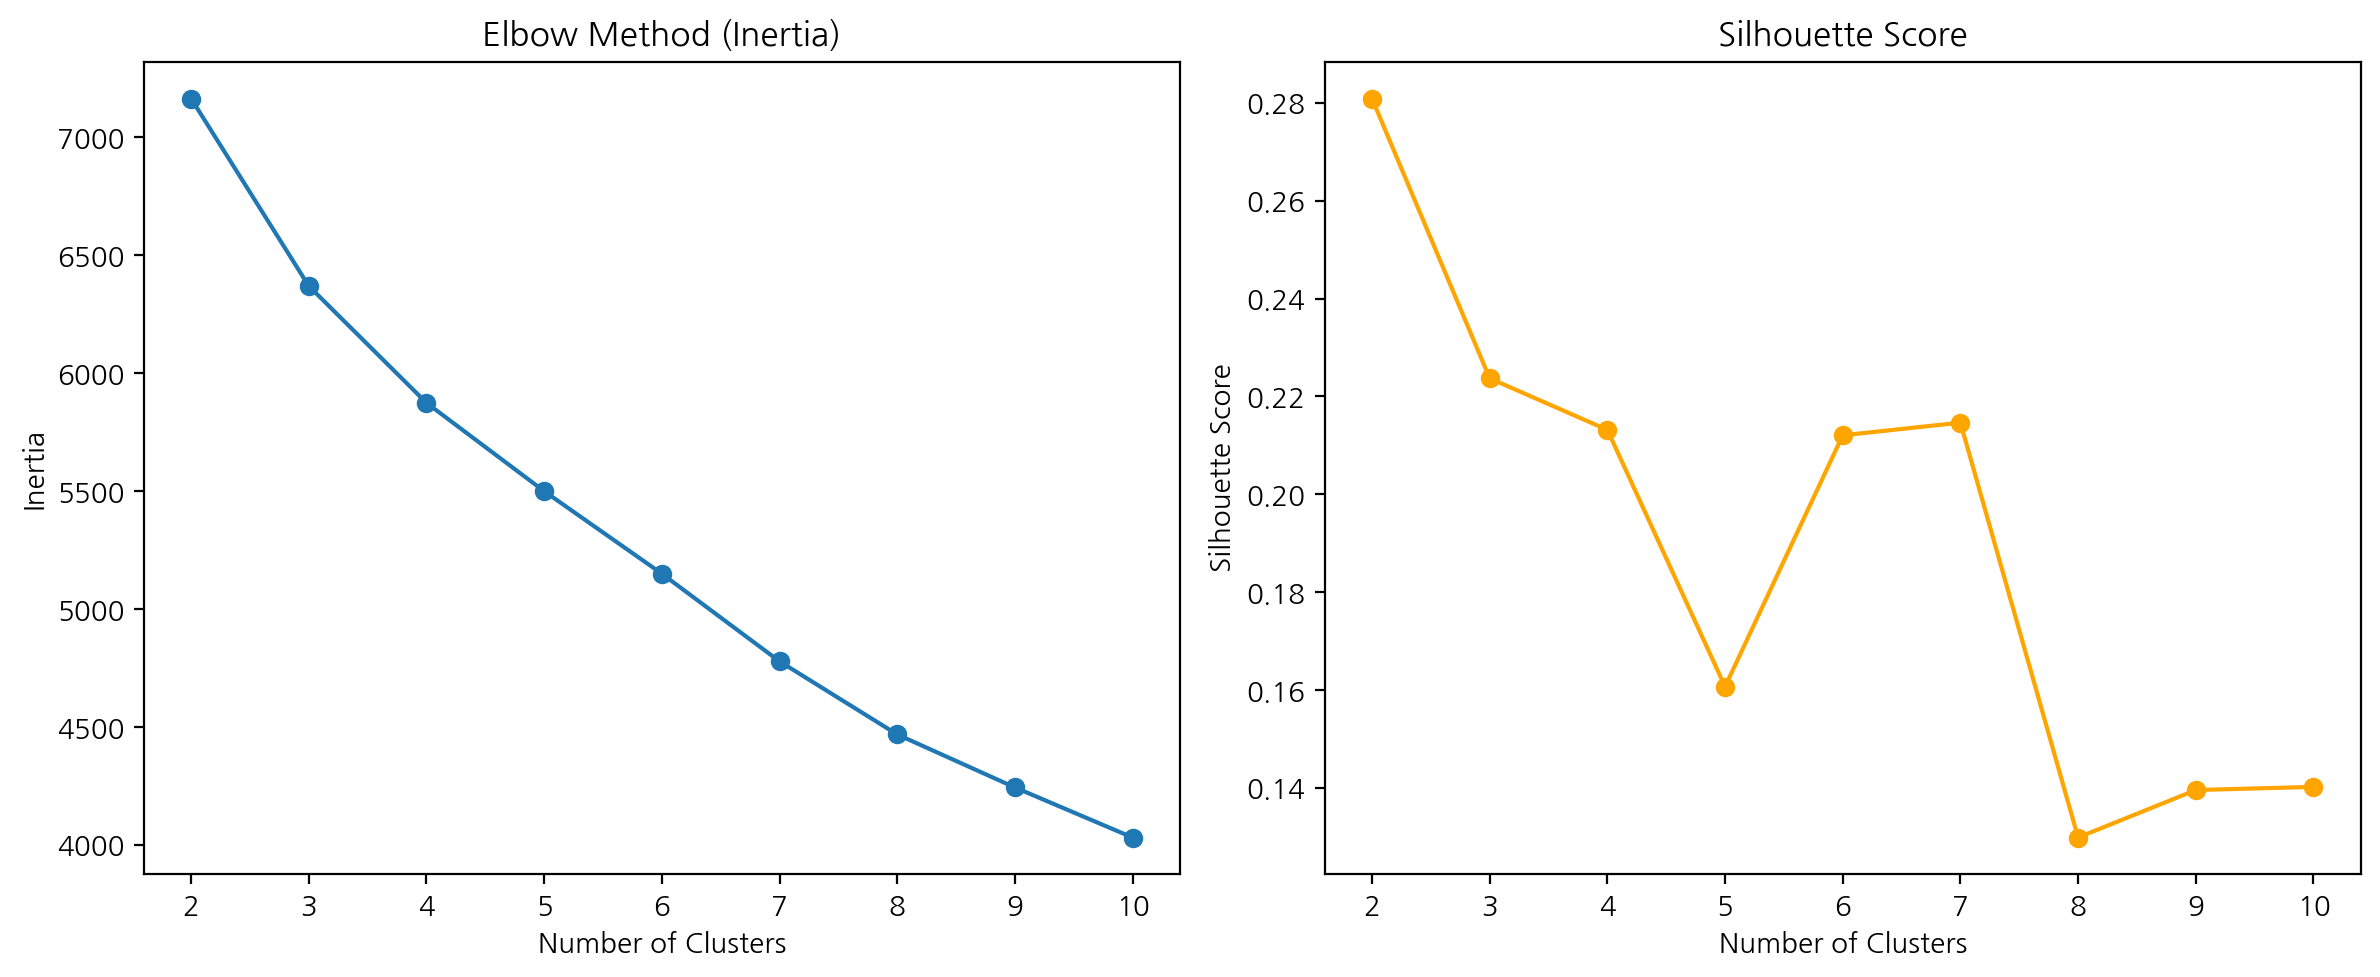

In [399]:
# 1. 클러스터링 대상 컬럼 전처리
behavior_cols = ['출석주기','마지막출석후경과일','출석일수','친구요청수','친구요청받은수','초성오픈수','답장수','열람수','투표받은수','질문차단수','투표한수']

X = social_core_user[behavior_cols].dropna()
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

# 3. 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [400]:

# 클러스터링 데이터 스케일링 재확인
X = social_core_user[behavior_cols].dropna()
scaler =RobustScaler()
X_scaled = scaler.fit_transform(X)

# KMeans 클러스터링 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

social_core_user.loc[X.index, '클러스터'] = cluster_labels

In [401]:
social_core_user['클러스터'].value_counts()

클러스터
0.0    664
2.0    284
1.0    108
Name: count, dtype: int64

In [402]:
# 행동변수별 평균 보기
social_core_user.groupby('클러스터')[behavior_cols].mean().T.round(2)

클러스터,0.0,1.0,2.0
출석주기,0.60,0.44,0.49
마지막출석후경과일,98.51,88.15,86.73
출석일수,49.90,70.05,67.18
친구요청수,26.98,30.88,34.14
친구요청받은수,30.35,41.15,42.86
초성오픈수,16.34,22.42,31.39
답장수,38.49,225.34,50.17
열람수,152.57,342.16,334.09
투표받은수,243.13,407.84,444.71
질문차단수,0.09,0.10,0.10


In [403]:
# 클러스터별 평균 계산
cluster_behavior_mean = social_core_user.groupby('클러스터')[behavior_cols].mean().T.round(2)

# 1. 열 이름을 '클러스터 0' 형식으로 문자열 처리
cluster_behavior_mean.columns = [f'클러스터 {int(c)}' for c in cluster_behavior_mean.columns]

# 2. 히트맵 + 최대값 강조 + 포맷 설정
cluster_behavior_mean.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=2) \
    .set_caption(" 클러스터별 행동 변수 평균값 히트맵")

,클러스터 0,클러스터 1,클러스터 2
출석주기,0.60,0.44,0.49
마지막출석후경과일,98.51,88.15,86.73
출석일수,49.90,70.05,67.18
친구요청수,26.98,30.88,34.14
친구요청받은수,30.35,41.15,42.86
초성오픈수,16.34,22.42,31.39
답장수,38.49,225.34,50.17
열람수,152.57,342.16,334.09
투표받은수,243.13,407.84,444.71
질문차단수,0.09,0.10,0.10


In [404]:
centrality_cols = ['degree', 'closeness', 'betweenness', 'pagerank']
                  
social_core_user.groupby('클러스터')[centrality_cols].mean().T.round(6)

클러스터,0.0,1.0,2.0
degree,48.689759,63.175926,67.024648
closeness,0.082525,0.077376,0.079067
betweenness,0.000393,0.000331,0.000509
pagerank,0.000067,0.000075,0.000081


In [405]:
# 평균 계산 (반올림 안 함!)
cluster_centrality_mean = social_core_user.groupby('클러스터')[centrality_cols].mean().T

# 열 이름 처리
cluster_centrality_mean.columns = [f'클러스터 {int(c)}' for c in cluster_centrality_mean.columns]

# 히트맵 시각화 (6자리까지 표현)
cluster_centrality_mean.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=6) \
    .set_caption("클러스터별 네트워크 중심성 지표 히트맵")

,클러스터 0,클러스터 1,클러스터 2
degree,48.689759,63.175926,67.024648
closeness,0.082525,0.077376,0.079067
betweenness,0.000393,0.000331,0.000509
pagerank,0.000067,0.000075,0.000081


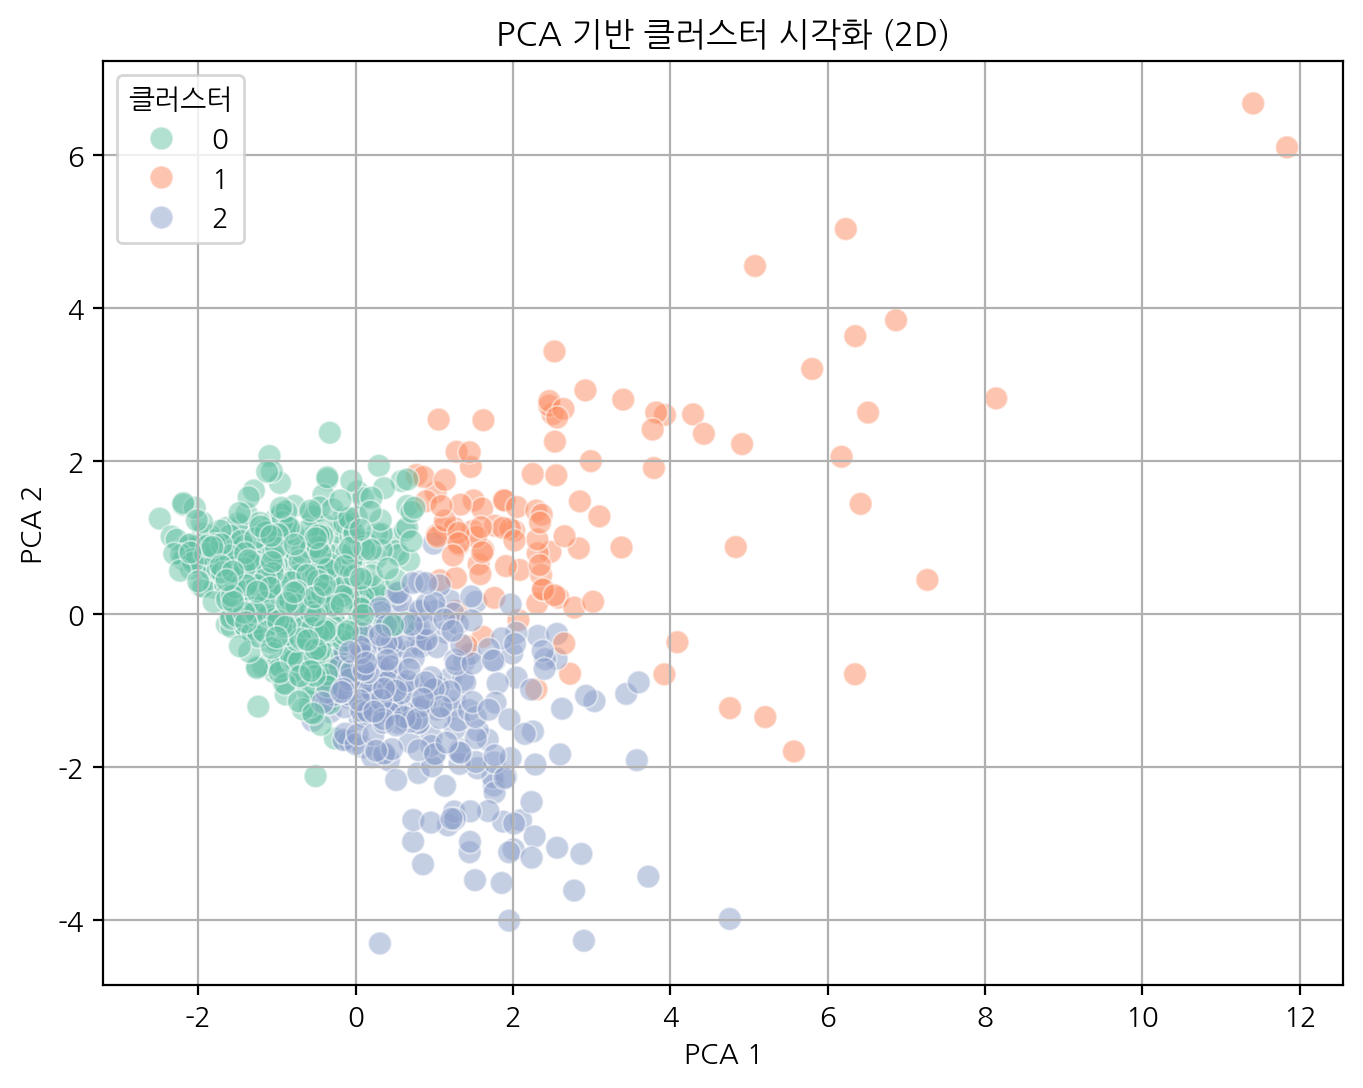

In [406]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 스케일링된 데이터와 클러스터 결과 사용
#    (X_scaled, cluster_labels는 이전에 이미 계산됨)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. 결과를 데이터프레임으로 묶기
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['클러스터'] = cluster_labels

# 3. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='클러스터', palette='Set2', s=70, alpha=0.5)
plt.title('PCA 기반 클러스터 시각화 (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='클러스터')
plt.grid(True)
plt.show()

#### 핵심유저 인사이트 정리

- `클러스터0`(664명): 저확산 충성형
    - 규칙적이나 출석일수 적음
    - 네트워크 중심성 해석: 친구수 적은편, pagerank낮음 -> 영향력(연결된 유저의 중요도) 낮음, 커뮤니티와 연결 강화 필요
    - 속성 해석: 답장 활발
- `클러스터1`(284명): 소셜 커뮤니케이터형
    - 답장 수 압도적 -> 상호작용, 피드백에 적극적 
    - 초성 오픈도 많음 -> 콘텐츠 소비 -> LTV 잠재력 높음
    - 출석 일수, 친구요청/받음 고르게 높음
    - 네트워크 중심성 해석: 네트워크 전체 관점에서 위치 분산돼 있음, 로컬 네트워크 허브로 기능할 가능성(특정 커뮤니티)
    - 속성 해석: 여성 비율 높음, 답장 매우 활발
- `클러스터2`(108명): 몰입형 참여자
    - 투표/초성오픈/열람 수치 가장 높음 -> 앱 기능 완전히 활용, 콘텐츠 소비량 최상
    - 친구요청/받음도 가장 높음
    - 답장은 낮음 -> 피드백 소극적
    - 네트워크 중심성 해석: 영향력 있는 유저들과 연결, 가장 영향력 큼, 위치도 중심에 가까움, 다른 유저들 사이 노출/전달 확률 매우 높음
    - 속성 해석: 투표 매우 활발, 콘텐츠 소비 매우 활발

### 콘텐츠소비유저 클러스터링

In [114]:
cluster_contents = cluster_df[cluster_df['유저군'] == '콘텐츠소비유저'].copy()
cluster_join = cluster_df[cluster_df['유저군'] == '참여중심유저'].copy()

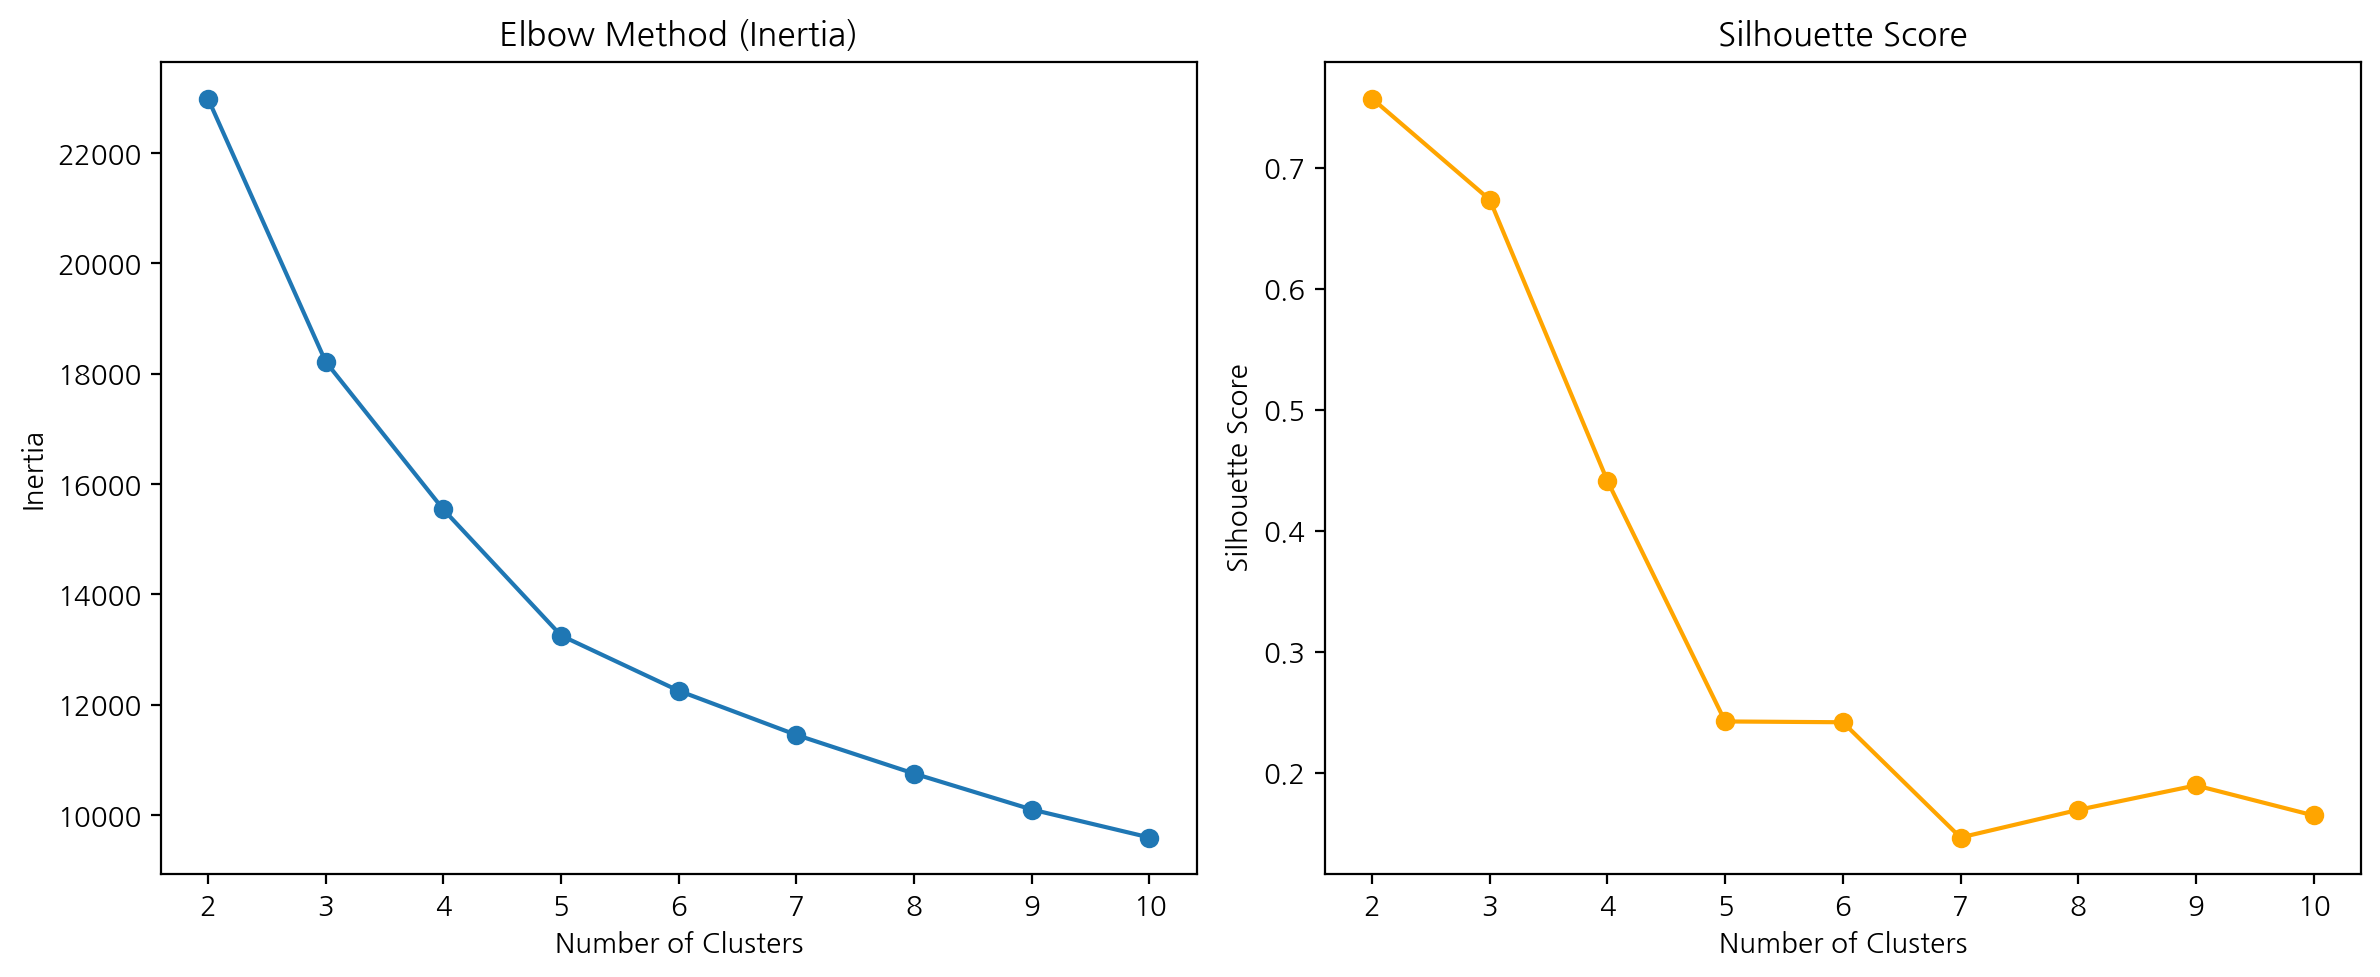

In [117]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# 1. 클러스터링 대상 컬럼 전처리
behavior_cols = ['출석주기','마지막출석후경과일','출석일수','친구요청수','친구요청받은수','초성오픈수','답장수','열람수','투표받은수','질문차단수','투표한수']

X = cluster_contents[behavior_cols].dropna()
scaler_con = RobustScaler()
X_scaled_con = scaler_con.fit_transform(X)

# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans_con = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans_con.fit_predict(X_scaled_con)
    
    inertias.append(kmeans_con.inertia_)
    silhouettes.append(silhouette_score(X_scaled_con, labels))

# 3. 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [119]:
# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

print(" K값별 실루엣 스코어")
for k in K_range:
    kmeans_con = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans_con.fit_predict(X_scaled_con)
    
    inertia = kmeans_con.inertia_
    silhouette = silhouette_score(X_scaled_con, labels)
    
    inertias.append(inertia)
    silhouettes.append(silhouette)
    
    print(f"K = {k}: 실루엣 계수 = {silhouette:.4f}")

 K값별 실루엣 스코어
K = 2: 실루엣 계수 = 0.7571
K = 3: 실루엣 계수 = 0.6735
K = 4: 실루엣 계수 = 0.4411
K = 5: 실루엣 계수 = 0.2424
K = 6: 실루엣 계수 = 0.2417
K = 7: 실루엣 계수 = 0.1464
K = 8: 실루엣 계수 = 0.1693
K = 9: 실루엣 계수 = 0.1895
K = 10: 실루엣 계수 = 0.1647


### K=3

In [120]:
from sklearn.cluster import KMeans

# 클러스터링 데이터 스케일링 재확인
X = cluster_contents[behavior_cols].dropna()
scaler_con = RobustScaler()
X_scaled_con = scaler.fit_transform(X)

# KMeans 클러스터링 (K=3)
kmeans_con = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans_con.fit_predict(X_scaled_con)

cluster_contents.loc[X.index, '클러스터'] = cluster_labels

In [121]:
# 각 클러스터에 몇 명이 속했는지
cluster_contents['클러스터'].value_counts().sort_index()

클러스터
0.0    1596
1.0       8
2.0      90
Name: count, dtype: int64

### 콘텐츠소비유저 인사이트 정리

In [122]:
# 행동변수별 평균 보기
cluster_contents.groupby('클러스터')[behavior_cols].mean().T.round(2)

클러스터,0.0,1.0,2.0
출석주기,0.84,0.38,0.80
마지막출석후경과일,98.96,90.50,104.81
출석일수,46.05,62.62,40.23
친구요청수,25.53,38.38,24.88
친구요청받은수,28.68,43.38,30.14
초성오픈수,14.77,14.50,13.22
답장수,4.15,234.25,70.07
열람수,118.42,363.38,168.03
투표받은수,233.09,532.25,254.28
질문차단수,0.06,0.00,0.06


In [123]:
df_cluster_avg = cluster_contents.groupby('클러스터')[behavior_cols].mean().T
df_cluster_avg.columns = [f'클러스터 {int(c)}' for c in df_cluster_avg.columns]

df_cluster_avg.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=2) \
    .set_caption("클러스터별 행동 변수 평균값 히트맵")

,클러스터 0,클러스터 1,클러스터 2
출석주기,0.84,0.38,0.80
마지막출석후경과일,98.96,90.50,104.81
출석일수,46.05,62.62,40.23
친구요청수,25.53,38.38,24.88
친구요청받은수,28.68,43.38,30.14
초성오픈수,14.77,14.50,13.22
답장수,4.15,234.25,70.07
열람수,118.42,363.38,168.03
투표받은수,233.09,532.25,254.28
질문차단수,0.06,0.00,0.06


In [124]:
centrality_cols = ['degree', 'closeness', 'betweenness', 'pagerank']
                  
cluster_contents.groupby('클러스터')[centrality_cols].mean().T.round(6)

클러스터,0.0,1.0,2.0
degree,43.398496,73.375000,47.400000
closeness,0.083323,0.073117,0.078954
betweenness,0.000285,0.000137,0.000378
pagerank,0.000061,0.000083,0.000062


In [125]:
# 1. 중심성 지표 평균 계산
centrality_avg = cluster_contents.groupby('클러스터')[centrality_cols].mean().T.round(6)

# 2. 보기 좋게 열 이름 포맷팅 (선택)
centrality_avg.columns = [f'클러스터 {int(c)}' for c in centrality_avg.columns]

# 3. 히트맵 스타일 적용
centrality_avg.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=6) \
    .set_caption("클러스터별 네트워크 중심성 지표 평균값 히트맵")

,클러스터 0,클러스터 1,클러스터 2
degree,43.398496,73.375000,47.400000
closeness,0.083323,0.073117,0.078954
betweenness,0.000285,0.000137,0.000378
pagerank,0.000061,0.000083,0.000062


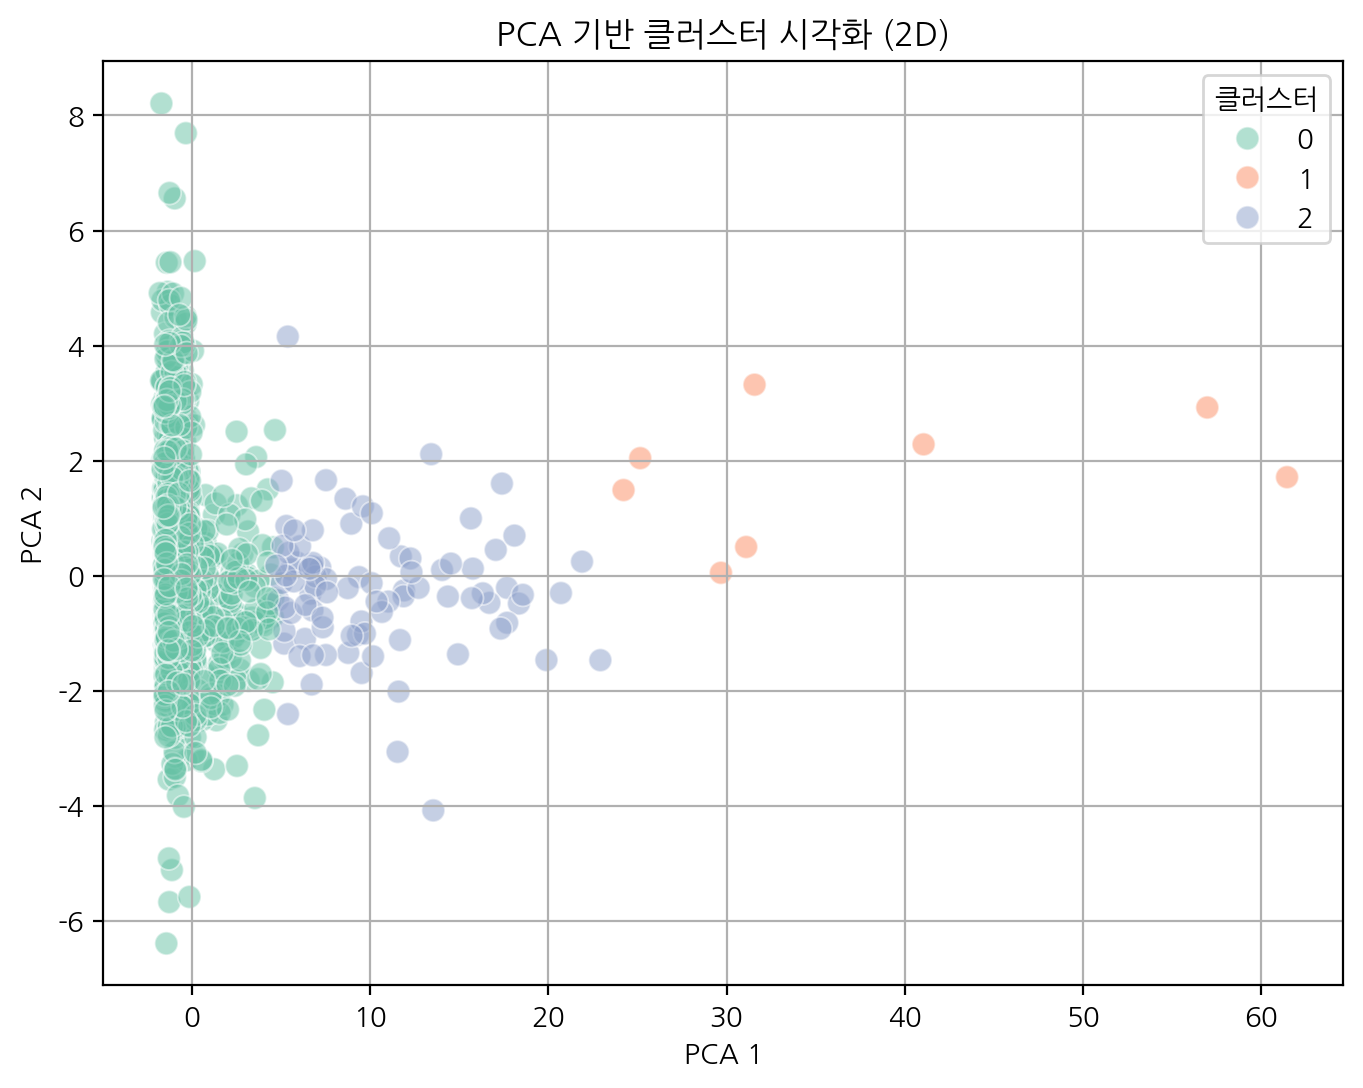

In [126]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 스케일링된 데이터와 클러스터 결과 사용
#    (X_scaled, cluster_labels는 이전에 이미 계산됨)
pca_con = PCA(n_components=2)
X_pca_con = pca_con.fit_transform(X_scaled_con)

# 2. 결과를 데이터프레임으로 묶기
pca_con_df = pd.DataFrame(X_pca_con, columns=['PCA1', 'PCA2'])
pca_con_df['클러스터'] = cluster_labels

# 3. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_con_df, x='PCA1', y='PCA2', hue='클러스터', palette='Set2', s=70, alpha=0.5)
plt.title('PCA 기반 클러스터 시각화 (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='클러스터')
plt.grid(True)
plt.show()

### 참여중심유저 클러스터링

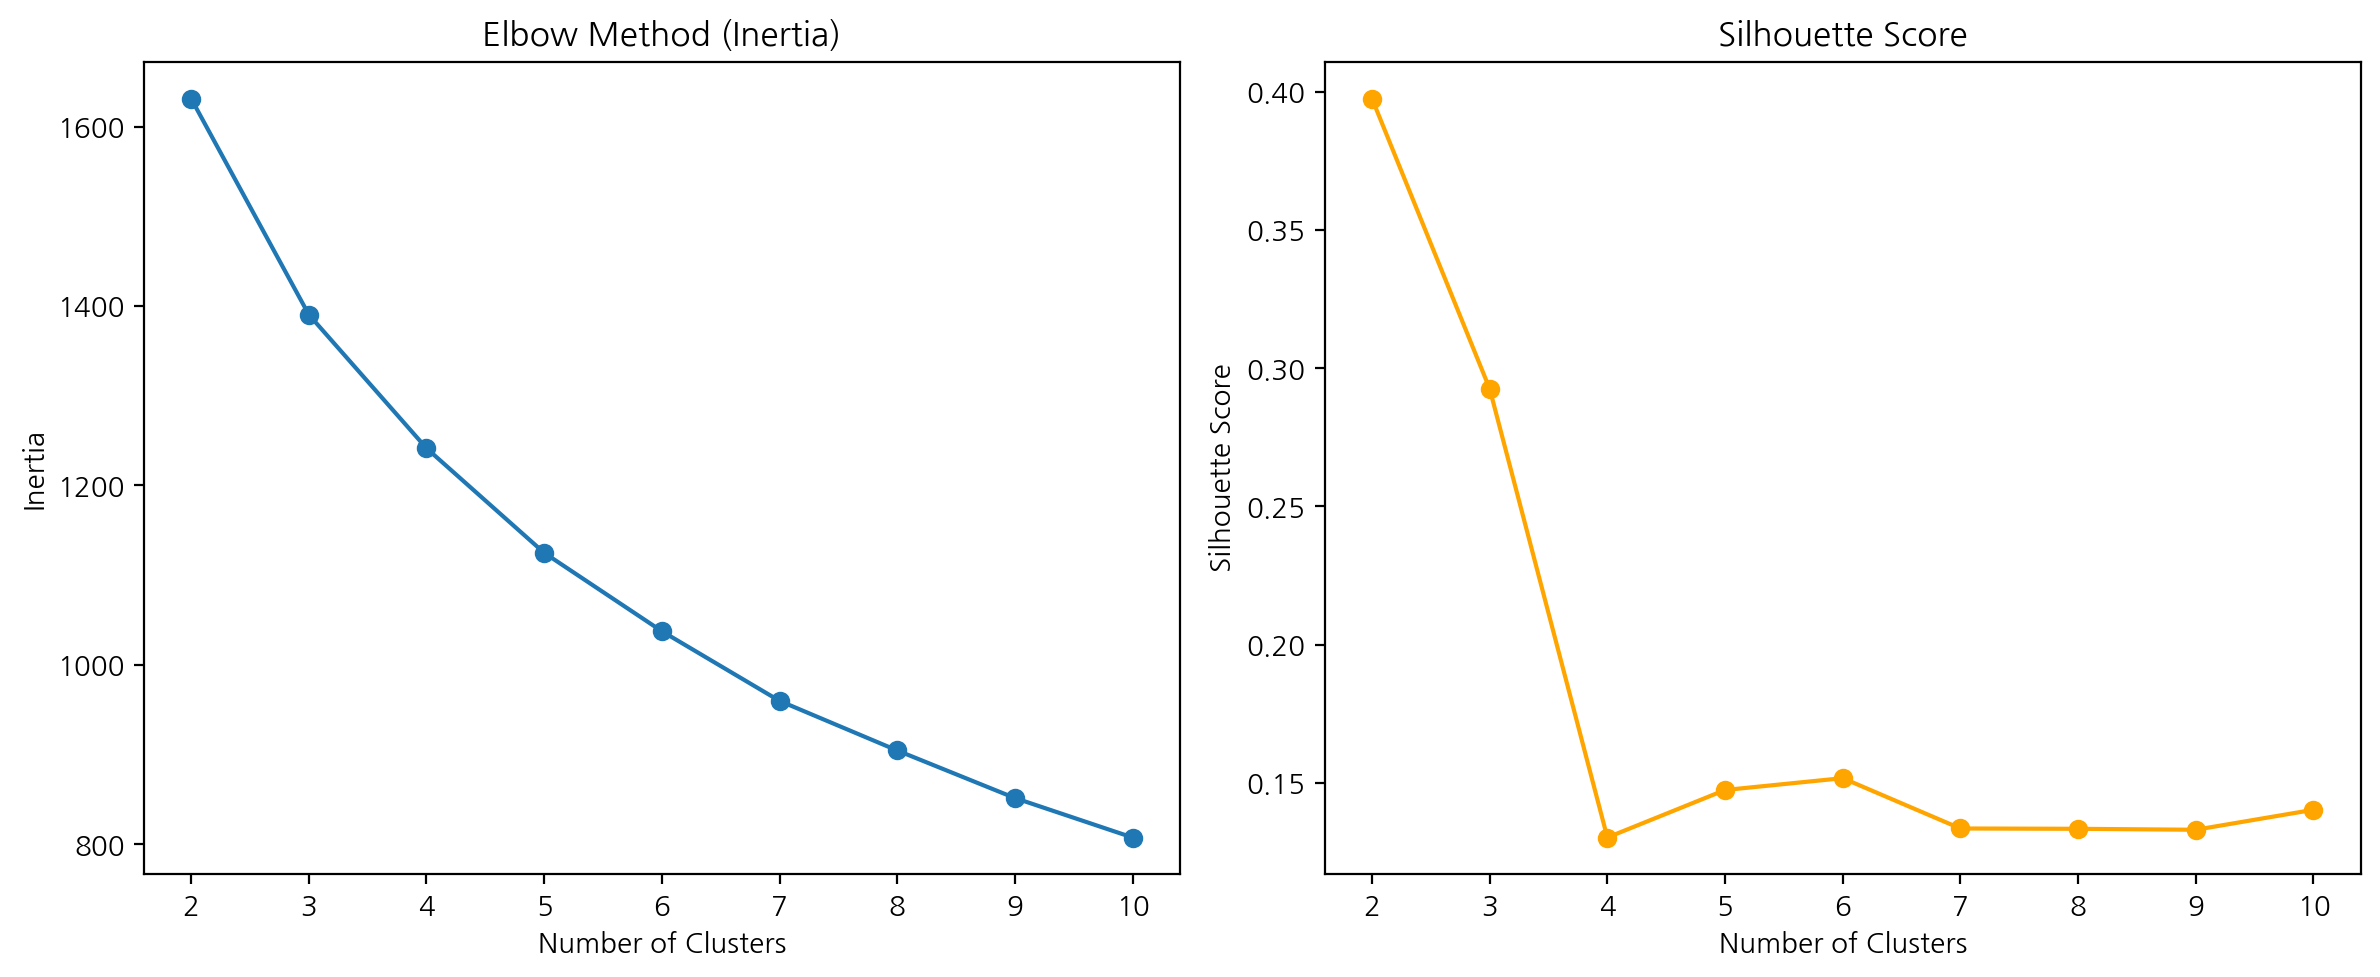

In [129]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt

# 1. 클러스터링 대상 컬럼 전처리
behavior_cols = ['출석주기','마지막출석후경과일','출석일수','친구요청수','친구요청받은수','초성오픈수','답장수','열람수','투표받은수','질문차단수','투표한수']

X = cluster_join[behavior_cols].dropna()
scaler_join = RobustScaler()
X_scaled_join = scaler.fit_transform(X)

# 2. K별 inertia & silhouette 계산
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=3, n_init=10)
    labels = kmeans.fit_predict(X_scaled_join)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled_join, labels))

# 3. 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method (Inertia)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [130]:
from sklearn.cluster import KMeans

# 클러스터링 데이터 스케일링 재확인
X = cluster_join[behavior_cols].dropna()
scaler_join = RobustScaler()
X_scaled_join = scaler.fit_transform(X)

# KMeans 클러스터링 (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled_join)

cluster_join.loc[X.index, '클러스터'] = cluster_labels

In [131]:
cluster_join['클러스터'].value_counts()

클러스터
1.0    197
0.0     32
Name: count, dtype: int64

In [132]:
# 행동변수별 평균 보기
cluster_join.groupby('클러스터')[behavior_cols].mean().T.round(2)

클러스터,0.0,1.0
출석주기,0.56,0.57
마지막출석후경과일,88.09,100.74
출석일수,69.56,46.88
친구요청수,39.06,28.74
친구요청받은수,45.69,22.04
초성오픈수,5.00,4.56
답장수,156.38,40.48
열람수,335.22,120.48
투표받은수,446.78,174.73
질문차단수,0.69,0.04


In [133]:
# 클러스터별 평균 계산
cluster_behavior_mean = cluster_join.groupby('클러스터')[behavior_cols].mean().T.round(2)

# 1. 열 이름을 '클러스터 0' 형식으로 문자열 처리
cluster_behavior_mean.columns = [f'클러스터 {int(c)}' for c in cluster_behavior_mean.columns]

# 2. 히트맵 + 최대값 강조 + 포맷 설정
cluster_behavior_mean.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=2) \
    .set_caption(" 클러스터별 행동 변수 평균값 히트맵")

,클러스터 0,클러스터 1
출석주기,0.56,0.57
마지막출석후경과일,88.09,100.74
출석일수,69.56,46.88
친구요청수,39.06,28.74
친구요청받은수,45.69,22.04
초성오픈수,5.00,4.56
답장수,156.38,40.48
열람수,335.22,120.48
투표받은수,446.78,174.73
질문차단수,0.69,0.04


In [134]:
centrality_cols = ['degree', 'closeness', 'betweenness', 'pagerank']
                  
cluster_join.groupby('클러스터')[centrality_cols].mean().T.round(6)

클러스터,0.0,1.0
degree,69.500000,41.634518
closeness,0.079802,0.081323
betweenness,0.000625,0.000261
pagerank,0.000087,0.000058


In [135]:
# 평균 계산 (반올림 안 함!)
cluster_centrality_mean = cluster_join.groupby('클러스터')[centrality_cols].mean().T

# 열 이름 처리
cluster_centrality_mean.columns = [f'클러스터 {int(c)}' for c in cluster_centrality_mean.columns]

# 히트맵 시각화 (6자리까지 표현)
cluster_centrality_mean.style \
    .background_gradient(cmap='YlGnBu', axis=1) \
    .format(precision=6) \
    .set_caption("클러스터별 네트워크 중심성 지표 히트맵")

,클러스터 0,클러스터 1
degree,69.500000,41.634518
closeness,0.079802,0.081323
betweenness,0.000625,0.000261
pagerank,0.000087,0.000058


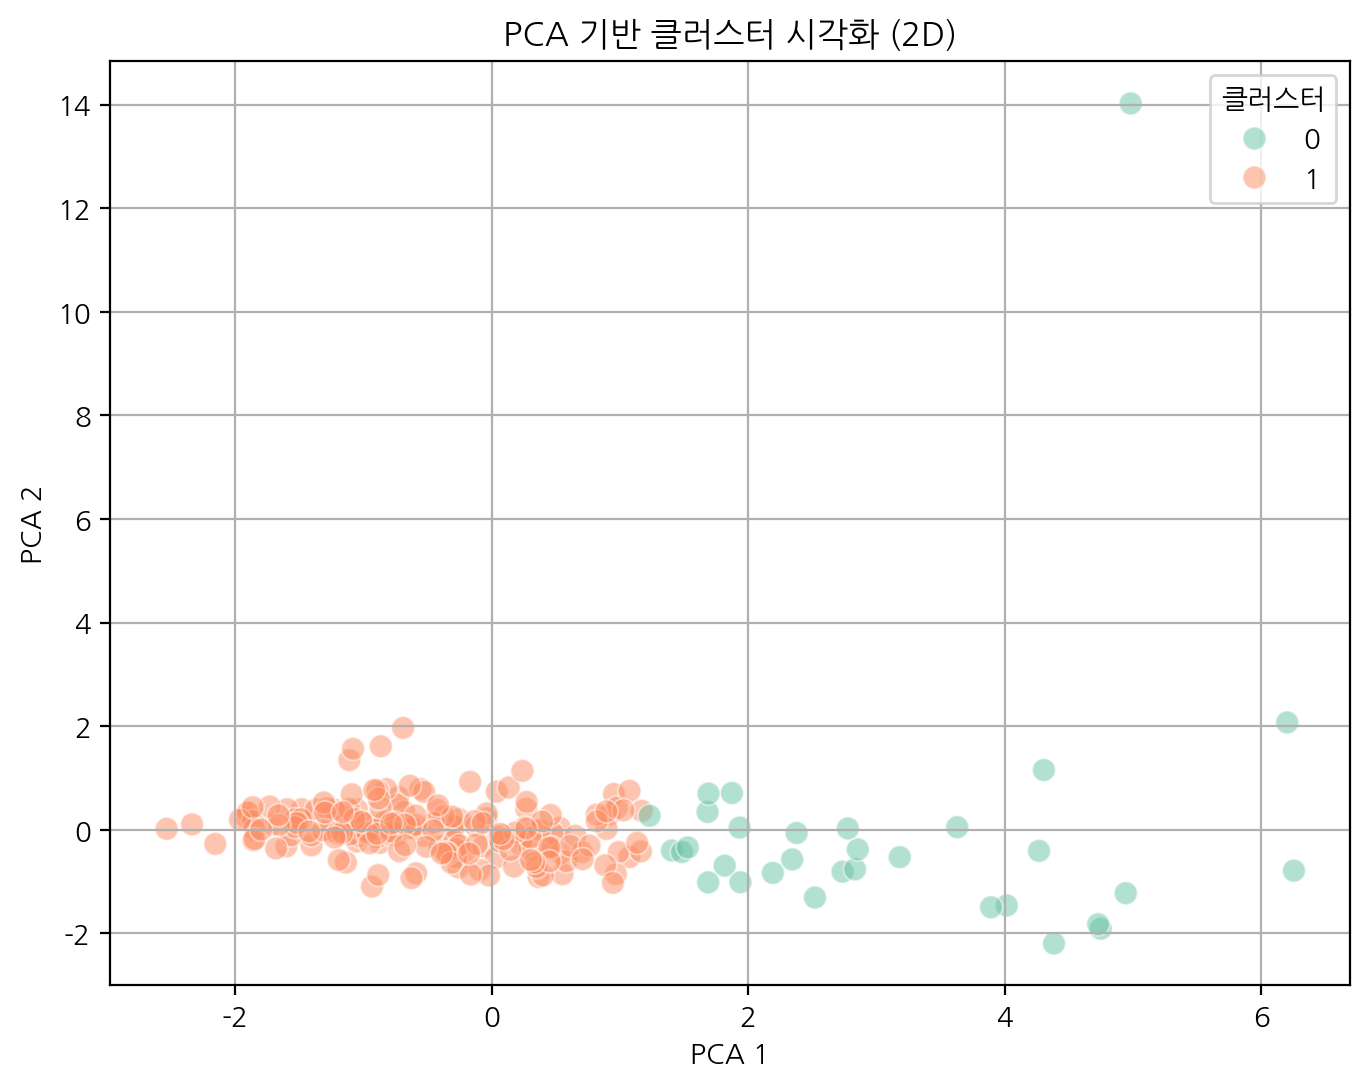

In [136]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 스케일링된 데이터와 클러스터 결과 사용
#    (X_scaled, cluster_labels는 이전에 이미 계산됨)
pca_join = PCA(n_components=2)
X_pca_join = pca_join.fit_transform(X_scaled_join)

# 2. 결과를 데이터프레임으로 묶기
pca_join_df = pd.DataFrame(X_pca_join, columns=['PCA1', 'PCA2'])
pca_join_df['클러스터'] = cluster_labels

# 3. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_join_df, x='PCA1', y='PCA2', hue='클러스터', palette='Set2', s=70, alpha=0.5)
plt.title('PCA 기반 클러스터 시각화 (2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='클러스터')
plt.grid(True)
plt.show()

# 모델링

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    learning_curve
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import xgboost as xgb


In [ ]:
# ✅ 한글 폰트 설정 (시스템에 맞게 변경)
# Windows: Malgun Gothic, Mac: AppleGothic, Linux: NanumGothic 등
plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 'AppleGothic', 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 깨짐 방지

# 데이터 불러오기

In [ ]:
merge = pd.read_csv('merged_final.csv')

In [ ]:
user = pd.read_csv('centrality.csv')

In [ ]:
merge[merge['투표한수']>0]

,user_id,created_at_attendance,출석주기,마지막출석후경과일,출석일수,친구요청수,친구요청받은수,친구요청거절수,친구요청수락수,친구요청펜딩수,...,gender,초성오픈수,답장수,답장까지소요시간(분),열람수,투표받은수,질문차단수,답장받기까지소요시간(분),투표한수,참여한질문수
47,838466,2023-04-19,1,121,40,1.0,52.0,0.0,1.0,0.0,...,F,11.0,0.0,0.000000,19.0,342.0,0.0,110.300000,129.0,113.0
88,838023,2023-04-19,2,90,37,0.0,37.0,0.0,0.0,0.0,...,F,2.0,0.0,0.000000,0.0,262.0,0.0,0.000000,22.0,20.0
107,839357,2023-04-20,1,106,47,12.0,51.0,0.0,10.0,2.0,...,M,6.0,0.0,0.000000,15.0,173.0,0.0,7868.316667,212.0,161.0
174,838642,2023-04-20,2,128,20,1.0,56.0,0.0,1.0,0.0,...,F,1.0,1.0,5.033333,10.0,40.0,0.0,0.000000,10.0,10.0
226,840512,2023-04-21,1,81,52,17.0,60.0,1.0,14.0,2.0,...,M,11.0,17.0,7.465686,80.0,309.0,1.0,1442.666667,141.0,129.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21771,1577436,2023-06-29,2,88,7,6.0,0.0,0.0,2.0,4.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,0.000000,6.0,6.0
21772,1577437,2023-06-29,10,38,7,30.0,1.0,1.0,8.0,21.0,...,F,0.0,0.0,0.000000,6.0,6.0,0.0,0.000000,131.0,130.0
21773,1577440,2023-06-29,2,15,31,17.0,0.0,0.0,7.0,10.0,...,M,4.0,0.0,0.000000,15.0,15.0,0.0,0.000000,23.0,23.0
21774,1578095,2023-07-11,12,1,8,32.0,0.0,0.0,10.0,22.0,...,F,0.0,0.0,NaN,0.0,0.0,0.0,0.000000,27.0,27.0


In [ ]:
merge['질문참여여부'] = merge['투표한수'].apply(lambda x: 1 if pd.notnull(x) and x > 0 else 0)

In [ ]:
merge_df = merge.copy()

In [ ]:
merge_df = user.merge(merge_df, on='user_id', how='left')

In [ ]:
merge_df = merge_df[['출석일수', '친구요청수', '친구요청받은수', '친구요청거절수','친구요청수락수','친구요청펜딩수', '친구요청받은후거절한수', '친구요청받은후수락한수', '질문참여여부', '답장수']]
merge_df.drop(columns = ['출석일수'], inplace=True)
merge_df.drop(columns = ['답장수'], inplace=True)

In [ ]:
merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20984 entries, 0 to 20983
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   친구요청수        20984 non-null  float64
 1   친구요청받은수      20984 non-null  float64
 2   친구요청거절수      20984 non-null  float64
 3   친구요청수락수      20984 non-null  float64
 4   친구요청펜딩수      20984 non-null  float64
 5   친구요청받은후거절한수  20984 non-null  float64
 6   친구요청받은후수락한수  20984 non-null  float64
 7   질문참여여부       20984 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1.3 MB


In [ ]:
# 데이터 불러오기
df = merge_df.copy()

# 로그 변환 가능한 열만 선택 (0보다 큰 수치형 컬럼)
numeric_cols = df.select_dtypes(include=[np.number]).columns
loggable_cols = [col for col in numeric_cols if (df[col] > 0).all()]

# 로그 변환 적용 (log1p 사용 시 0도 처리 가능)
model_log = df.copy()
model_log[loggable_cols] = np.log(model_log[loggable_cols])

# 결과 확인
print("로그 변환된 컬럼:", loggable_cols)
print(model_log.head())

로그 변환된 컬럼: []
   친구요청수  친구요청받은수  친구요청거절수  친구요청수락수  친구요청펜딩수  친구요청받은후거절한수  친구요청받은후수락한수  질문참여여부
0    3.0      1.0      0.0      3.0      0.0          0.0          0.0       0
1    1.0      4.0      0.0      1.0      0.0          1.0          3.0       0
2    1.0      6.0      0.0      1.0      0.0          2.0          4.0       0
3    1.0     10.0      0.0      1.0      0.0          0.0          7.0       0
4    2.0      6.0      0.0      2.0      0.0          0.0          6.0       0


In [ ]:
model_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20984 entries, 0 to 20983
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   친구요청수        20984 non-null  float64
 1   친구요청받은수      20984 non-null  float64
 2   친구요청거절수      20984 non-null  float64
 3   친구요청수락수      20984 non-null  float64
 4   친구요청펜딩수      20984 non-null  float64
 5   친구요청받은후거절한수  20984 non-null  float64
 6   친구요청받은후수락한수  20984 non-null  float64
 7   질문참여여부       20984 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 1.3 MB


# 로지스틱 회귀 모델

In [ ]:
# 데이터 불러오기
df = model_log.copy()

In [ ]:
# 범주형 변수 라벨 인코딩
label_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# 타겟 / 피처 분리
X = df.drop(columns=['질문참여여부'])
y = df['질문참여여부']

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습 / 검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 로지스틱 회귀 모델 정의 및 학습
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# 검증 데이터로 예측
y_pred = log_model.predict(X_val)

# 성능 평가
print("✅ [검증 데이터 평가 - Logistic Regression]")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

✅ [검증 데이터 평가 - Logistic Regression]
Confusion Matrix:
[[3120  112]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



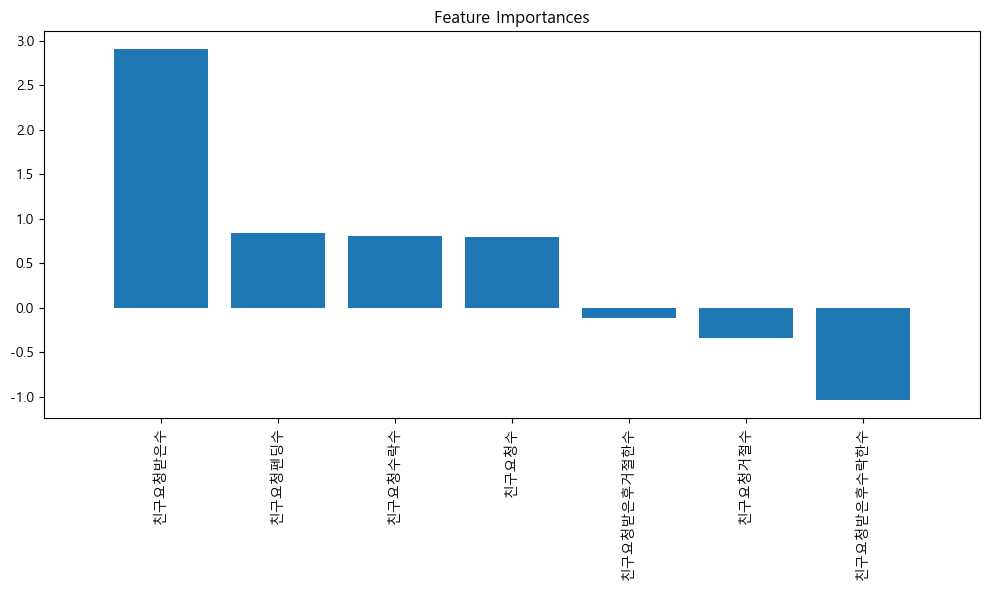

In [ ]:
# importance 시각화
importances = log_model.coef_[0]
feature_names = X.columns
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.tight_layout()
plt.show()

## importance 범위에 따른 모델들 비교

### importance 0.1 이상

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.1 이상 피처만 선택
low_importance_mask = feature_importance >= 0.1
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.1 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.1 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))



📉 중요도 0.1 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청거절수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후거절한수', '친구요청받은후수락한수']

✅ [중요도 0.1 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3120  112]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



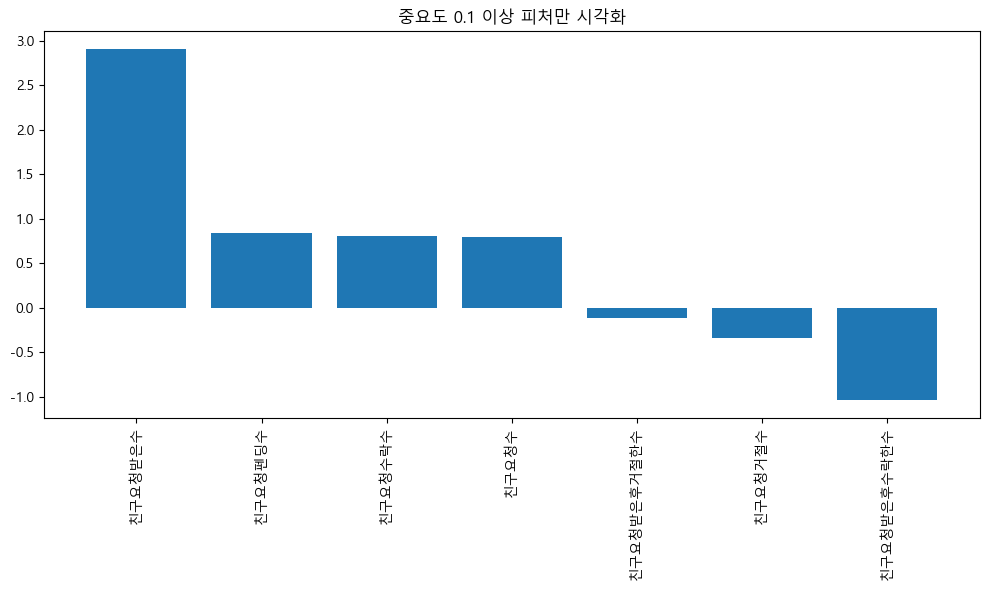

In [ ]:
# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.1 필터링
low_idx = np.where(np.abs(importances) >= 0.1)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.1 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.2 이상

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.2 이상 피처만 선택
low_importance_mask = feature_importance >= 0.2
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.2 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.2 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))


📉 중요도 0.2 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청거절수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.2 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3119  113]
 [ 211  754]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



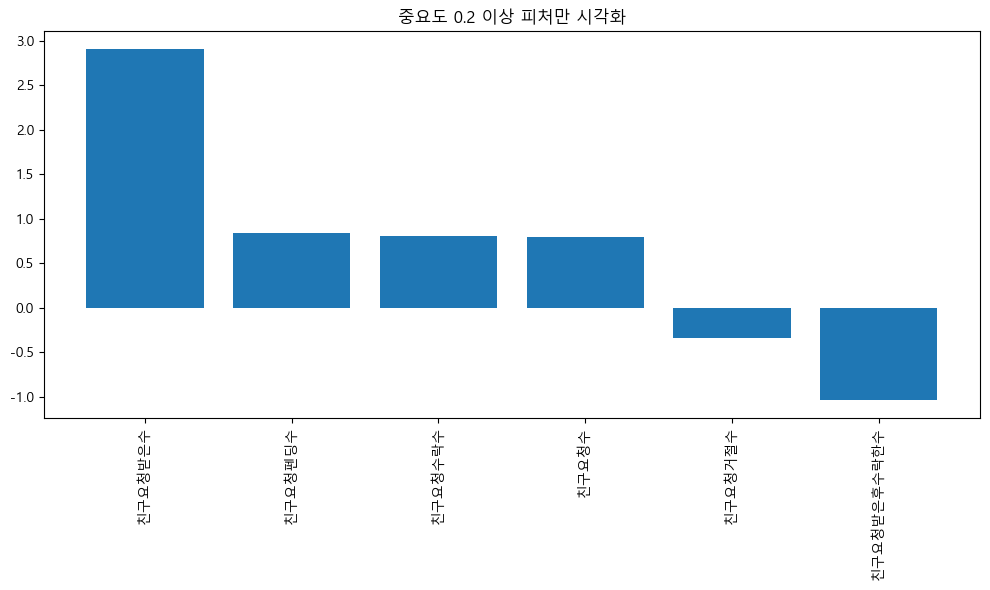

In [ ]:
# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.2 필터링
low_idx = np.where(np.abs(importances) >= 0.2)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.2 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.3 이상


📉 중요도 0.3 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청거절수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.3 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3119  113]
 [ 211  754]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



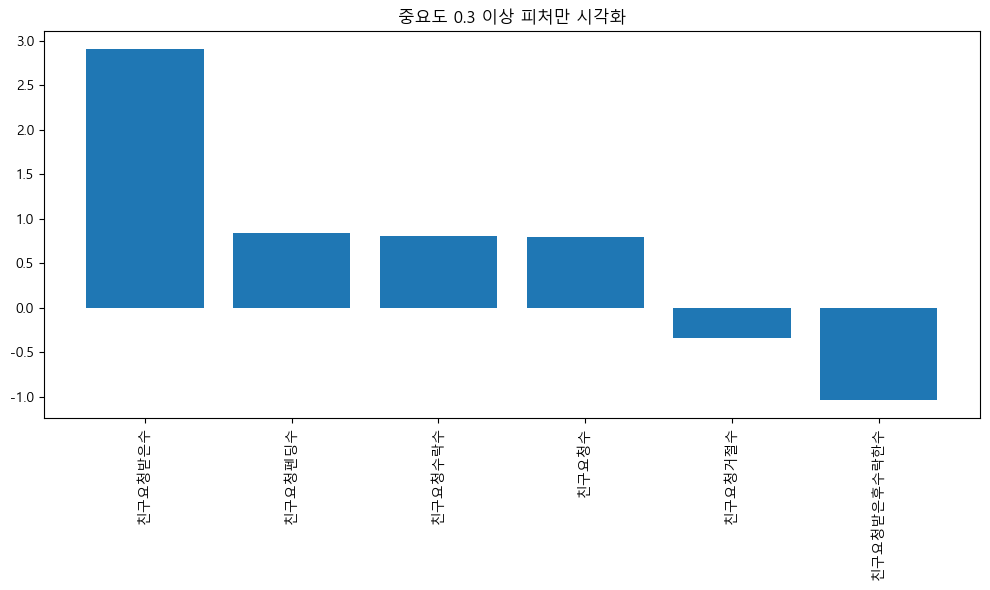

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.3 이상 피처만 선택
low_importance_mask = feature_importance >= 0.3
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.3 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.3 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.3 필터링
low_idx = np.where(np.abs(importances) >= 0.3)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.3 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.4 이상


📉 중요도 0.4 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.4 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3117  115]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



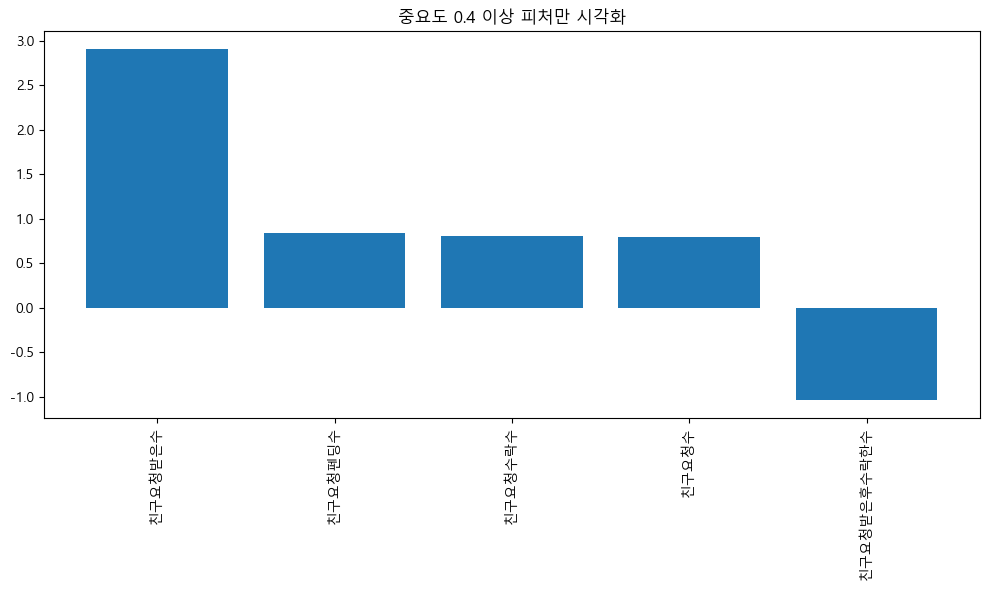

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.4 이상 피처만 선택
low_importance_mask = feature_importance >= 0.4
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.4 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.4 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.4 필터링
low_idx = np.where(np.abs(importances) >= 0.4)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.4 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.5 이상


📉 중요도 0.5 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.5 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3117  115]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



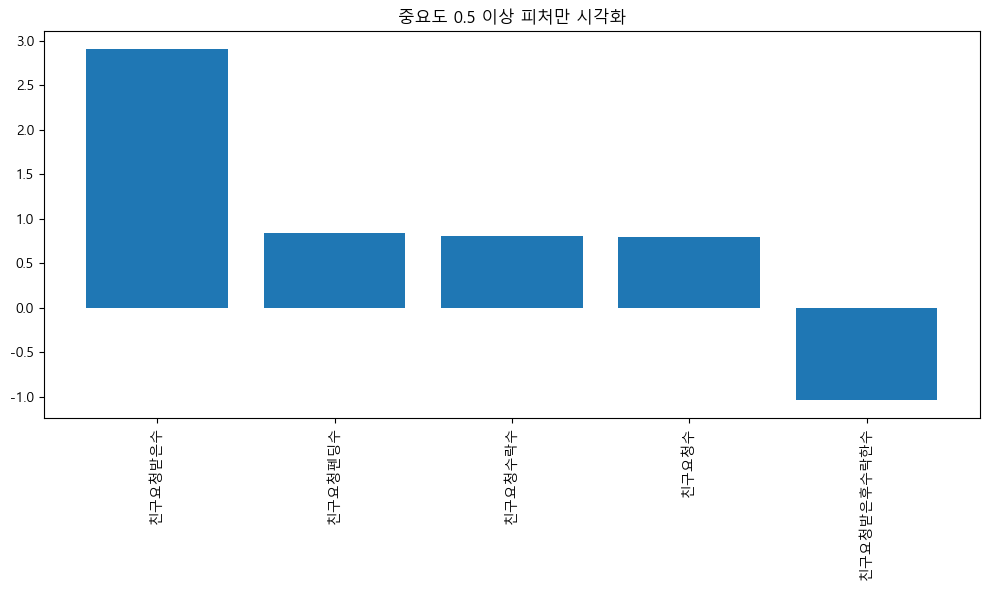

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.5 이상 피처만 선택
low_importance_mask = feature_importance >= 0.5
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.5 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.5 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.5 필터링
low_idx = np.where(np.abs(importances) >= 0.5)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.5 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.6


📉 중요도 0.6 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.6 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3117  115]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



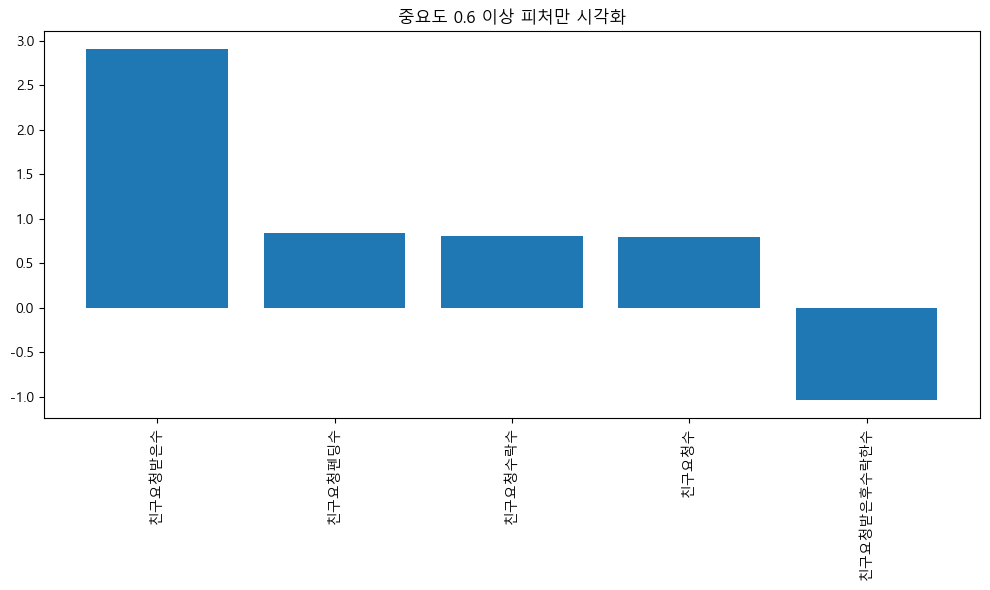

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.6 이상 피처만 선택
low_importance_mask = feature_importance >= 0.6
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.6 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.6 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.6 필터링
low_idx = np.where(np.abs(importances) >= 0.6)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.6 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.7 이상


📉 중요도 0.7 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.7 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3117  115]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



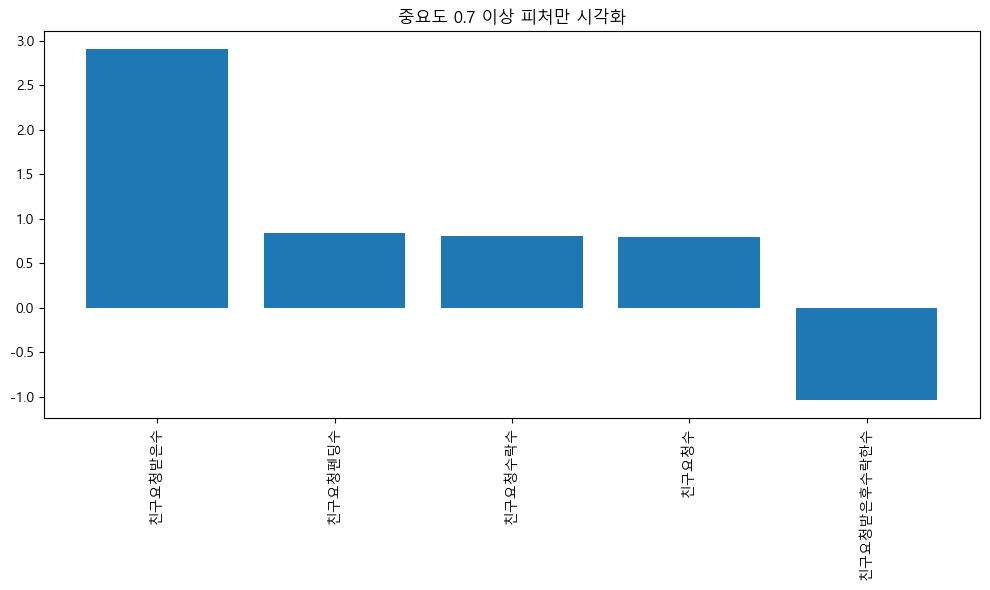

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.7 이상 피처만 선택
low_importance_mask = feature_importance >= 0.7
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.7 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.7 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.7 필터링
low_idx = np.where(np.abs(importances) >= 0.7)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.7 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.8 이상


📉 중요도 0.8 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [중요도 0.8 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3117  115]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197



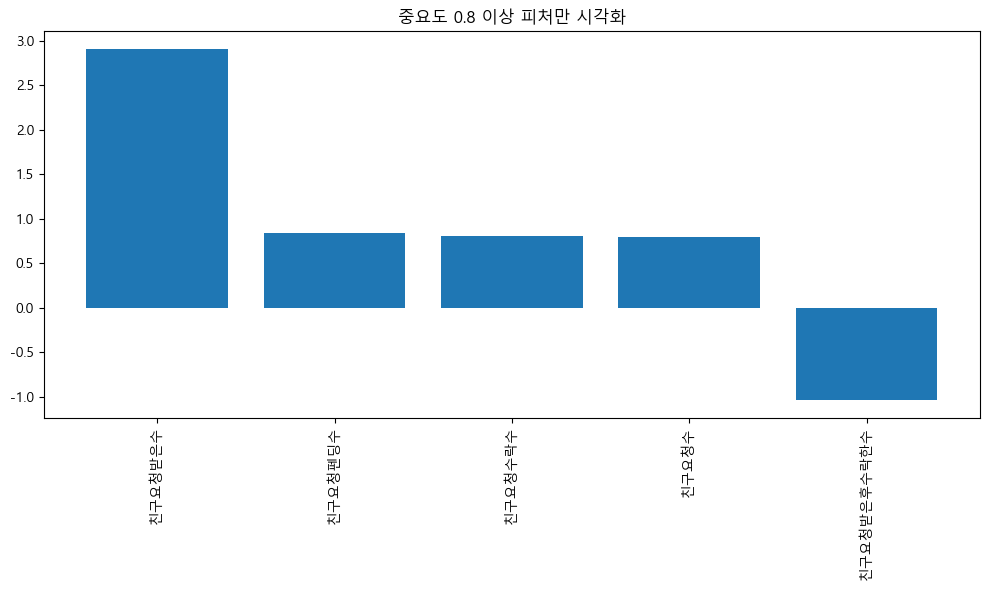

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.8 이상 피처만 선택
low_importance_mask = feature_importance >= 0.8
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.8 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.8 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.8 필터링
low_idx = np.where(np.abs(importances) >= 0.8)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.8 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

### 중요도 0.9 이상


📉 중요도 0.9 이상 피처 목록:
['친구요청받은수', '친구요청받은후수락한수']

✅ [중요도 0.9 이상 피처만 사용한 검증 평가]
Confusion Matrix:
[[3125  107]
 [ 337  628]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      3232
           1       0.85      0.65      0.74       965

    accuracy                           0.89      4197
   macro avg       0.88      0.81      0.84      4197
weighted avg       0.89      0.89      0.89      4197



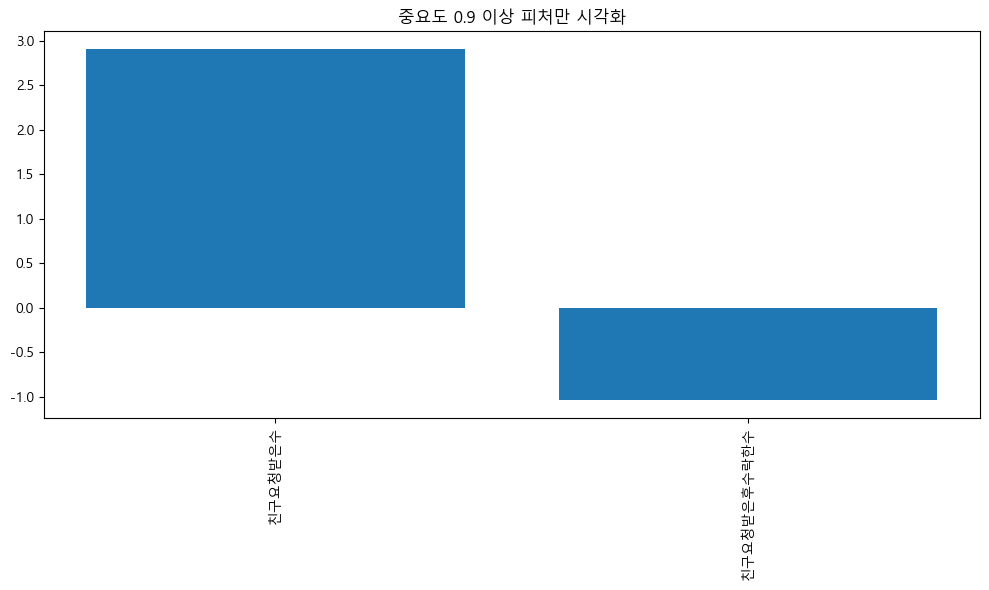

In [ ]:
# 피처 중요도 계산 (로지스틱 회귀 계수의 절댓값)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.9 이상 피처만 선택
low_importance_mask = feature_importance >= 0.9
low_importance_features = feature_names[low_importance_mask]

print("\n📉 중요도 0.9 이상 피처 목록:")
print(list(low_importance_features))

# 해당 피처들만 사용해 새로운 데이터 구성
X_low_imp = X[low_importance_features]

# 다시 스케일링
X_low_imp_scaled = scaler.fit_transform(X_low_imp)

# 데이터 분리
X_train_low, X_val_low, y_train_low, y_val_low = train_test_split(
    X_low_imp_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 모델 재학습 및 평가
log_model_low = LogisticRegression(max_iter=1000)
log_model_low.fit(X_train_low, y_train_low)
y_pred_low = log_model_low.predict(X_val_low)

print("\n✅ [중요도 0.9 이상 피처만 사용한 검증 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val_low, y_pred_low))

print("\nClassification Report:")
print(classification_report(y_val_low, y_pred_low))

# 중요도 계산
importances = log_model.coef_[0]
feature_names = X.columns

# 중요도 >= 0.9 필터링
low_idx = np.where(np.abs(importances) >= 0.9)[0]
low_importances = importances[low_idx]
low_feature_names = feature_names[low_idx]

# 중요도 기준 정렬
sorted_idx = np.argsort(low_importances)[::-1]
sorted_importances = low_importances[sorted_idx]
sorted_features = low_feature_names[sorted_idx]

# 시각화
plt.figure(figsize=(10, 6))
plt.title("중요도 0.9 이상 피처만 시각화")
plt.bar(range(len(sorted_importances)), sorted_importances, align='center')
plt.xticks(range(len(sorted_importances)), sorted_features, rotation=90)
plt.tight_layout()
plt.show()

## 0.7 이상 모델에 대한 추가 시각화

In [ ]:
# 피처 중요도 계산 (log_model 기준)
feature_importance = np.abs(log_model.coef_[0])
feature_names = X.columns

# 중요도 0.7 이상 피처 선택
high_imp_mask = feature_importance >= 0.7
high_imp_features = feature_names[high_imp_mask]

print("\n📉 중요도 0.7 이상 피처 목록:")
print(list(high_imp_features))

# 중요도 0.7 이상 피처만 사용한 데이터 준비
X_high_imp = X[high_imp_features]

# 스케일러 준비
scaler = StandardScaler()

# Stratified K-Fold 교차검증 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []

fold = 1
for train_idx, val_idx in skf.split(X_high_imp, y):
    X_train_fold, X_val_fold = X_high_imp.iloc[train_idx], X_high_imp.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]
    
    # 스케일링 (train 기준 fit, val 기준 transform)
    X_train_scaled = scaler.fit_transform(X_train_fold)
    X_val_scaled = scaler.transform(X_val_fold)
    
    # 모델 학습
    log_model_fold = LogisticRegression(max_iter=1000, random_state=42)
    log_model_fold.fit(X_train_scaled, y_train_fold)
    
    # 예측
    y_pred_fold = log_model_fold.predict(X_val_scaled)
    
    # 평가 결과 출력
    print(f"\n✅ [Fold {fold} 검증 평가]")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val_fold, y_pred_fold))
    
    print("\nClassification Report:")
    report = classification_report(y_val_fold, y_pred_fold, output_dict=True)
    print(classification_report(y_val_fold, y_pred_fold))
    
    accuracy_list.append(report['accuracy'])
    precision_list.append(report['weighted avg']['precision'])
    recall_list.append(report['weighted avg']['recall'])
    f1_list.append(report['weighted avg']['f1-score'])
    
    fold += 1

print("\n--- 교차검증 평균 성능 ---")
print(f"Accuracy: {np.mean(accuracy_list):.4f} ± {np.std(accuracy_list):.4f}")
print(f"Precision: {np.mean(precision_list):.4f} ± {np.std(precision_list):.4f}")
print(f"Recall: {np.mean(recall_list):.4f} ± {np.std(recall_list):.4f}")
print(f"F1-score: {np.mean(f1_list):.4f} ± {np.std(f1_list):.4f}")


📉 중요도 0.7 이상 피처 목록:
['친구요청수', '친구요청받은수', '친구요청수락수', '친구요청펜딩수', '친구요청받은후수락한수']

✅ [Fold 1 검증 평가]
Confusion Matrix:
[[3110  123]
 [ 203  761]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      3233
           1       0.86      0.79      0.82       964

    accuracy                           0.92      4197
   macro avg       0.90      0.88      0.89      4197
weighted avg       0.92      0.92      0.92      4197


✅ [Fold 2 검증 평가]
Confusion Matrix:
[[3133   99]
 [ 204  761]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.88      0.79      0.83       965

    accuracy                           0.93      4197
   macro avg       0.91      0.88      0.89      4197
weighted avg       0.93      0.93      0.93      4197


✅ [Fold 3 검증 평가]
Confusion Matrix:
[[3113  119]
 [ 226  739]]

Classification Report:
      

# xgboost 모델 정의 및 학습

정확도: 0.9270907791279486
Confusion Matrix:
[[3054  178]
 [ 128  837]]

분류 리포트:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3232
           1       0.82      0.87      0.85       965

    accuracy                           0.93      4197
   macro avg       0.89      0.91      0.90      4197
weighted avg       0.93      0.93      0.93      4197



c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


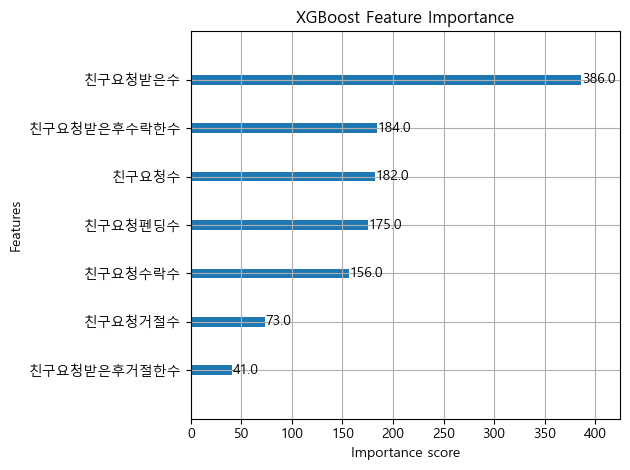

In [ ]:
# 1. 데이터 복사 (원본 df 사용)
data = df.copy()

# 타겟 / 피처 분리
X = data.drop(columns=['질문참여여부'])
y = data['질문참여여부']

# 2. 학습/검증 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. XGBoost 분류기 훈련
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# 4. 예측 및 평가
y_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("정확도:", acc)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n분류 리포트:")
print(classification_report(y_test, y_pred))

# 5. 중요 피처 시각화
xgb.plot_importance(xgb_model)
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Stratified K-Fold 설정
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_model = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# ----------------------------
# 교차 검증 수행
# ----------------------------
scores = cross_val_score(xgb_model, X_scaled, y, cv=kf, scoring='accuracy')
print("✅ 교차 검증 정확도:", scores)
print("평균 정확도:", np.mean(scores))

# ----------------------------
# Fold별 예측 결과 상세 보기
# ----------------------------
fold = 1
all_preds = []
all_true = []

for train_idx, val_idx in kf.split(X_scaled, y):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_val)

    print(f"\n📌 Fold {fold} 결과")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    all_preds.extend(y_pred)
    all_true.extend(y_val)
    fold += 1

# ----------------------------
# 전체 데이터 기준 최종 평가
# ----------------------------
print("\n✅ 전체 Fold 합산 결과")
print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds))

c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr

✅ 교차 검증 정확도: [0.92423159 0.9304265  0.92256374 0.92089588 0.92230696]
평균 정확도: 0.9240849324259713

📌 Fold 1 결과
Confusion Matrix:
[[3063  170]
 [ 148  816]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3233
           1       0.83      0.85      0.84       964

    accuracy                           0.92      4197
   macro avg       0.89      0.90      0.89      4197
weighted avg       0.92      0.92      0.92      4197


📌 Fold 2 결과
Confusion Matrix:
[[3061  171]
 [ 121  844]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      3232
           1       0.83      0.87      0.85       965

    accuracy                           0.93      4197
   macro avg       0.90      0.91      0.90      4197
weighted avg       0.93      0.93      0.93      4197



c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



📌 Fold 3 결과
Confusion Matrix:
[[3052  180]
 [ 145  820]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      3232
           1       0.82      0.85      0.83       965

    accuracy                           0.92      4197
   macro avg       0.89      0.90      0.89      4197
weighted avg       0.92      0.92      0.92      4197


📌 Fold 4 결과
Confusion Matrix:
[[3053  179]
 [ 153  812]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      3232
           1       0.82      0.84      0.83       965

    accuracy                           0.92      4197
   macro avg       0.89      0.89      0.89      4197
weighted avg       0.92      0.92      0.92      4197


📌 Fold 5 결과
Confusion Matrix:
[[3037  195]
 [ 131  833]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95  

c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.96      0.94      0.95     16161
           1       0.82      0.86      0.84      4823

    accuracy                           0.92     20984
   macro avg       0.89      0.90      0.89     20984
weighted avg       0.93      0.92      0.92     20984



# 랜덤포래스트 모델 정의 및 학습

In [ ]:
df = model_log.copy()

✅ [검증 데이터 평가]
Confusion Matrix:
[[3043  189]
 [ 140  825]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3232
           1       0.81      0.85      0.83       965

    accuracy                           0.92      4197
   macro avg       0.88      0.90      0.89      4197
weighted avg       0.92      0.92      0.92      4197



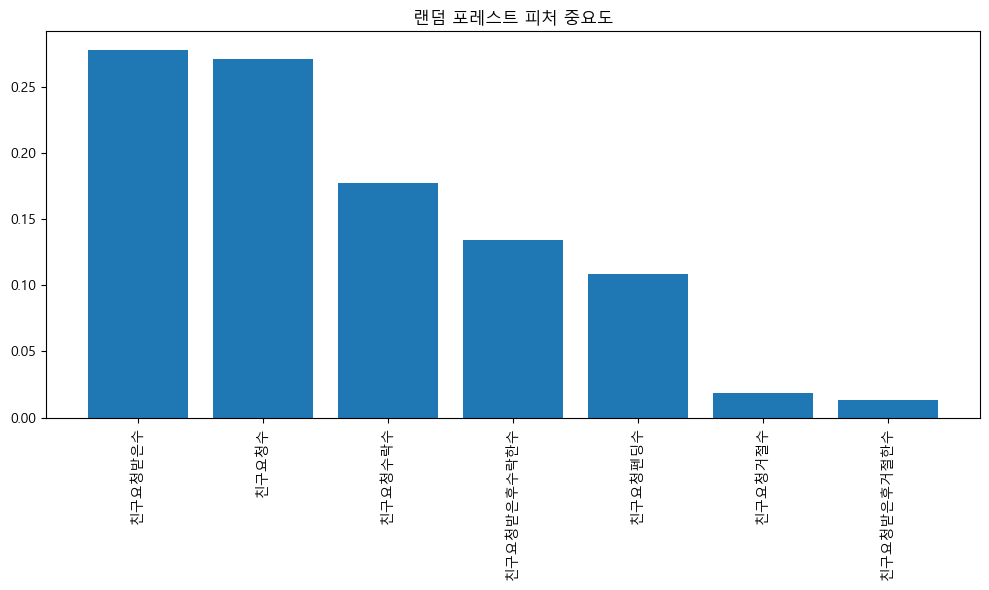

In [ ]:
# 범주형 변수 라벨 인코딩
label_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# 타겟 / 피처 분리
X = df.drop(columns=['질문참여여부'])
y = df['질문참여여부']

# 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 분리
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 랜덤 포레스트 모델 학습
# ----------------------------

rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    random_state=42
)
rf_model.fit(X_train, y_train)

# ----------------------------
# 예측 및 평가
# ----------------------------

y_pred = rf_model.predict(X_val)

print("✅ [검증 데이터 평가]")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# ----------------------------
# 중요도 시각화 (한글 깨짐 방지 포함)
# ----------------------------

importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.rcParams['font.family'] = 'Malgun Gothic'  # 또는 AppleGothic / NanumGothic
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))
plt.title("랜덤 포레스트 피처 중요도")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------
# 교차 검증 설정
# ----------------------------
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42
)

# ----------------------------
# 단순 평균 정확도 확인
# ----------------------------
scores = cross_val_score(rf_model, X_scaled, y, cv=kf, scoring='accuracy')
print("✅ 교차 검증 정확도:", scores)
print("평균 정확도:", np.mean(scores))

# ----------------------------
# Fold별 상세 평가
# ----------------------------
fold = 1
all_preds = []
all_true = []

for train_idx, val_idx in kf.split(X_scaled, y):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_val)

    print(f"\n📌 Fold {fold} 결과")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))
    
    all_preds.extend(y_pred)
    all_true.extend(y_val)
    fold += 1

# ----------------------------
# 전체 Fold 합산 최종 평가
# ----------------------------
print("\n✅ 전체 Fold 합산 결과")
print("Confusion Matrix:")
print(confusion_matrix(all_true, all_preds))
print("\nClassification Report:")
print(classification_report(all_true, all_preds))

✅ 교차 검증 정확도: [0.92089588 0.92875864 0.91851322 0.91565404 0.91491897]
평균 정확도: 0.9197481495816273

📌 Fold 1 결과
Confusion Matrix:
[[3052  181]
 [ 151  813]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      3233
           1       0.82      0.84      0.83       964

    accuracy                           0.92      4197
   macro avg       0.89      0.89      0.89      4197
weighted avg       0.92      0.92      0.92      4197


📌 Fold 2 결과
Confusion Matrix:
[[3054  178]
 [ 121  844]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3232
           1       0.83      0.87      0.85       965

    accuracy                           0.93      4197
   macro avg       0.89      0.91      0.90      4197
weighted avg       0.93      0.93      0.93      4197


📌 Fold 3 결과
Confusion Matrix:
[[3039  193]
 [ 149  816]]

Classification Report:
   

# 3개 모델에 대한 비교(roc curve)

c:\Users\jewji\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [14:10:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


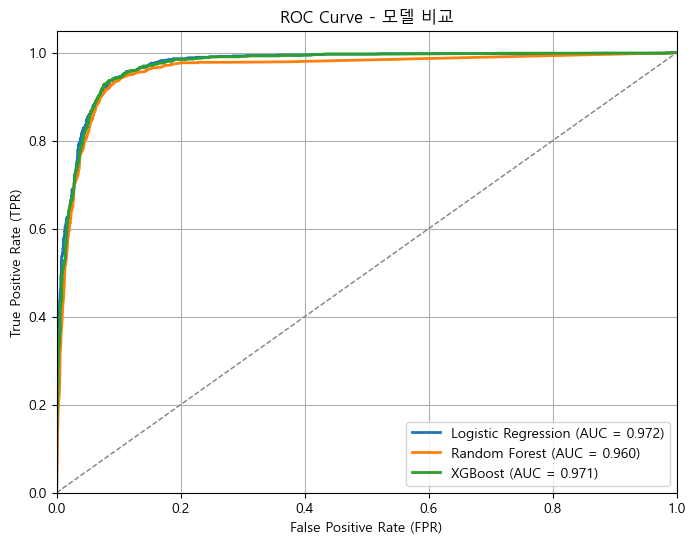


✅ [Logistic Regression 검증 데이터 평가]
Confusion Matrix:
[[3120  112]
 [ 213  752]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      3232
           1       0.87      0.78      0.82       965

    accuracy                           0.92      4197
   macro avg       0.90      0.87      0.89      4197
weighted avg       0.92      0.92      0.92      4197


✅ [Random Forest 검증 데이터 평가]
Confusion Matrix:
[[3043  189]
 [ 140  825]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      3232
           1       0.81      0.85      0.83       965

    accuracy                           0.92      4197
   macro avg       0.88      0.90      0.89      4197
weighted avg       0.92      0.92      0.92      4197


✅ [XGBoost 검증 데이터 평가]
Confusion Matrix:
[[3058  174]
 [ 139  826]]

Classification Report:
              precision    recall  f1-score   suppor

In [ ]:
# ----------------------------
# 범주형 변수 라벨 인코딩
# ----------------------------
label_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# ----------------------------
# 타겟 / 피처 분리
# ----------------------------
X = df.drop(columns=['질문참여여부'])
y = df['질문참여여부']

# ----------------------------
# 스케일링
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------
# 학습/검증 분리
# ----------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 모델 정의 및 학습
# ----------------------------
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

log_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# ----------------------------
# ROC Curve 데이터 계산
# ----------------------------
models = {
    "Logistic Regression": log_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# 랜덤 분류기 기준선
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# 그래프 설정
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve - 모델 비교')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ----------------------------
# 성능 평가 출력
# ----------------------------
for name, model in models.items():
    y_pred = model.predict(X_val)
    print(f"\n✅ [{name} 검증 데이터 평가]")
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred))